# Exploratory Data Analysis — Inside Airbnb London

**City:** London | **Snapshot:** 2025-09-14 | **Currency:** GBP  
**Data source:** `data/processed/london/` (cleaned + enriched Parquet files)

## Business questions this notebook answers

1. How are prices distributed, and which boroughs / room types command a premium?
2. Where are listings concentrated geographically?
3. How do hosts segment (casual vs professional) and how does it affect price and quality?
4. What does review activity signal about demand?
5. Is there seasonal or weekday/weekend variation in availability?
6. Are there unusual listings (very long stays, very high price, inactive)?
7. What is the relationship between review score, response rate, and occupancy proxy?

> **A-005 constraint:** `calendar.price` and `calendar.adjusted_price` are 100 % NULL in this snapshot.  
> All temporal analyses use **availability** and **occupancy proxy** instead of price.

---
## Step 1 — Load and verify the data

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ── Paths ────────────────────────────────────────────────────────────────────
PROCESSED = Path("../data/processed/london")
RAW       = Path("../data/raw/london")
FIGS      = Path("../reports/figures/eda")
TABLES    = Path("../reports/tables")

# Output directories (created here so later cells never fail on missing dir)
FIGS.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
# Consistent, clean look for all charts
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

SNAPSHOT_DATE = pd.Timestamp("2025-09-14")
CITY_LABEL    = "London"

In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────────
# listing_master = one row per listing, all derived metrics already joined
listings = pd.read_parquet(PROCESSED / "listing_master.parquet")

# calendar = one row per (listing, date) — 35M rows; load only needed columns
# to avoid exhausting RAM. calendar_clean.parquet has no price column (A-005).
calendar = pd.read_parquet(
    PROCESSED / "calendar_clean.parquet",
    columns=["listing_id", "date", "available", "minimum_nights", "maximum_nights"],
)
# Derive numeric flag: 1 = available, 0 = blocked/booked
calendar["available_int"] = calendar["available"].astype(int)

# reviews = one row per review, 2.1M rows
reviews = pd.read_parquet(PROCESSED / "reviews_clean.parquet")

# neighbourhood_summary = 33 boroughs, pre-aggregated metrics
neigh_sum = pd.read_parquet(PROCESSED / "neighbourhood_summary.parquet")

print(f"listings  : {listings.shape[0]:>9,} rows × {listings.shape[1]} cols")
print(f"calendar  : {calendar.shape[0]:>9,} rows × {calendar.shape[1]} cols")
print(f"reviews   : {reviews.shape[0]:>9,} rows × {reviews.shape[1]} cols")
print(f"neigh_sum : {neigh_sum.shape[0]:>9,} rows × {neigh_sum.shape[1]} cols")

listings  :    96,871 rows × 100 cols
calendar  : 35,357,974 rows × 6 cols
reviews   : 2,097,996 rows × 8 cols
neigh_sum :        33 rows × 12 cols


In [3]:
# ── Uniqueness and null guards ────────────────────────────────────────────────
# These must hold before any analysis. If they raise, stop and investigate.
assert listings["id"].is_unique,       "listing id not unique — data issue"
assert not listings["id"].isna().any(), "listing id has nulls — data issue"

print("Uniqueness checks passed")

Uniqueness checks passed


In [4]:
# ── Key column overview ───────────────────────────────────────────────────────
# Quick look at the numeric columns that drive the rest of the EDA
key_cols = [
    "price_numeric",        # nightly price in GBP (NULL for 36% of listings)
    "accommodates",         # guest capacity
    "bedrooms",             # bedroom count
    "bathroom_count",       # parsed from bathrooms_text
    "minimum_nights",       # host-set minimum stay
    "availability_365",     # days open per year (from listings snapshot)
    "number_of_reviews",    # total reviews ever
    "reviews_per_month_calc",  # computed rate over active months
    "review_scores_rating", # overall rating (0–5 scale in this data)
    "host_tenure_years",    # years since host joined
    "host_portfolio_size",  # number of listings this host has
    "occupancy_proxy",      # 1 − availability_rate (calendar-based)
    "revenue_proxy_gbp",    # price_numeric × unavailable_days (upper bound)
]

listings[key_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T.round(2)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price_numeric,61963.0,229.92,4437.59,7.00,30.00,40.00,77.00,135.00,221.00,500.00,1100.00,1085147.00
accommodates,96871.0,3.33,2.08,1.00,1.00,1.00,2.00,2.00,4.00,7.00,10.00,16.00
bedrooms,84096.0,1.61,1.04,0.00,0.00,1.00,1.00,1.00,2.00,4.00,5.00,50.00
bathroom_count,96718.0,1.33,0.68,0.00,0.50,1.00,1.00,1.00,1.50,2.50,3.50,30.00
minimum_nights,96871.0,5.44,23.69,1.00,1.00,1.00,1.00,2.00,4.00,14.00,90.00,1125.00
availability_365,96871.0,144.93,141.81,0.00,0.00,0.00,0.00,96.00,288.00,364.00,365.00,365.00
number_of_reviews,96871.0,21.66,50.37,0.00,0.00,0.00,1.00,5.00,20.00,98.00,246.00,1902.00
reviews_per_month_calc,72749.0,0.64,1.11,0.00,0.00,0.00,0.00,0.17,0.75,2.92,5.33,32.50
review_scores_rating,72749.0,4.68,0.49,0.00,2.50,4.00,4.58,4.83,5.00,5.00,5.00,5.00
host_tenure_years,96830.0,7.64,3.89,0.01,0.27,0.91,4.06,8.57,10.58,13.20,14.30,17.05


In [5]:
# ── Missingness summary for key columns ──────────────────────────────────────
miss = (
    listings[key_cols]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
miss["missing_pct"] = (miss["missing_count"] / len(listings) * 100).round(1)

print(miss.to_string())

                        missing_count  missing_pct
price_numeric                   34908         36.0
accommodates                        0          0.0
bedrooms                        12775         13.2
bathroom_count                    153          0.2
minimum_nights                      0          0.0
availability_365                    0          0.0
number_of_reviews                   0          0.0
reviews_per_month_calc          24122         24.9
review_scores_rating            24122         24.9
host_tenure_years                  41          0.0
host_portfolio_size                 0          0.0
occupancy_proxy                     0          0.0
revenue_proxy_gbp               34908         36.0


In [6]:
# ── Categorical field overview ────────────────────────────────────────────────
cat_cols = ["room_type", "property_type_bucket", "neighbourhood_cleansed"]
for col in cat_cols:
    print(f"\n{col} ({listings[col].nunique()} unique):")
    print(listings[col].value_counts().head(10).to_string())


room_type (4 unique):
room_type
entire_home     62907
private_room    33643
shared_room       212
hotel_room        109

property_type_bucket (5 unique):
property_type_bucket
apartment    69713
house        24244
hotel         2107
other          615
unique         192

neighbourhood_cleansed (33 unique):
neighbourhood_cleansed
Westminster               11385
Tower Hamlets              7469
Camden                     6551
Kensington and Chelsea     6401
Hackney                    6359
Southwark                  5475
Lambeth                    5190
Islington                  5036
Wandsworth                 4965
Hammersmith and Fulham     4157


In [7]:
# ── Calendar data sanity ──────────────────────────────────────────────────────
# Confirm A-005: calendar price is absent from this parquet (only 4 cols loaded)
# available_int = 1 means available, 0 means blocked/booked
print("Calendar date range:",
      calendar["date"].min(), "→", calendar["date"].max())
print("available_int values:",
      calendar["available_int"].value_counts().to_dict())
print("Unique listing IDs in calendar:",
      calendar["listing_id"].nunique())

Calendar date range: 2025-09-14 00:00:00 → 2026-09-17 00:00:00


available_int values:

 {0: 21313866, 1: 14044108}


Unique listing IDs in calendar: 96871


In [8]:
# ── Reviews data sanity ───────────────────────────────────────────────────────
print("Reviews date range:",
      reviews["date"].min(), "→", reviews["date"].max())
print("Unique listings with reviews:",
      reviews["listing_id"].nunique())
print("Reviews columns:", list(reviews.columns))

Reviews date range: 2009-12-21 00:00:00 → 2025-09-17 00:00:00
Unique listings with reviews: 72749
Reviews columns: ['listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments', 'comment_length', 'comment_is_duplicate']


In [9]:
# ── Save full numerical summary to CSV ───────────────────────────────────────
# This CSV backs the 'Summary Statistics' section of eda_findings.md
summary = listings[key_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T.round(4)
summary["missing_count"] = listings[key_cols].isna().sum()
summary["missing_pct"]   = (listings[key_cols].isna().mean() * 100).round(1)
summary.to_csv(TABLES / "numerical_summary.csv")

print("Saved → reports/tables/numerical_summary.csv")

Saved → reports/tables/numerical_summary.csv


In [10]:
# ── Analysis population: price-eligible listings ──────────────────────────────
# Keep only listings with a valid, non-negative price.
# This subset is used for all price-related charts.
# Non-price analyses (availability, reviews) use the full `listings` DataFrame.
eda = listings[
    listings["price_numeric"].notna()
    & listings["price_numeric"].ge(0)
].copy()

# Document the exclusions clearly
excl = pd.DataFrame([
    {"rule": "total_listings",         "count": len(listings)},
    {"rule": "missing_price",          "count": int(listings["price_numeric"].isna().sum())},
    {"rule": "negative_price",         "count": int((listings["price_numeric"] < 0).sum())},
    {"rule": "price_eligible_population", "count": len(eda)},
])
excl.to_csv(TABLES / "population_exclusions.csv", index=False)

print(excl.to_string(index=False))
print(f"\nPrice-eligible coverage: {len(eda)/len(listings)*100:.1f}% of all listings")

                     rule  count
           total_listings  96871
            missing_price  34908
           negative_price      0
price_eligible_population  61963

Price-eligible coverage: 64.0% of all listings


---
## Step 2 — Summary statistics and distributions

Covers: price distribution, price by room type / property type / neighbourhood,
host portfolio, review scores, and availability bands.

All price charts use the `eda` subset (61,963 listings with valid price).
Non-price charts (reviews, availability) use the full `listings` DataFrame.

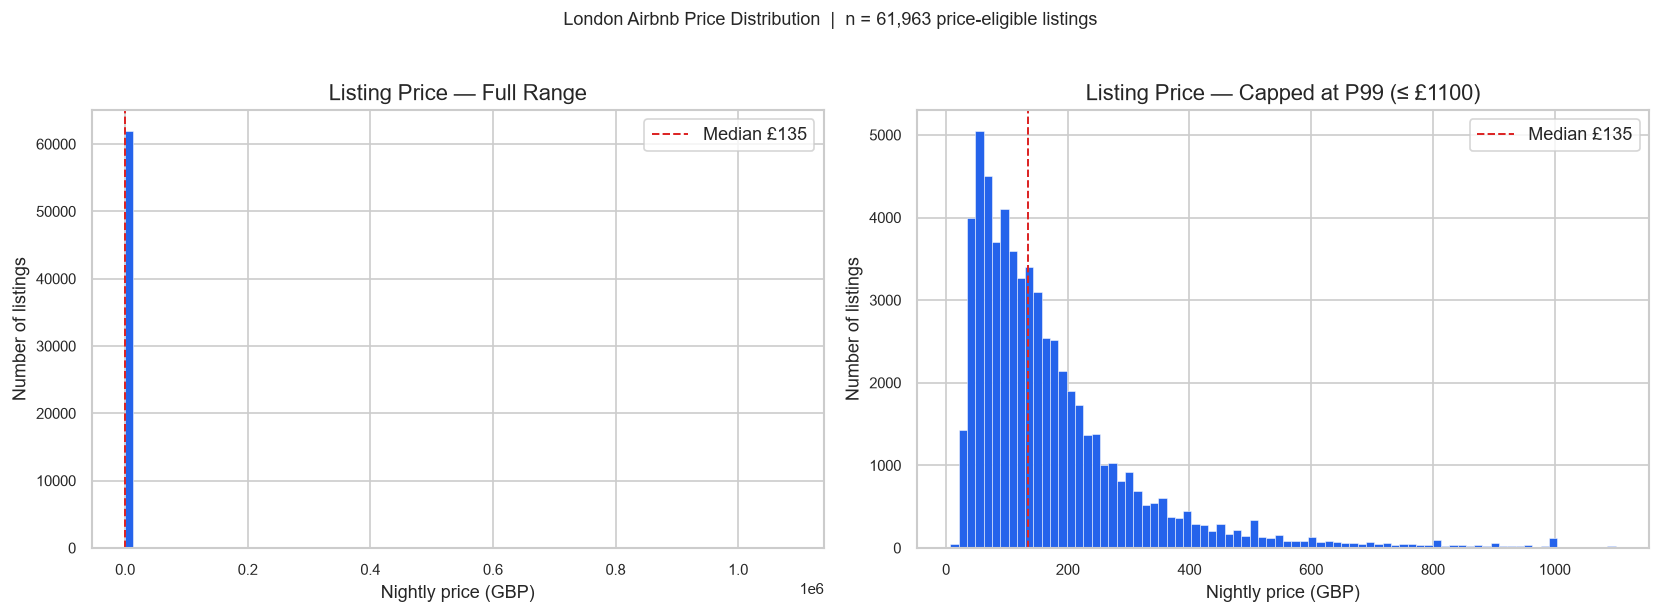

Median price   : £135
Mean price     : £230  (skewed up by luxury tail)
P99 cutoff     : £1100
Listings > P99 : 613  (excluded only from visual, kept in data)


In [11]:
# ── Charts 1 & 2 — Price distribution (full and P99-capped) ──────────────────
# Two side-by-side views: full range reveals the luxury tail;
# capped view shows where 99% of listings actually sit.

p99 = eda["price_numeric"].quantile(0.99)
p50 = eda["price_numeric"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(eda["price_numeric"], bins=80, color="#2563eb", edgecolor="white", linewidth=0.3)
axes[0].axvline(p50, color="#dc2626", linestyle="--", linewidth=1.2, label=f"Median £{p50:.0f}")
axes[0].set_title("Listing Price — Full Range")
axes[0].set_xlabel("Nightly price (GBP)")
axes[0].set_ylabel("Number of listings")
axes[0].legend()

# Cap at P99 so the bulk of the distribution is readable
axes[1].hist(eda.loc[eda["price_numeric"] <= p99, "price_numeric"],
             bins=80, color="#2563eb", edgecolor="white", linewidth=0.3)
axes[1].axvline(p50, color="#dc2626", linestyle="--", linewidth=1.2, label=f"Median £{p50:.0f}")
axes[1].set_title(f"Listing Price — Capped at P99 (≤ £{p99:.0f})")
axes[1].set_xlabel("Nightly price (GBP)")
axes[1].set_ylabel("Number of listings")
axes[1].legend()

plt.suptitle(f"London Airbnb Price Distribution  |  n = {len(eda):,} price-eligible listings",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "01_price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Business interpretation
print(f"Median price   : £{p50:.0f}")
print(f"Mean price     : £{eda['price_numeric'].mean():.0f}  (skewed up by luxury tail)")
print(f"P99 cutoff     : £{p99:.0f}")
print(f"Listings > P99 : {(eda['price_numeric'] > p99).sum():,}  (excluded only from visual, kept in data)")

C:\Users\Bavikaran\AppData\Local\Temp\ipykernel_18360\4175460262.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


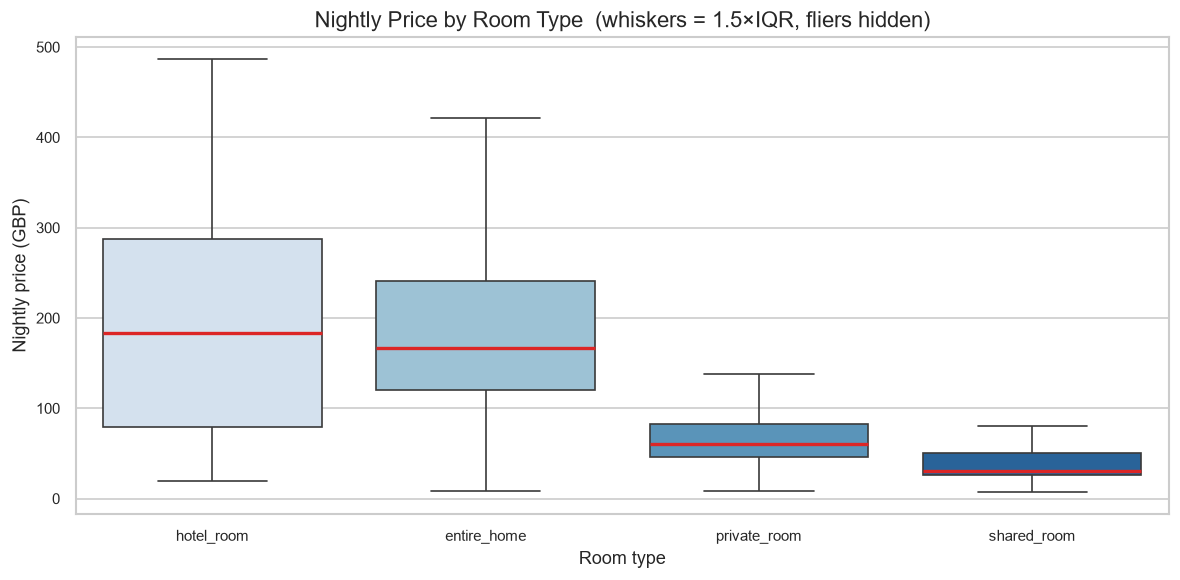

              listing_count  median_price  mean_price    p25    p75     p95
room_type                                                                  
hotel_room               72         281.0       658.0  112.0  925.0  1490.0
entire_home           42318         175.0       279.0  122.0  266.0   574.0
private_room          19382          61.0       122.0   46.0   85.0   192.0
shared_room             191          32.0        97.0   26.0   56.0   318.0


In [12]:
# ── Chart 3 — Price by room type ─────────────────────────────────────────────
# Box plots without outliers so the inter-quartile range is readable.
# showfliers=False keeps the chart clean; we report P95 in the table instead.

price_by_room = (
    eda.groupby("room_type")["price_numeric"]
    .agg(
        listing_count="count",
        median_price="median",
        mean_price="mean",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75),
        p95=lambda x: x.quantile(0.95),
    )
    .sort_values("median_price", ascending=False)
    .round(0)
)
price_by_room.to_csv(TABLES / "price_by_room_type.csv")

# Ordered by median price (highest first)
room_order = price_by_room.index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))

# seaborn boxplot supports order= natively; cap y-axis at P95 for readability
sns.boxplot(
    data=eda[eda["price_numeric"] <= eda["price_numeric"].quantile(0.95)],
    x="room_type",
    y="price_numeric",
    order=room_order,
    ax=ax,
    showfliers=False,
    palette="Blues",
    medianprops={"color": "#dc2626", "linewidth": 2},
)
ax.set_title("Nightly Price by Room Type  (whiskers = 1.5×IQR, fliers hidden)")
ax.set_xlabel("Room type")
ax.set_ylabel("Nightly price (GBP)")
plt.tight_layout()
plt.savefig(FIGS / "02_price_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()

print(price_by_room.to_string())

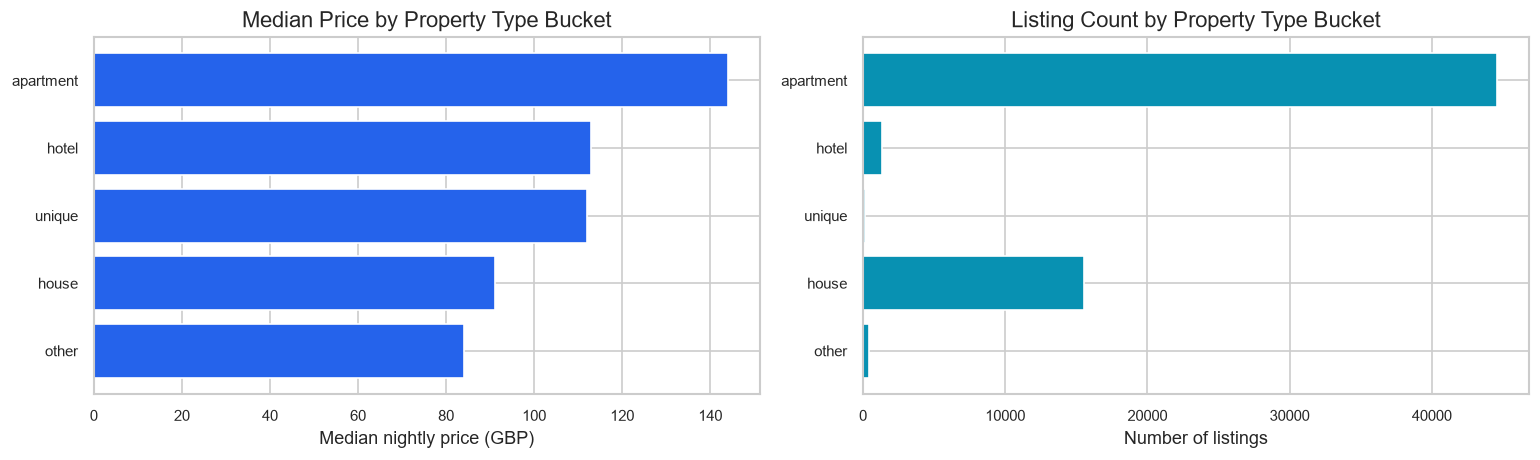

                      listing_count  median_price  mean_price
property_type_bucket                                         
other                           415          84.0       120.0
house                         15525          91.0       190.0
unique                          129         112.0       164.0
hotel                          1305         113.0       185.0
apartment                     44589         144.0       246.0


In [13]:
# ── Chart 4 — Price by property type bucket ──────────────────────────────────
# Use the 5-bucket coarsening (apartment/house/hotel/unique/other) rather than
# the raw 91-value property_type, which is too granular to visualise cleanly.

price_by_prop = (
    eda.groupby("property_type_bucket")["price_numeric"]
    .agg(listing_count="count", median_price="median", mean_price="mean")
    .sort_values("median_price", ascending=True)   # ascending for horizontal bar
    .round(0)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Median price bar (horizontal — easier to read labels)
axes[0].barh(price_by_prop.index, price_by_prop["median_price"], color="#2563eb")
axes[0].set_title("Median Price by Property Type Bucket")
axes[0].set_xlabel("Median nightly price (GBP)")

# Listing count bar to show relative sample sizes
axes[1].barh(price_by_prop.index, price_by_prop["listing_count"], color="#0891b2")
axes[1].set_title("Listing Count by Property Type Bucket")
axes[1].set_xlabel("Number of listings")

plt.tight_layout()
plt.savefig(FIGS / "03_price_by_property_type.png", dpi=150, bbox_inches="tight")
plt.show()

print(price_by_prop.to_string())

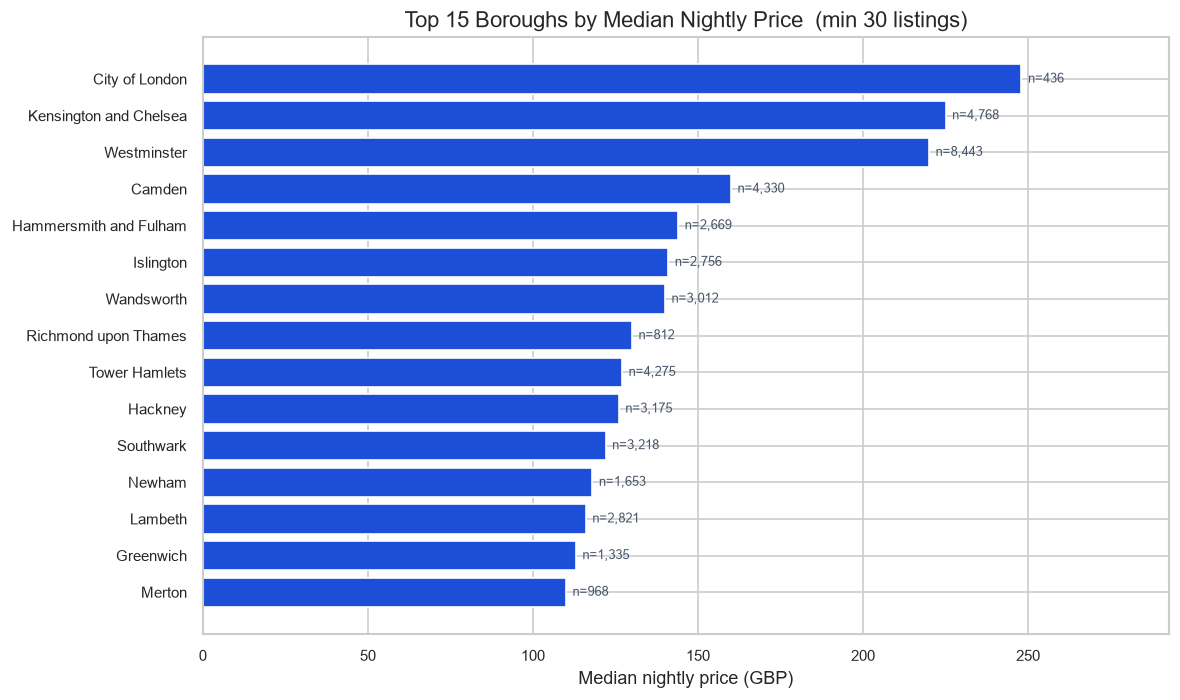

                        listing_count  median_price  mean_price
neighbourhood_cleansed                                         
City of London                    436         248.0       354.0
Kensington and Chelsea           4768         225.0       336.0
Westminster                      8443         220.0       342.0
Camden                           4330         160.0       217.0
Hammersmith and Fulham           2669         144.0       199.0
Islington                        2756         141.0       218.0
Wandsworth                       3012         140.0       198.0
Richmond upon Thames              812         130.0       184.0
Tower Hamlets                    4275         127.0       431.0
Hackney                          3175         126.0       161.0
Southwark                        3218         122.0       174.0
Newham                           1653         118.0       155.0
Lambeth                          2821         116.0       346.0
Greenwich                        1335   

In [14]:
# ── Chart 5 — Median price by neighbourhood (top 15) ─────────────────────────
# Minimum 30 listings per borough before ranking, so small-sample boroughs
# don't distort the comparison.

neigh_price = (
    eda.groupby("neighbourhood_cleansed")["price_numeric"]
    .agg(listing_count="count", median_price="median", mean_price="mean")
    .query("listing_count >= 30")
    .sort_values("median_price", ascending=True)   # ascending for horizontal bar
    .tail(15)                                       # top 15 by median
    .round(0)
)
neigh_price.to_csv(TABLES / "price_by_neighbourhood.csv")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(neigh_price.index, neigh_price["median_price"], color="#1d4ed8")

# Label each bar with the listing count so the reader can judge reliability
for bar, (_, row) in zip(bars, neigh_price.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"n={int(row['listing_count']):,}", va="center", fontsize=8, color="#475569")

ax.set_title("Top 15 Boroughs by Median Nightly Price  (min 30 listings)")
ax.set_xlabel("Median nightly price (GBP)")
ax.set_xlim(0, neigh_price["median_price"].max() * 1.18)
plt.tight_layout()
plt.savefig(FIGS / "04_median_price_by_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

print(neigh_price.sort_values("median_price", ascending=False).to_string())

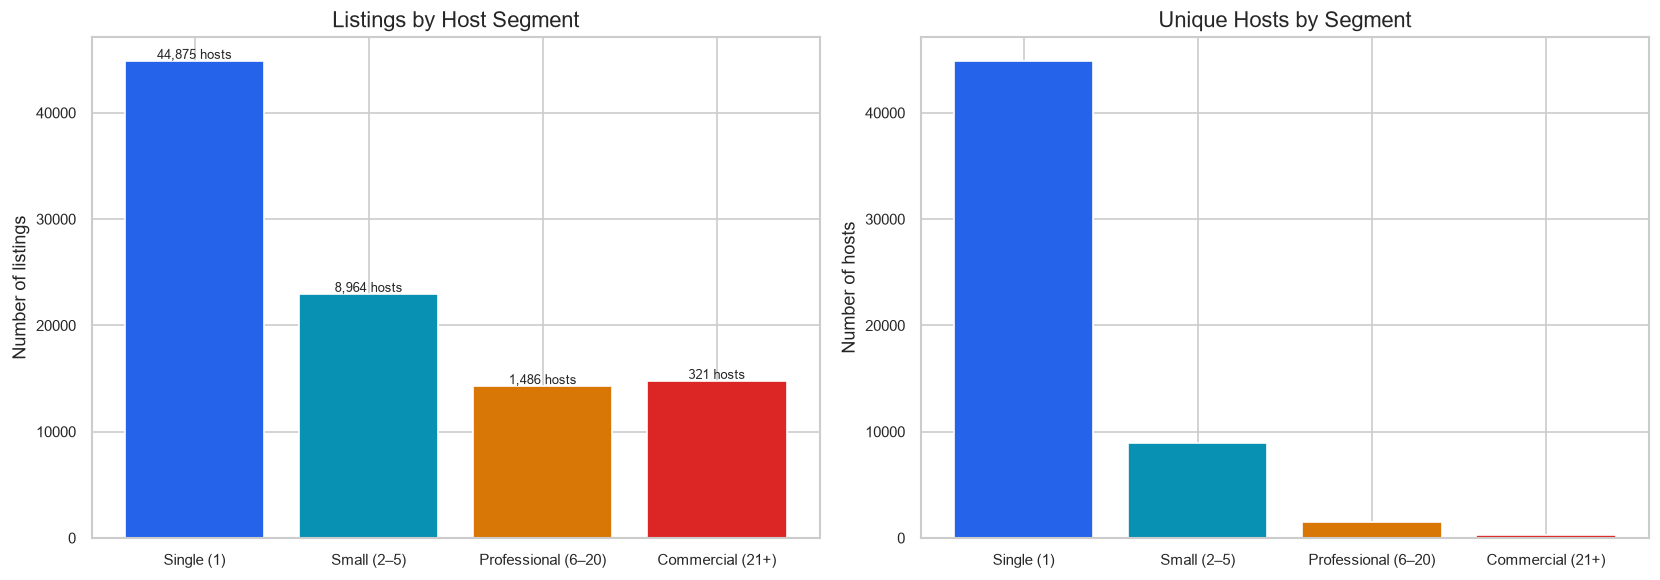

                     listing_count  unique_hosts  median_price  median_rating superhost_rate
host_segment                                                                                
Single (1)                   44875         44875         120.0           4.91       0.112141
Small (2–5)                  22950          8964         110.0           4.84       0.284429
Professional (6–20)          14280          1486         155.0           4.71       0.259453
Commercial (21+)             14766           321         184.0           4.64       0.156237


In [15]:
# ── Charts 6 & 7 — Host portfolio distribution and market concentration ───────
# Segments hosts by how many listings they operate.
# Market concentration shows what share of the total supply a minority holds.

def _host_segment(n: int) -> str:
    # Four buckets from the EDA plan section 9
    if n == 1:    return "Single (1)"
    if n <= 5:    return "Small (2–5)"
    if n <= 20:   return "Professional (6–20)"
    return "Commercial (21+)"

# Apply segment to the full listings df (not just price-eligible)
listings["host_segment"] = listings["host_portfolio_size"].apply(_host_segment)

seg_order = ["Single (1)", "Small (2–5)", "Professional (6–20)", "Commercial (21+)"]
seg_colors = ["#2563eb", "#0891b2", "#d97706", "#dc2626"]

host_seg = (
    listings.groupby("host_segment")
    .agg(
        listing_count=("id", "count"),
        unique_hosts=("host_id", "nunique"),
        median_price=("price_numeric", "median"),
        median_rating=("review_scores_rating", "median"),
        median_occupancy=("occupancy_proxy", "median"),
        median_availability=("availability_365", "median"),
        superhost_rate=("host_is_superhost", "mean"),
    )
    .reindex(seg_order)
    .round(2)
)
host_seg.to_csv(TABLES / "host_segment_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 6: listings by segment (shows supply concentration)
axes[0].bar(seg_order, host_seg["listing_count"], color=seg_colors)
axes[0].set_title("Listings by Host Segment")
axes[0].set_ylabel("Number of listings")
# Annotate each bar with host count for context
for i, (seg, row) in enumerate(host_seg.iterrows()):
    axes[0].text(i, row["listing_count"] + 200,
                 f"{int(row['unique_hosts']):,} hosts", ha="center", fontsize=8)

# Chart 7: unique hosts by segment (shows how many hosts each segment has)
axes[1].bar(seg_order, host_seg["unique_hosts"], color=seg_colors)
axes[1].set_title("Unique Hosts by Segment")
axes[1].set_ylabel("Number of hosts")

plt.tight_layout()
plt.savefig(FIGS / "05_host_portfolio_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(host_seg[["listing_count","unique_hosts","median_price","median_rating","superhost_rate"]].to_string())

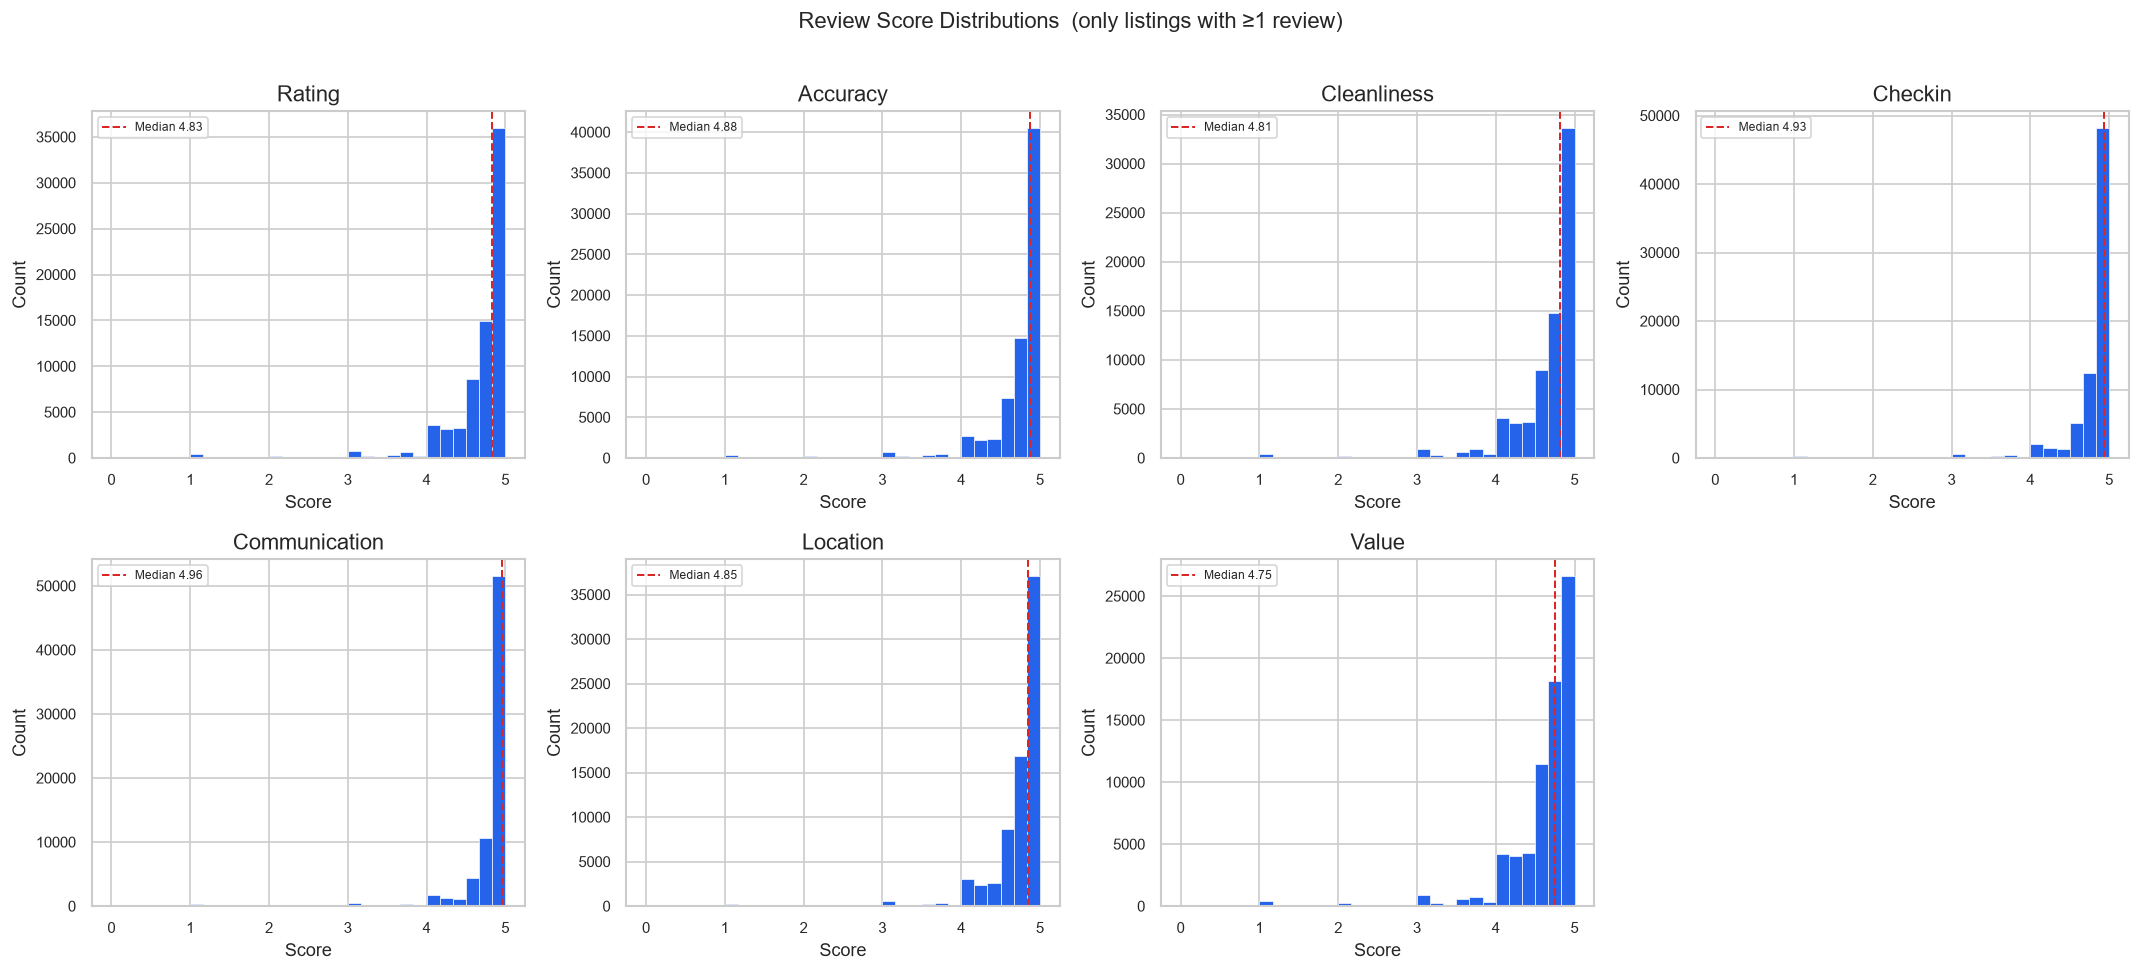

Review score summary:
       review_scores_rating  review_scores_accuracy  review_scores_cleanliness  review_scores_checkin  review_scores_communication  review_scores_location  review_scores_value
count              72749.00                72734.00                   72740.00               72706.00                     72729.00                72705.00             72705.00
mean                   4.68                    4.73                       4.65                   4.79                         4.81                    4.73                 4.62
std                    0.49                    0.48                       0.52                   0.43                         0.43                    0.41                 0.51
min                    0.00                    0.00                       0.00                   0.00                         0.00                    0.00                 0.00
25%                    4.58                    4.67                       4.51                   4

In [16]:
# ── Chart 8 — Review score distributions ─────────────────────────────────────
# Shows how ratings cluster. Right-skew (most listings near 5) is typical;
# the long left tail is what matters for quality filtering later.

score_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]
# Only plot columns that exist in the loaded dataframe
available_score_cols = [c for c in score_cols if c in listings.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(available_score_cols):
    s = listings[col].dropna()
    axes[i].hist(s, bins=30, color="#2563eb", edgecolor="white", linewidth=0.4)
    label = col.replace("review_scores_", "").replace("_", " ").title()
    axes[i].set_title(label)
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Count")
    # Red median line so the mode-vs-median gap is obvious
    axes[i].axvline(s.median(), color="#dc2626", linestyle="--", linewidth=1.2,
                    label=f"Median {s.median():.2f}")
    axes[i].legend(fontsize=7)

# Hide the unused 8th subplot
for j in range(len(available_score_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Review Score Distributions  (only listings with ≥1 review)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "06_review_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Review score summary:")
print(listings[available_score_cols].describe().round(2).to_string())

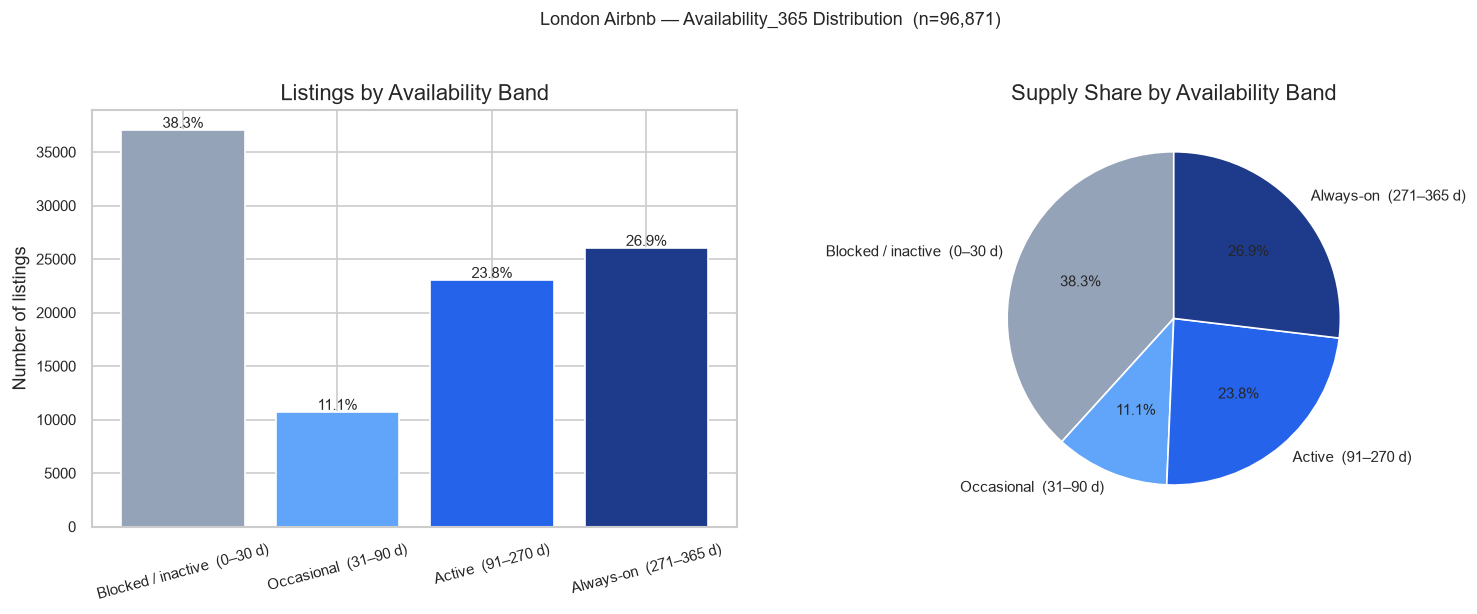

                        band  listing_count  share_pct  median_price  median_occupancy
Blocked / inactive  (0–30 d)          37067       38.3         131.0          1.000000
       Occasional  (31–90 d)          10717       11.1         118.0          0.810959
          Active  (91–270 d)          23045       23.8         134.0          0.479452
      Always-on  (271–365 d)          26042       26.9         145.0          0.049315


In [17]:
# ── Chart 9 — Availability band distribution ─────────────────────────────────
# Availability_365 (from the listings snapshot) shows how open each listing is.
# Four bands map naturally to host intent: blocked/inactive → casual → active → always-on.
# Uses full listings DataFrame (all 96k rows), not just price-eligible.

def _avail_band(days: int) -> str:
    if days <= 30:   return "Blocked / inactive  (0–30 d)"
    if days <= 90:   return "Occasional  (31–90 d)"
    if days <= 270:  return "Active  (91–270 d)"
    return "Always-on  (271–365 d)"

listings["avail_band"] = listings["availability_365"].apply(_avail_band)

band_order = [
    "Blocked / inactive  (0–30 d)",
    "Occasional  (31–90 d)",
    "Active  (91–270 d)",
    "Always-on  (271–365 d)",
]
band_colors = ["#94a3b8", "#60a5fa", "#2563eb", "#1e3a8a"]

band_counts = listings["avail_band"].value_counts().reindex(band_order)
band_pct    = (band_counts / len(listings) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: absolute listing count per band
axes[0].bar(band_order, band_counts.values, color=band_colors)
axes[0].set_title("Listings by Availability Band")
axes[0].set_ylabel("Number of listings")
axes[0].tick_params(axis="x", labelrotation=15)
for i, (cnt, pct) in enumerate(zip(band_counts.values, band_pct.values)):
    axes[0].text(i, cnt + 200, f"{pct}%", ha="center", fontsize=9)

# Pie chart: share of supply by band
axes[1].pie(band_counts.values, labels=band_order, colors=band_colors,
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 9})
axes[1].set_title("Supply Share by Availability Band")

plt.suptitle("London Airbnb — Availability_365 Distribution  (n=96,871)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "07_availability_bands.png", dpi=150, bbox_inches="tight")
plt.show()

# Save summary table
avail_summary = pd.DataFrame({
    "band": band_order,
    "listing_count": band_counts.values,
    "share_pct": band_pct.values,
    "median_price": [
        listings.loc[listings["avail_band"] == b, "price_numeric"].median()
        for b in band_order
    ],
    "median_occupancy": [
        listings.loc[listings["avail_band"] == b, "occupancy_proxy"].median()
        for b in band_order
    ],
})
avail_summary.to_csv(TABLES / "availability_band_summary.csv", index=False)

print(avail_summary.to_string(index=False))

---
## Step 3 — Geographic and Spatial Analysis

Covers: listing density by borough (listings per km²), price gradient vs distance
from city centre, median review score choropleth, and room-type clustering.

GeoJSON boundary file: `data/raw/london/neighbourhoods.geojson` (33 boroughs, EPSG:4326).  
Area calculations reprojected to EPSG:27700 (British National Grid) for metric accuracy.

In [18]:
# ── 7.1 + 7.2 — Validate coordinates and load neighbourhood boundaries ────────
# Drop the tiny fraction of listings with impossible lat/lon before any spatial work.

geo_listings = listings[
    listings["latitude"].between(-90, 90)
    & listings["longitude"].between(-180, 180)
    & listings["latitude"].notna()
    & listings["longitude"].notna()
].copy()

print(f"Coordinate-valid listings: {len(geo_listings):,}  "
      f"(dropped {len(listings) - len(geo_listings)} with bad/missing coords)")

# Load borough polygon boundaries
boroughs = gpd.read_file(RAW / "neighbourhoods.geojson")  # EPSG:4326, 33 rows
print(f"Borough polygons loaded: {len(boroughs)} — CRS: {boroughs.crs}")

# Convert listing lat/lon to geometry points (same CRS as boroughs)
listing_points = gpd.GeoDataFrame(
    geo_listings,
    geometry=gpd.points_from_xy(geo_listings["longitude"], geo_listings["latitude"]),
    crs="EPSG:4326",
)

# Reproject boroughs to EPSG:27700 (British National Grid) for area in metres
# EPSG:27700 is the correct metric projection for Great Britain (D-018)
boroughs_bng = boroughs.to_crs("EPSG:27700")
boroughs_bng["area_km2"] = (boroughs_bng.geometry.area / 1e6).round(3)

print("\nBorough area sample (km²):")
print(boroughs_bng[["neighbourhood", "area_km2"]].sort_values("area_km2", ascending=False).head(8).to_string(index=False))

Coordinate-valid listings: 96,871  (dropped 0 with bad/missing coords)
Borough polygons loaded: 33 — CRS: EPSG:4326



Borough area sample (km²):
       neighbourhood  area_km2
             Bromley   150.135
          Hillingdon   115.704
            Havering   112.352
              Barnet    86.750
             Croydon    86.496
             Enfield    82.202
              Bexley    60.581
Richmond upon Thames    57.355


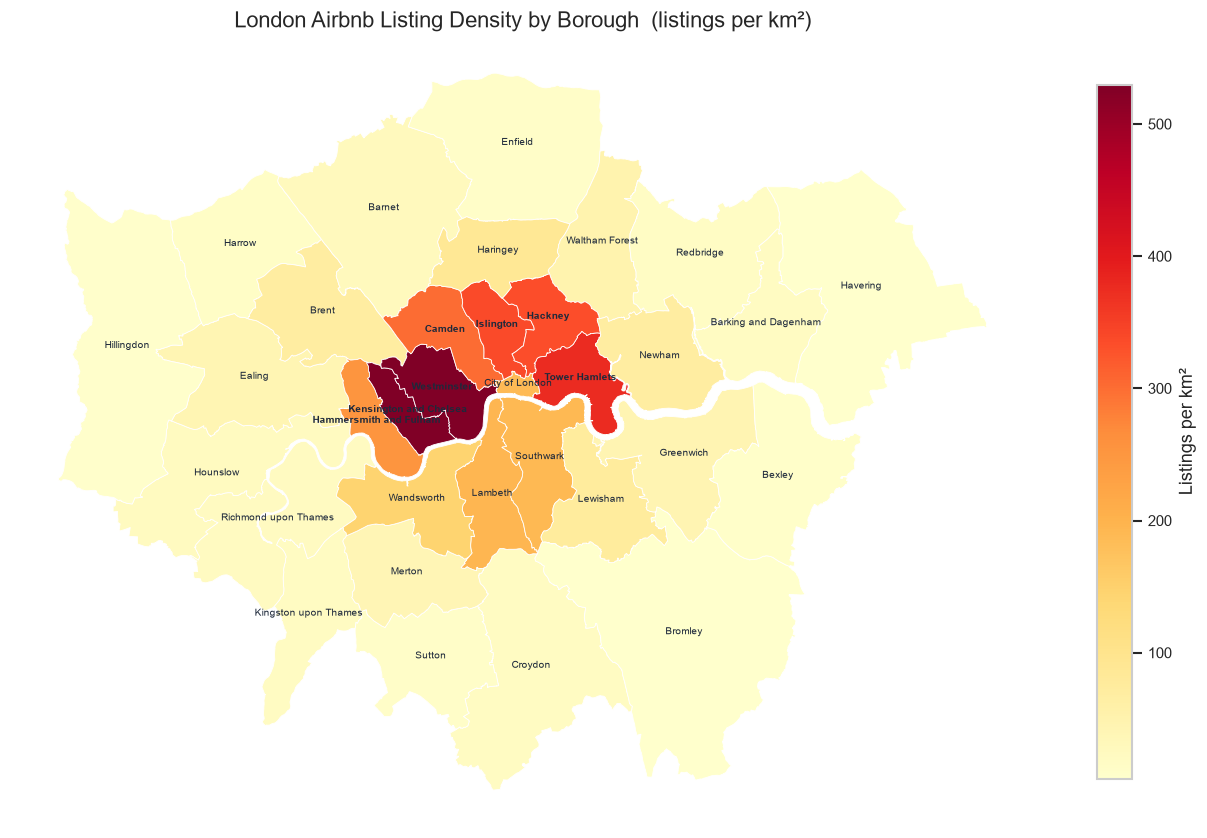

Top 10 boroughs by density:
         neighbourhood  listing_count  area_km2  listings_per_km2
           Westminster          11385    21.488             529.8
Kensington and Chelsea           6401    12.124             528.0
         Tower Hamlets           7469    19.779             377.6
             Islington           5036    14.857             339.0
               Hackney           6359    19.050             333.8
                Camden           6551    21.790             300.6
Hammersmith and Fulham           4157    16.398             253.5
               Lambeth           5190    26.811             193.6
             Southwark           5475    28.863             189.7
        City of London            549     2.904             189.0


In [19]:
# ── Chart 10 — Listing density choropleth (listings per km²) ─────────────────
# Raw listing counts favour large boroughs; density normalises by area.
# Join on: listings["neighbourhood_cleansed"] ↔ boroughs["neighbourhood"]

listing_count_by_borough = (
    geo_listings.groupby("neighbourhood_cleansed")
    .agg(listing_count=("id", "count"), unique_hosts=("host_id", "nunique"))
    .reset_index()
    .rename(columns={"neighbourhood_cleansed": "neighbourhood"})
)

density_gdf = boroughs_bng.merge(listing_count_by_borough, on="neighbourhood", how="left")
density_gdf["listings_per_km2"] = (
    density_gdf["listing_count"] / density_gdf["area_km2"]
).round(1)

density_gdf.to_file(  # overwrite-safe: produces GeoJSON, not the source file
    str(TABLES / "neighbourhood_density.csv").replace(".csv", ".geojson"),
    driver="GeoJSON"
)
# Also save a flat CSV for the API / report
density_gdf.drop(columns="geometry").to_csv(TABLES / "neighbourhood_density.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 10))
density_gdf.plot(
    column="listings_per_km2",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Listings per km²", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "#e2e8f0", "label": "No data"},
)

# Label each borough centroid with its name
for _, row in density_gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(row["neighbourhood"], xy=(cx, cy),
                ha="center", fontsize=6, color="#1e293b",
                fontweight="bold" if row["listings_per_km2"] > 200 else "normal")

ax.set_title("London Airbnb Listing Density by Borough  (listings per km²)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "08_listing_density_map.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 boroughs by density:")
print(density_gdf[["neighbourhood","listing_count","area_km2","listings_per_km2"]]
      .sort_values("listings_per_km2", ascending=False).head(10).to_string(index=False))

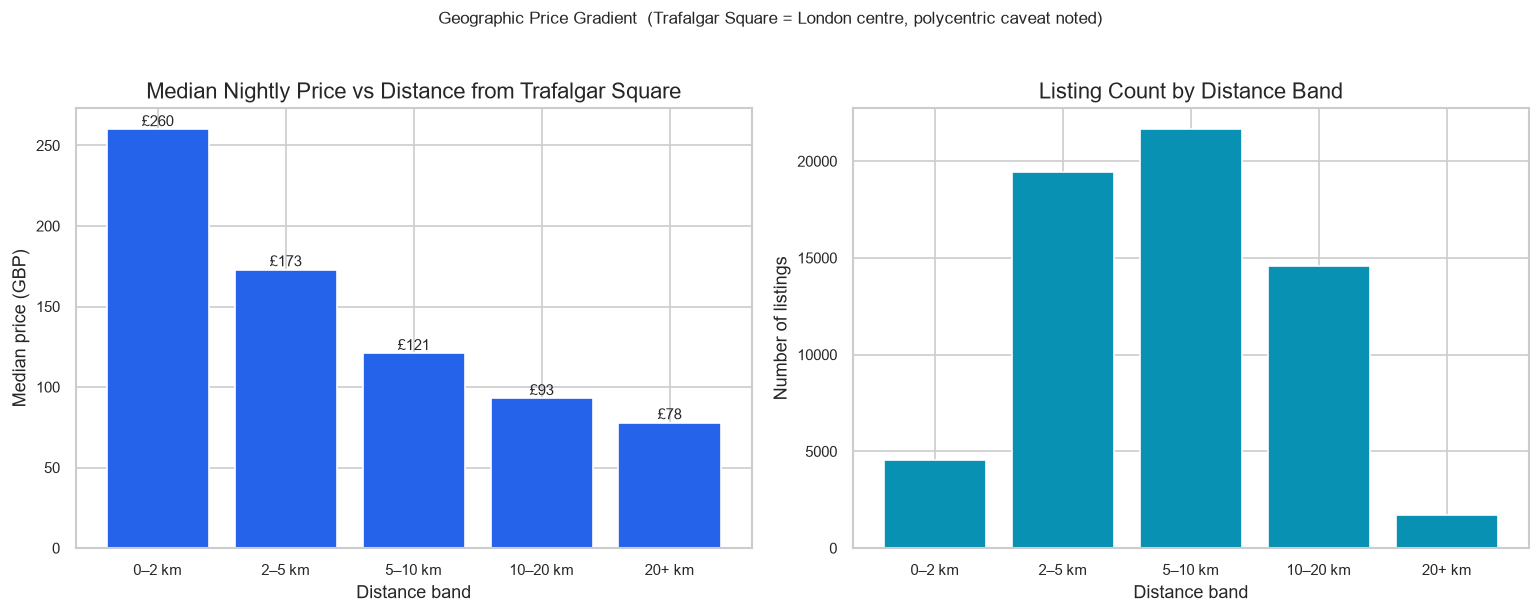

           listing_count  median_price  mean_price    p75
dist_band                                                
0–2 km              4551         260.0       470.0  396.0
2–5 km             19457         173.0       262.0  278.0
5–10 km            21645         121.0       225.0  190.0
10–20 km           14603          93.0       131.0  153.0
20+ km              1707          78.0       124.0  137.0


In [20]:
# ── Chart 11 — Price gradient by distance from city centre ───────────────────
# City centre = Trafalgar Square (well-documented single reference, acknowledged limitation).
# Limitation: London is polycentric; a single point oversimplifies, but is standard.

import math

CENTRE_LAT = 51.5080   # Trafalgar Square
CENTRE_LON = -0.1281

def _haversine_km(lat1, lon1, lat2, lon2) -> float:
    """Great-circle distance in km."""
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat/2)**2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

geo_listings["dist_km"] = geo_listings.apply(
    lambda r: _haversine_km(r["latitude"], r["longitude"], CENTRE_LAT, CENTRE_LON),
    axis=1,
)

def _dist_band(d: float) -> str:
    if d <= 2:   return "0–2 km"
    if d <= 5:   return "2–5 km"
    if d <= 10:  return "5–10 km"
    if d <= 20:  return "10–20 km"
    return "20+ km"

geo_listings["dist_band"] = geo_listings["dist_km"].apply(_dist_band)

band_order_dist = ["0–2 km", "2–5 km", "5–10 km", "10–20 km", "20+ km"]

price_by_dist = (
    geo_listings[geo_listings["price_numeric"].notna()]
    .groupby("dist_band", observed=True)["price_numeric"]
    .agg(
        listing_count="count",
        median_price="median",
        mean_price="mean",
        p75=lambda x: x.quantile(0.75),
    )
    .reindex(band_order_dist)
    .round(0)
)
price_by_dist.to_csv(TABLES / "price_by_distance_band.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(price_by_dist.index, price_by_dist["median_price"], color="#2563eb")
axes[0].set_title("Median Nightly Price vs Distance from Trafalgar Square")
axes[0].set_xlabel("Distance band")
axes[0].set_ylabel("Median price (GBP)")
for i, (idx, row) in enumerate(price_by_dist.iterrows()):
    axes[0].text(i, row["median_price"] + 2, f"£{int(row['median_price'])}", ha="center", fontsize=9)

axes[1].bar(price_by_dist.index, price_by_dist["listing_count"], color="#0891b2")
axes[1].set_title("Listing Count by Distance Band")
axes[1].set_xlabel("Distance band")
axes[1].set_ylabel("Number of listings")

plt.suptitle("Geographic Price Gradient  (Trafalgar Square = London centre, polycentric caveat noted)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "09_price_gradient_by_distance.png", dpi=150, bbox_inches="tight")
plt.show()

print(price_by_dist.to_string())

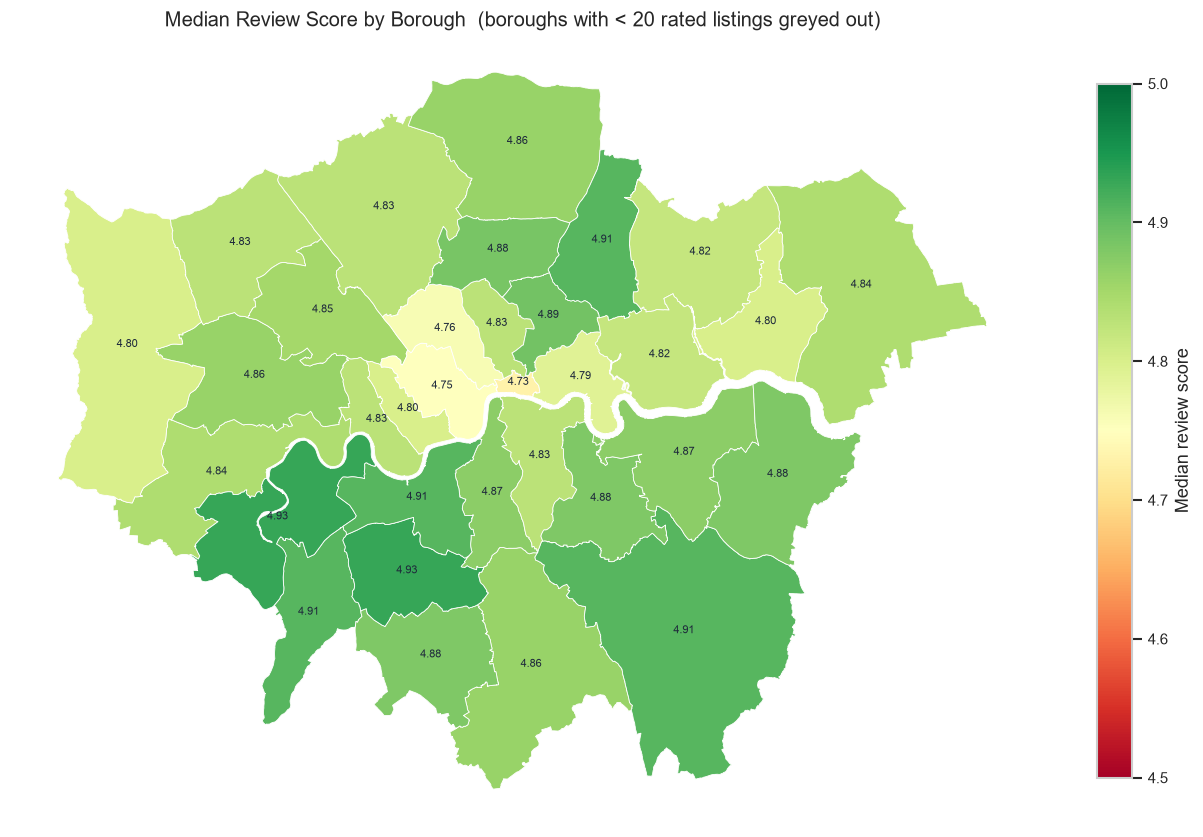

         neighbourhood  rated_listing_count  median_rating  mean_rating
  Richmond upon Thames                  985          4.930     4.814264
                Merton                 1128          4.930     4.785860
  Kingston upon Thames                  548          4.910     4.777464
               Bromley                  653          4.910     4.774824
        Waltham Forest                 1422          4.910     4.756646
            Wandsworth                 3700          4.910     4.773305
               Hackney                 4906          4.890     4.763106
              Haringey                 1928          4.885     4.735156
                Sutton                  336          4.880     4.726250
                Bexley                  429          4.880     4.735688
              Lewisham                 2018          4.880     4.721601
             Greenwich                 1519          4.870     4.691145
               Lambeth                 4050          4.870     4

In [21]:
# ── Chart 12 — Median review score choropleth by borough ─────────────────────
# Plan requirement: min 20 rated listings per borough before including in map.
# Boroughs below threshold are shown in grey.

rating_by_borough = (
    listings.groupby("neighbourhood_cleansed")
    .agg(
        rated_listing_count=("review_scores_rating", "count"),
        median_rating=("review_scores_rating", "median"),
        mean_rating=("review_scores_rating", "mean"),
    )
    .reset_index()
    .rename(columns={"neighbourhood_cleansed": "neighbourhood"})
)

# Mask boroughs with fewer than 20 rated listings (too noisy to interpret)
rating_by_borough.loc[rating_by_borough["rated_listing_count"] < 20, "median_rating"] = None

rating_gdf = boroughs_bng.merge(rating_by_borough, on="neighbourhood", how="left")

fig, ax = plt.subplots(figsize=(11, 10))
rating_gdf.plot(
    column="median_rating",
    cmap="RdYlGn",          # red = low rating, green = high
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Median review score", "shrink": 0.6},
    ax=ax,
    missing_kwds={"color": "#e2e8f0", "label": "< 20 rated listings"},
    vmin=4.5, vmax=5.0,     # compress the range — scores cluster near 5
)

for _, row in rating_gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    if pd.notna(row.get("median_rating")):
        ax.annotate(f"{row['median_rating']:.2f}", xy=(cx, cy),
                    ha="center", fontsize=6.5, color="#1e293b")

ax.set_title("Median Review Score by Borough  (boroughs with < 20 rated listings greyed out)",
             fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "10_review_score_map.png", dpi=150, bbox_inches="tight")
plt.show()

print(rating_by_borough.sort_values("median_rating", ascending=False).to_string(index=False))

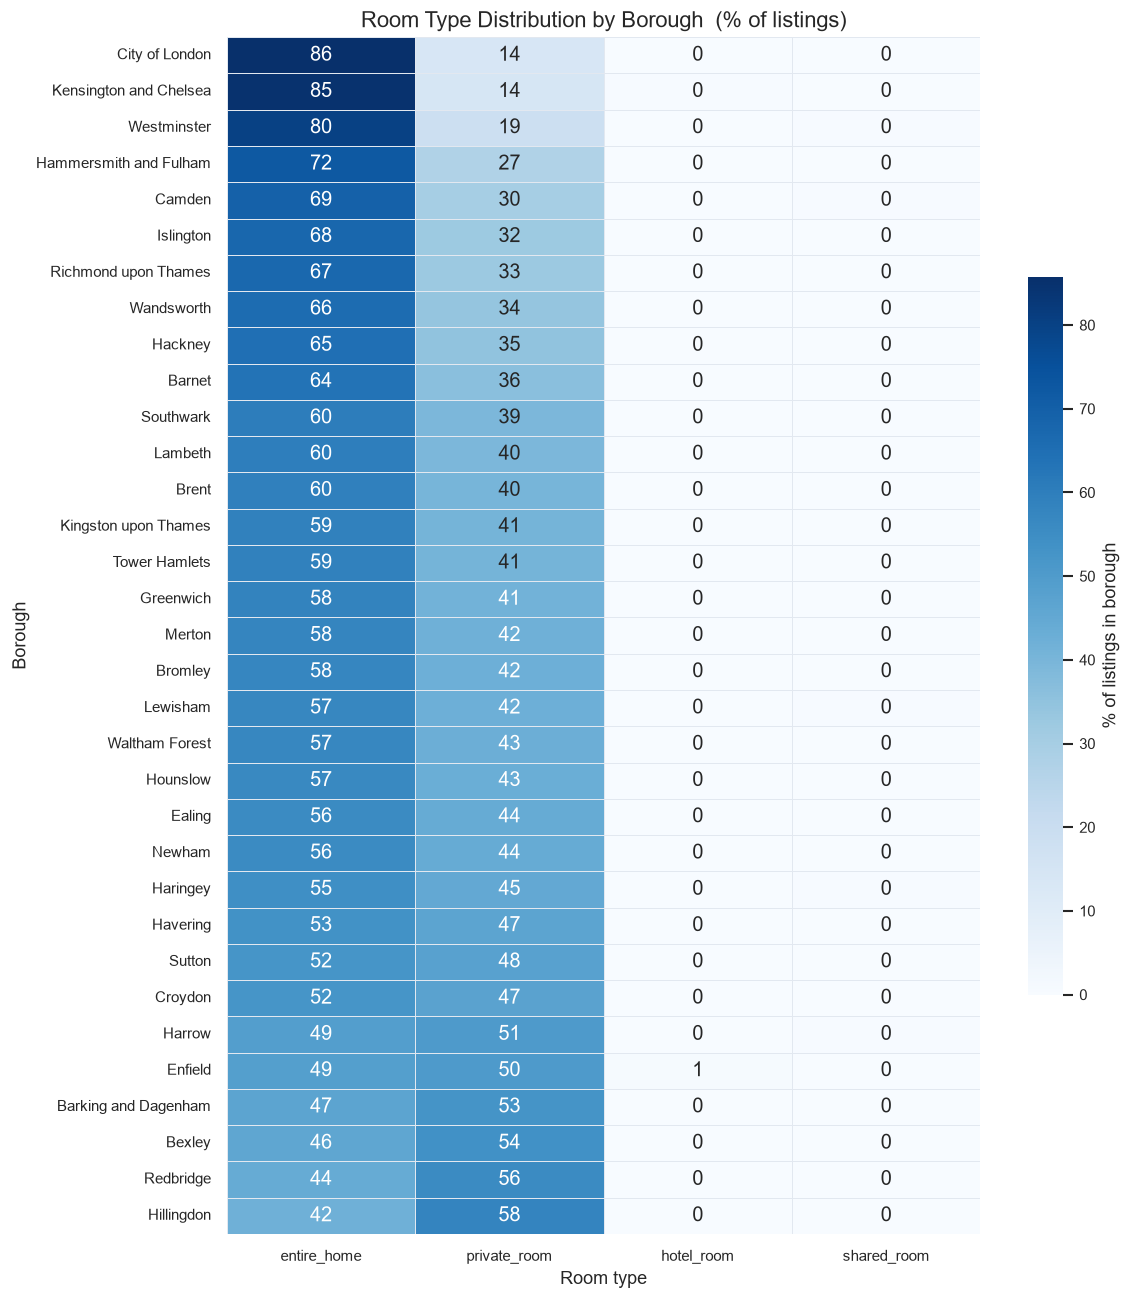

Top 5 entire-home boroughs:
neighbourhood_cleansed
City of London            85.8
Kensington and Chelsea    85.0
Westminster               80.4
Hammersmith and Fulham    72.3
Camden                    69.4


In [22]:
# ── Chart 13 — Room-type clustering by neighbourhood (heatmap) ───────────────
# Shows where entire homes, private rooms, etc. concentrate.
# Normalised to % of listings in each borough so borough size doesn't dominate.

room_type_pct = pd.crosstab(
    listings["neighbourhood_cleansed"],
    listings["room_type"],
    normalize="index",
) * 100

room_type_pct = room_type_pct.round(1)
room_type_pct.to_csv(TABLES / "room_type_by_neighbourhood.csv")

# Sort boroughs by entire_home share descending for a natural reading order
col_order = ["entire_home", "private_room", "hotel_room", "shared_room"]
col_order = [c for c in col_order if c in room_type_pct.columns]
room_type_pct = room_type_pct[col_order]
room_type_pct = room_type_pct.sort_values("entire_home", ascending=False)

fig, ax = plt.subplots(figsize=(10, 11))
sns.heatmap(
    room_type_pct,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.4,
    linecolor="#e2e8f0",
    cbar_kws={"label": "% of listings in borough", "shrink": 0.6},
    ax=ax,
)
ax.set_title("Room Type Distribution by Borough  (% of listings)", fontsize=13)
ax.set_xlabel("Room type")
ax.set_ylabel("Borough")
plt.tight_layout()
plt.savefig(FIGS / "11_room_type_by_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 entire-home boroughs:")
print(room_type_pct["entire_home"].sort_values(ascending=False).head(5).to_string())

---
## Step 4 — Temporal and Seasonal Trends

> **A-005 reminder:** `calendar.price` is 100 % NULL in this snapshot.  
> Sections 8.1 and 8.2 use **availability/occupancy** in place of price.

Covers: monthly availability trend (Sep 2025 → Sep 2026), weekday vs weekend
availability, review volume growth (2009 → 2025), host tenure analysis, and
minimum-night policy trends from the calendar.

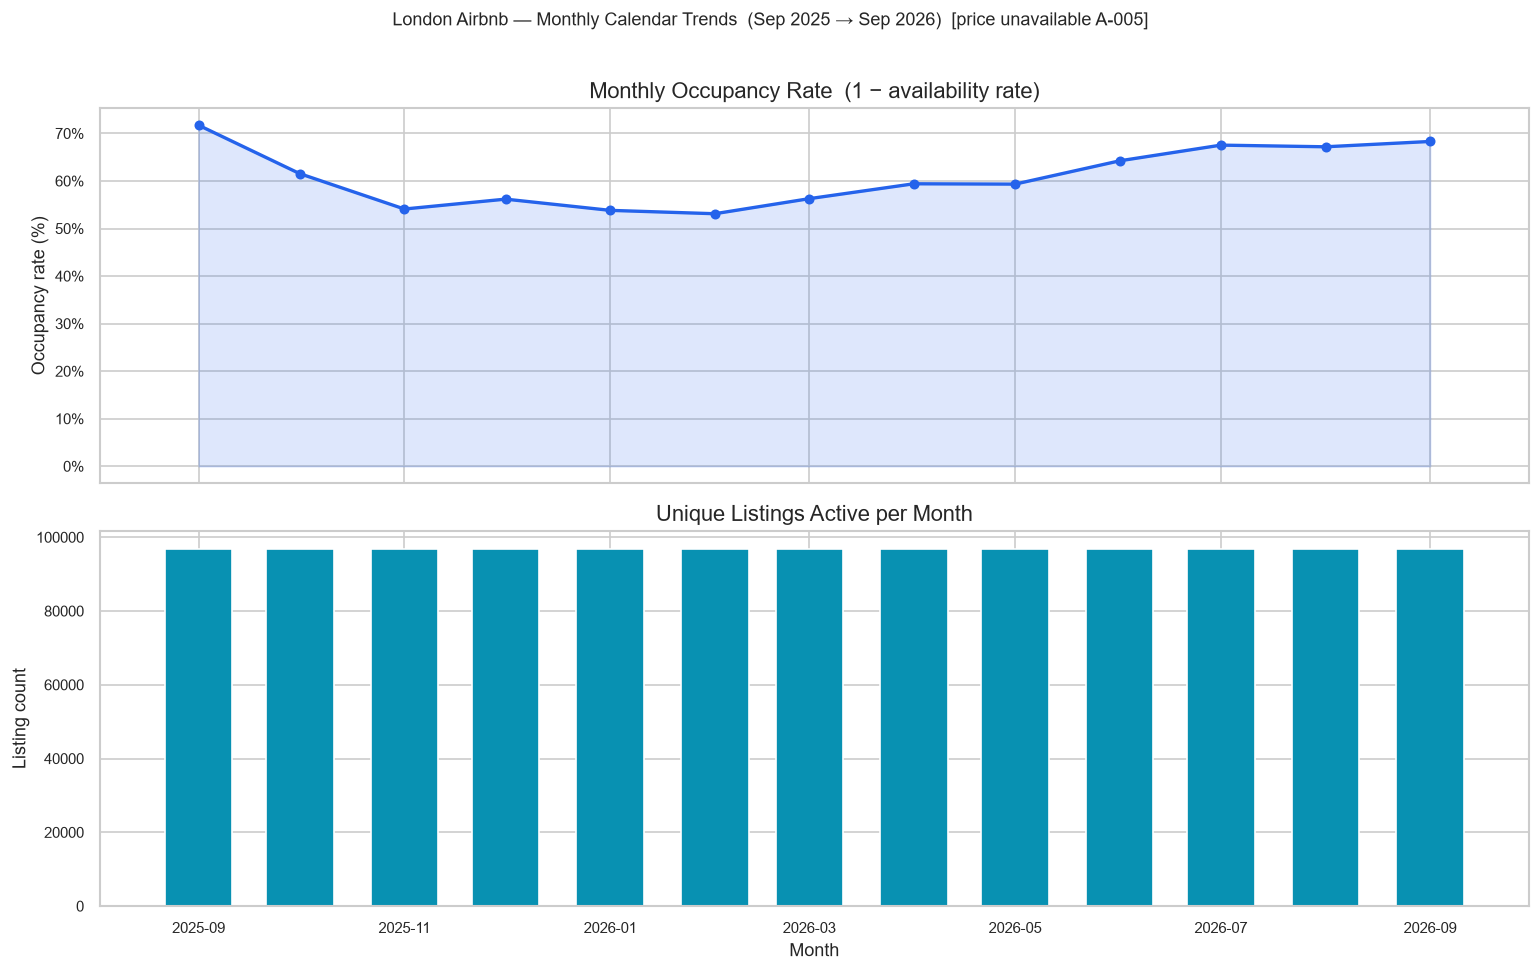

Peak occupancy month : Sep 2025  (71.7%)


In [23]:
# ── Chart 14 — Monthly availability trend (A-005 adapted) ────────────────────
# Plan 8.1 asks for monthly price trend; since price is NULL (A-005) we track
# the monthly mean availability rate instead. A lower availability rate means
# more days are booked — higher demand signal.
# Calendar covers Sep 2025 → Sep 2026 (one forward-looking year).

calendar["month"] = calendar["date"].dt.to_period("M").dt.to_timestamp()

monthly_avail = (
    calendar.groupby("month")
    .agg(
        total_days=("available_int", "count"),
        available_days=("available_int", "sum"),
        unique_listings=("listing_id", "nunique"),
    )
    .reset_index()
)
monthly_avail["availability_rate"] = (
    monthly_avail["available_days"] / monthly_avail["total_days"]
).round(4)
monthly_avail["occupancy_rate"] = 1 - monthly_avail["availability_rate"]
monthly_avail.to_csv(TABLES / "monthly_availability.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Occupancy rate by month
axes[0].plot(monthly_avail["month"], monthly_avail["occupancy_rate"] * 100,
             marker="o", color="#2563eb", linewidth=2, markersize=5)
axes[0].fill_between(monthly_avail["month"], monthly_avail["occupancy_rate"] * 100,
                     alpha=0.15, color="#2563eb")
axes[0].set_title("Monthly Occupancy Rate  (1 − availability rate)")
axes[0].set_ylabel("Occupancy rate (%)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Unique active listings by month (shows supply volume)
axes[1].bar(monthly_avail["month"], monthly_avail["unique_listings"],
            color="#0891b2", width=20)
axes[1].set_title("Unique Listings Active per Month")
axes[1].set_ylabel("Listing count")
axes[1].set_xlabel("Month")

plt.suptitle("London Airbnb — Monthly Calendar Trends  (Sep 2025 → Sep 2026)  [price unavailable A-005]",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "12_monthly_availability_trend.png", dpi=150, bbox_inches="tight")
plt.show()

peak = monthly_avail.loc[monthly_avail["occupancy_rate"].idxmax()]
print(f"Peak occupancy month : {peak['month'].strftime('%b %Y')}  ({peak['occupancy_rate']*100:.1f}%)")

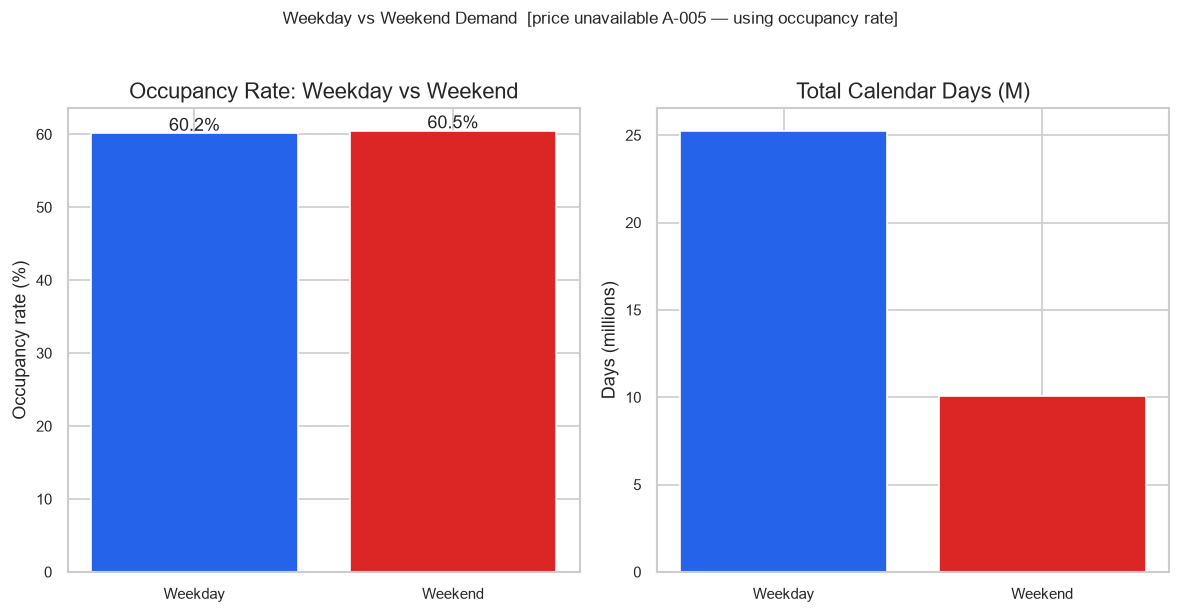

  label  total_days  occupancy_rate
Weekday    25270396        0.601830
Weekend    10087578        0.605238


In [24]:
# ── Chart 15 — Weekday vs weekend availability (A-005 adapted) ───────────────
# Plan 8.2 uses calendar price for weekday/weekend comparison.
# With A-005, we compare availability rates — lower = more booked = higher demand.

calendar["is_weekend"] = calendar["date"].dt.dayofweek >= 5  # Sat=5, Sun=6

weekpart = (
    calendar.groupby("is_weekend")
    .agg(
        total_days=("available_int", "count"),
        available_days=("available_int", "sum"),
        unique_listings=("listing_id", "nunique"),
    )
    .reset_index()
)
weekpart["availability_rate"] = weekpart["available_days"] / weekpart["total_days"]
weekpart["occupancy_rate"]    = 1 - weekpart["availability_rate"]
weekpart["label"] = weekpart["is_weekend"].map({False: "Weekday", True: "Weekend"})
weekpart.to_csv(TABLES / "weekday_weekend_availability.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

colors = ["#2563eb", "#dc2626"]
axes[0].bar(weekpart["label"], weekpart["occupancy_rate"] * 100, color=colors)
axes[0].set_title("Occupancy Rate: Weekday vs Weekend")
axes[0].set_ylabel("Occupancy rate (%)")
for i, (_, row) in enumerate(weekpart.iterrows()):
    axes[0].text(i, row["occupancy_rate"] * 100 + 0.3,
                 f"{row['occupancy_rate']*100:.1f}%", ha="center", fontsize=11)

axes[1].bar(weekpart["label"], weekpart["total_days"] / 1e6, color=colors)
axes[1].set_title("Total Calendar Days (M)")
axes[1].set_ylabel("Days (millions)")

plt.suptitle("Weekday vs Weekend Demand  [price unavailable A-005 — using occupancy rate]",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "13_weekday_vs_weekend_availability.png", dpi=150, bbox_inches="tight")
plt.show()

print(weekpart[["label","total_days","occupancy_rate"]].to_string(index=False))

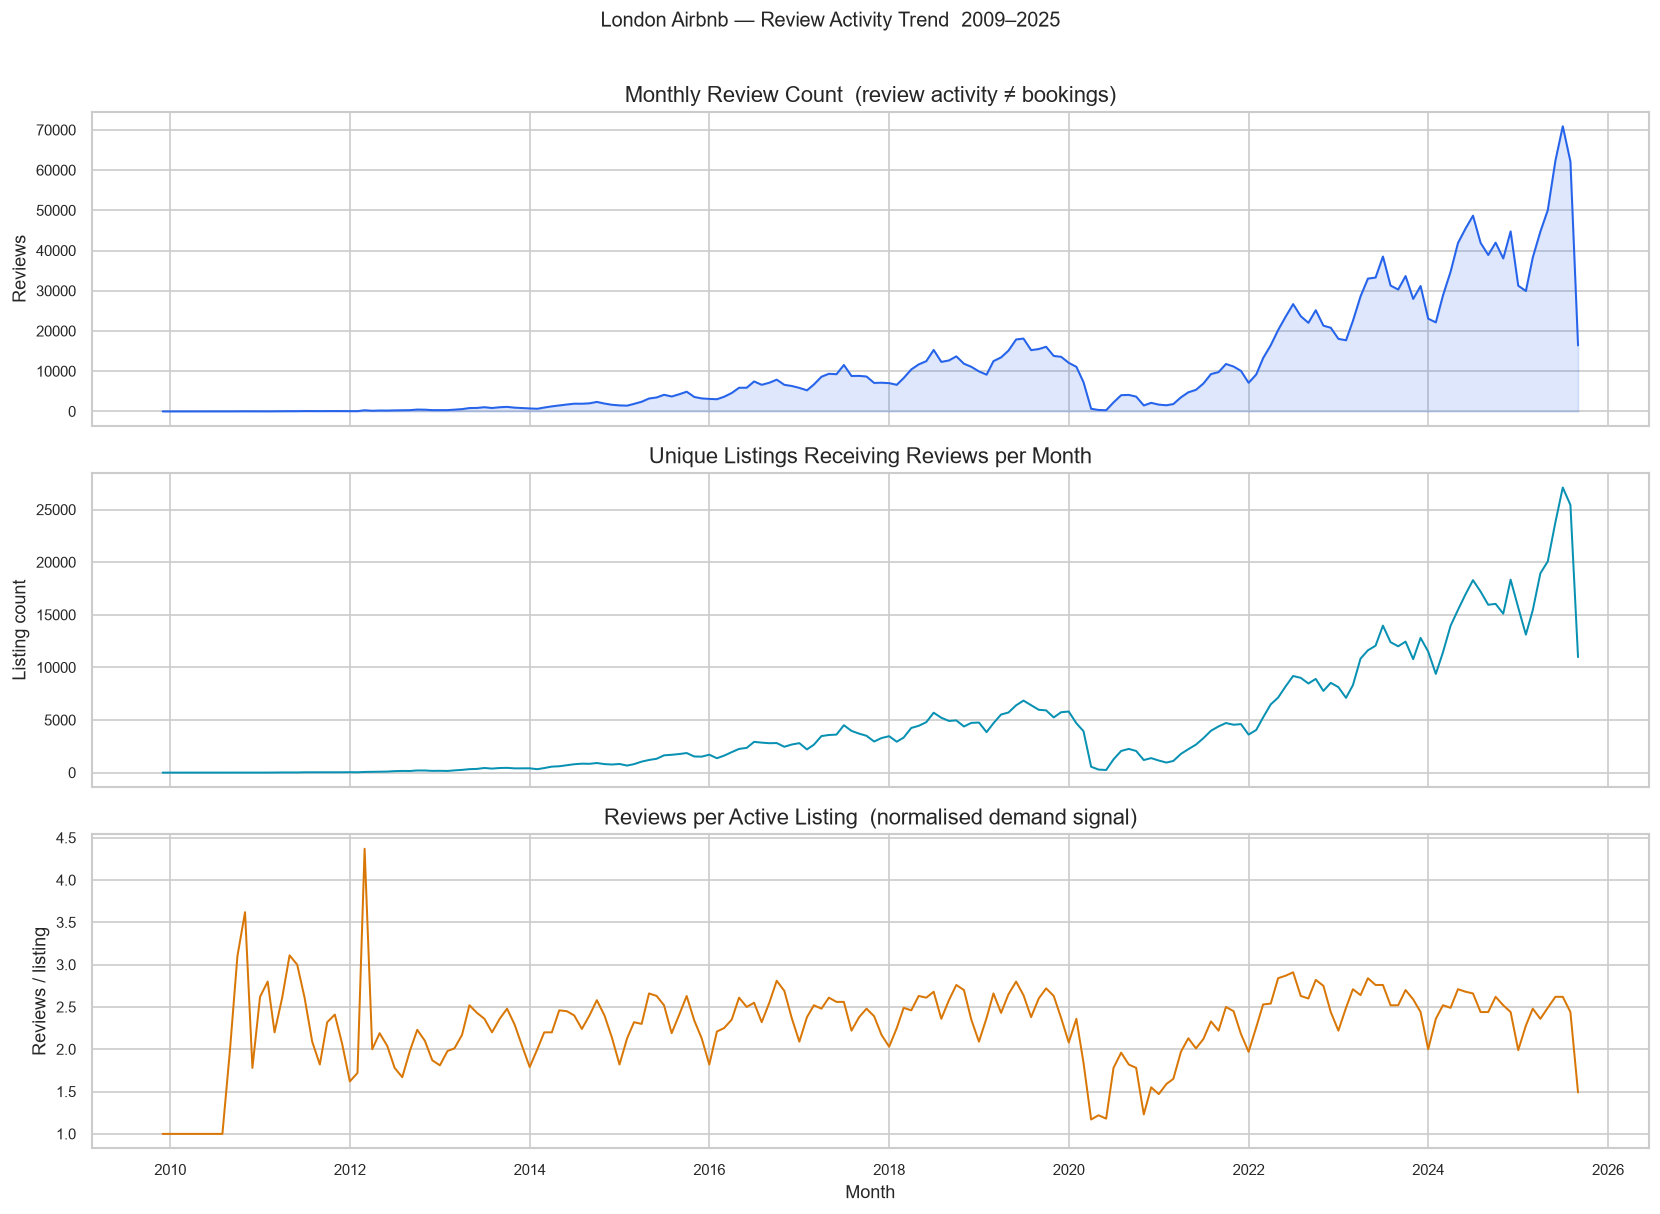

Peak review month : Jul 2025  (70,916 reviews)


In [25]:
# ── Chart 16 — Monthly review volume (2009 → 2025) ───────────────────────────
# Plan 8.3: review volume as a demand proxy.
# Note: reviews["id"] is the review identifier (not "review_id").
# Review volume ≠ booking volume — framed as "review activity" throughout.

reviews["month"] = reviews["date"].dt.to_period("M").dt.to_timestamp()

monthly_reviews = (
    reviews.groupby("month")
    .agg(
        review_count=("id", "count"),
        active_listings=("listing_id", "nunique"),
    )
    .reset_index()
)
monthly_reviews["reviews_per_active_listing"] = (
    monthly_reviews["review_count"] / monthly_reviews["active_listings"]
).round(2)
monthly_reviews.to_csv(TABLES / "monthly_review_volume.csv", index=False)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Review count over time
axes[0].plot(monthly_reviews["month"], monthly_reviews["review_count"],
             color="#2563eb", linewidth=1.2)
axes[0].fill_between(monthly_reviews["month"], monthly_reviews["review_count"],
                     alpha=0.15, color="#2563eb")
axes[0].set_title("Monthly Review Count  (review activity ≠ bookings)")
axes[0].set_ylabel("Reviews")

# Unique active listings
axes[1].plot(monthly_reviews["month"], monthly_reviews["active_listings"],
             color="#0891b2", linewidth=1.2)
axes[1].set_title("Unique Listings Receiving Reviews per Month")
axes[1].set_ylabel("Listing count")

# Reviews per listing — normalises for platform growth
axes[2].plot(monthly_reviews["month"], monthly_reviews["reviews_per_active_listing"],
             color="#d97706", linewidth=1.2)
axes[2].set_title("Reviews per Active Listing  (normalised demand signal)")
axes[2].set_ylabel("Reviews / listing")
axes[2].set_xlabel("Month")

plt.suptitle("London Airbnb — Review Activity Trend  2009–2025", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "14_monthly_review_volume.png", dpi=150, bbox_inches="tight")
plt.show()

peak_month = monthly_reviews.loc[monthly_reviews["review_count"].idxmax()]
print(f"Peak review month : {peak_month['month'].strftime('%b %Y')}  "
      f"({int(peak_month['review_count']):,} reviews)")

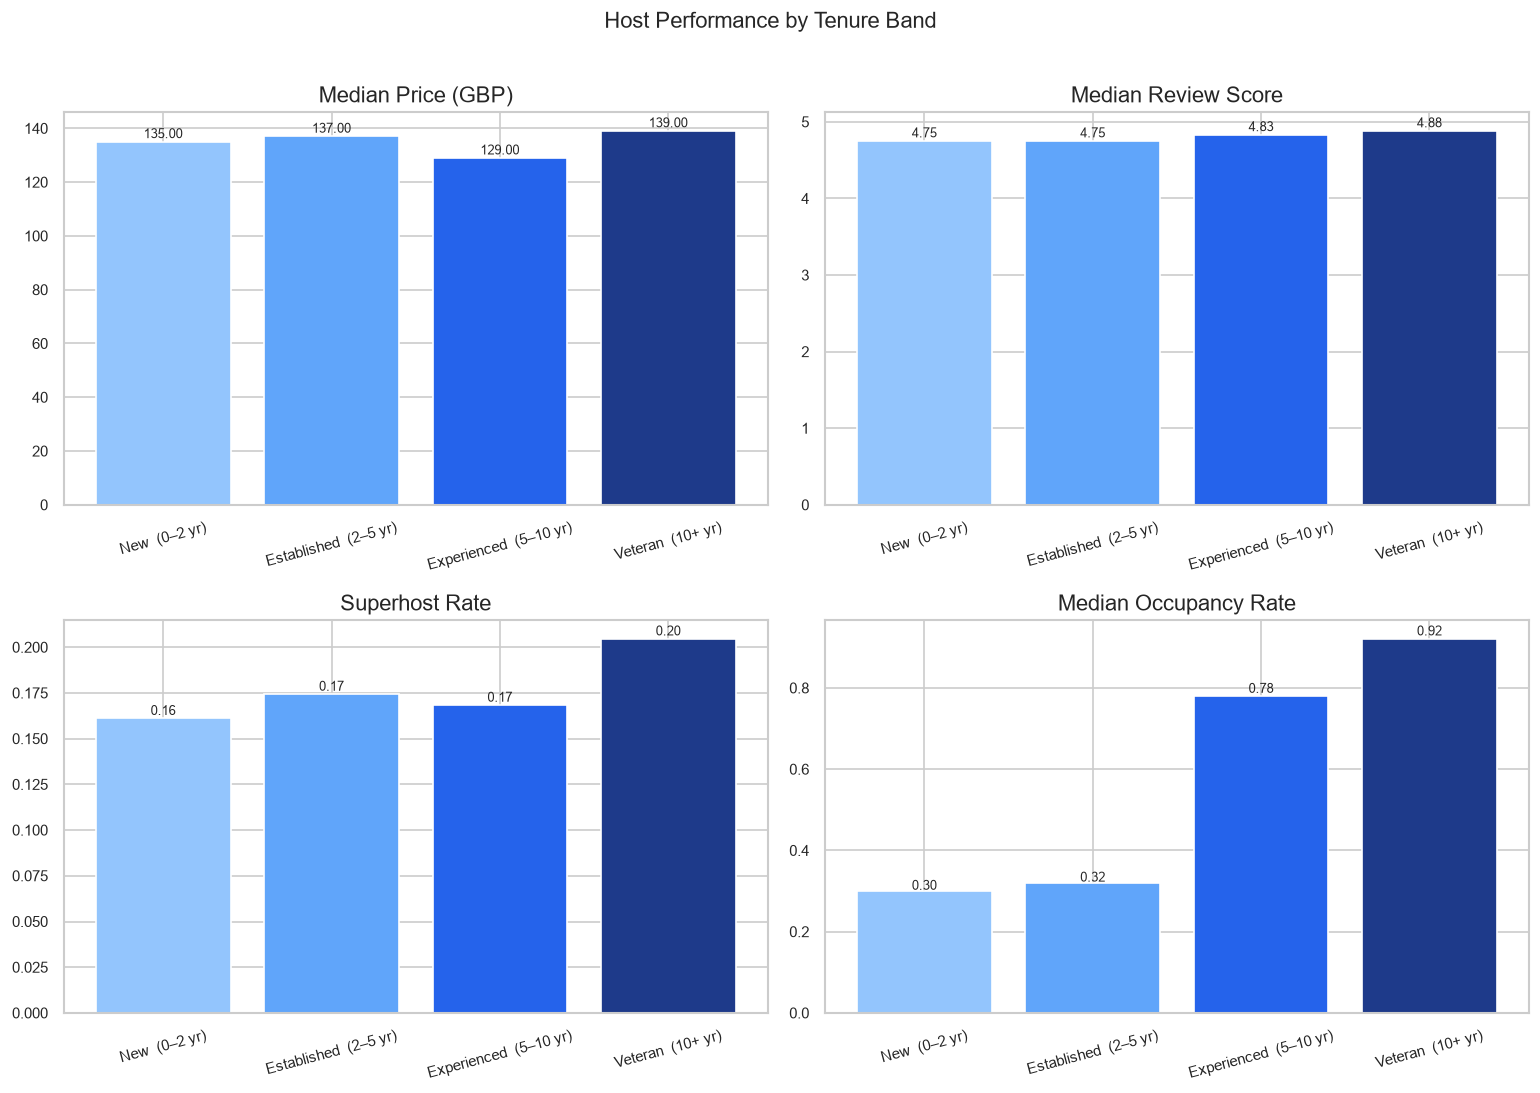

                        listing_count  unique_hosts  median_price  median_rating superhost_rate
tenure_band                                                                                    
New  (0–2 yr)                   11875          5241         135.0           4.75       0.161324
Established  (2–5 yr)           15012          6230         137.0           4.75       0.174454
Experienced  (5–10 yr)          37136         22087         129.0           4.83       0.168504
Veteran  (10+ yr)               32848         22088         139.0           4.88       0.204405


In [26]:
# ── Chart 17 — Host tenure analysis (plan 8.4) ───────────────────────────────
# host_tenure_years already computed in listing_master (snapshot_date - host_since).
# Four bands: New (0-2y) → Established (2-5y) → Experienced (5-10y) → Veteran (10+y).

def _tenure_band(y: float) -> str:
    if y <= 2:   return "New  (0–2 yr)"
    if y <= 5:   return "Established  (2–5 yr)"
    if y <= 10:  return "Experienced  (5–10 yr)"
    return "Veteran  (10+ yr)"

listings["tenure_band"] = listings["host_tenure_years"].apply(_tenure_band)

tenure_order = ["New  (0–2 yr)", "Established  (2–5 yr)", "Experienced  (5–10 yr)", "Veteran  (10+ yr)"]
tenure_colors = ["#93c5fd", "#60a5fa", "#2563eb", "#1e3a8a"]

tenure_sum = (
    listings.groupby("tenure_band")
    .agg(
        listing_count=("id", "count"),
        unique_hosts=("host_id", "nunique"),
        median_price=("price_numeric", "median"),
        median_rating=("review_scores_rating", "median"),
        superhost_rate=("host_is_superhost", "mean"),
        median_portfolio=("host_portfolio_size", "median"),
        median_occupancy=("occupancy_proxy", "median"),
    )
    .reindex(tenure_order)
    .round(2)
)
tenure_sum.to_csv(TABLES / "host_tenure_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

metrics = [
    ("median_price",    "Median Price (GBP)",    axes[0, 0]),
    ("median_rating",   "Median Review Score",   axes[0, 1]),
    ("superhost_rate",  "Superhost Rate",        axes[1, 0]),
    ("median_occupancy","Median Occupancy Rate", axes[1, 1]),
]

for col, title, ax in metrics:
    ax.bar(tenure_order, tenure_sum[col], color=tenure_colors)
    ax.set_title(title)
    ax.tick_params(axis="x", labelrotation=15)
    for i, v in enumerate(tenure_sum[col]):
        if pd.notna(v):
            ax.text(i, v * 1.01, f"{v:.2f}", ha="center", fontsize=8)

plt.suptitle("Host Performance by Tenure Band", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "15_host_tenure_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(tenure_sum[["listing_count","unique_hosts","median_price","median_rating","superhost_rate"]].to_string())

C:\Users\Bavikaran\AppData\Local\Temp\ipykernel_18360\2700568658.py:14: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


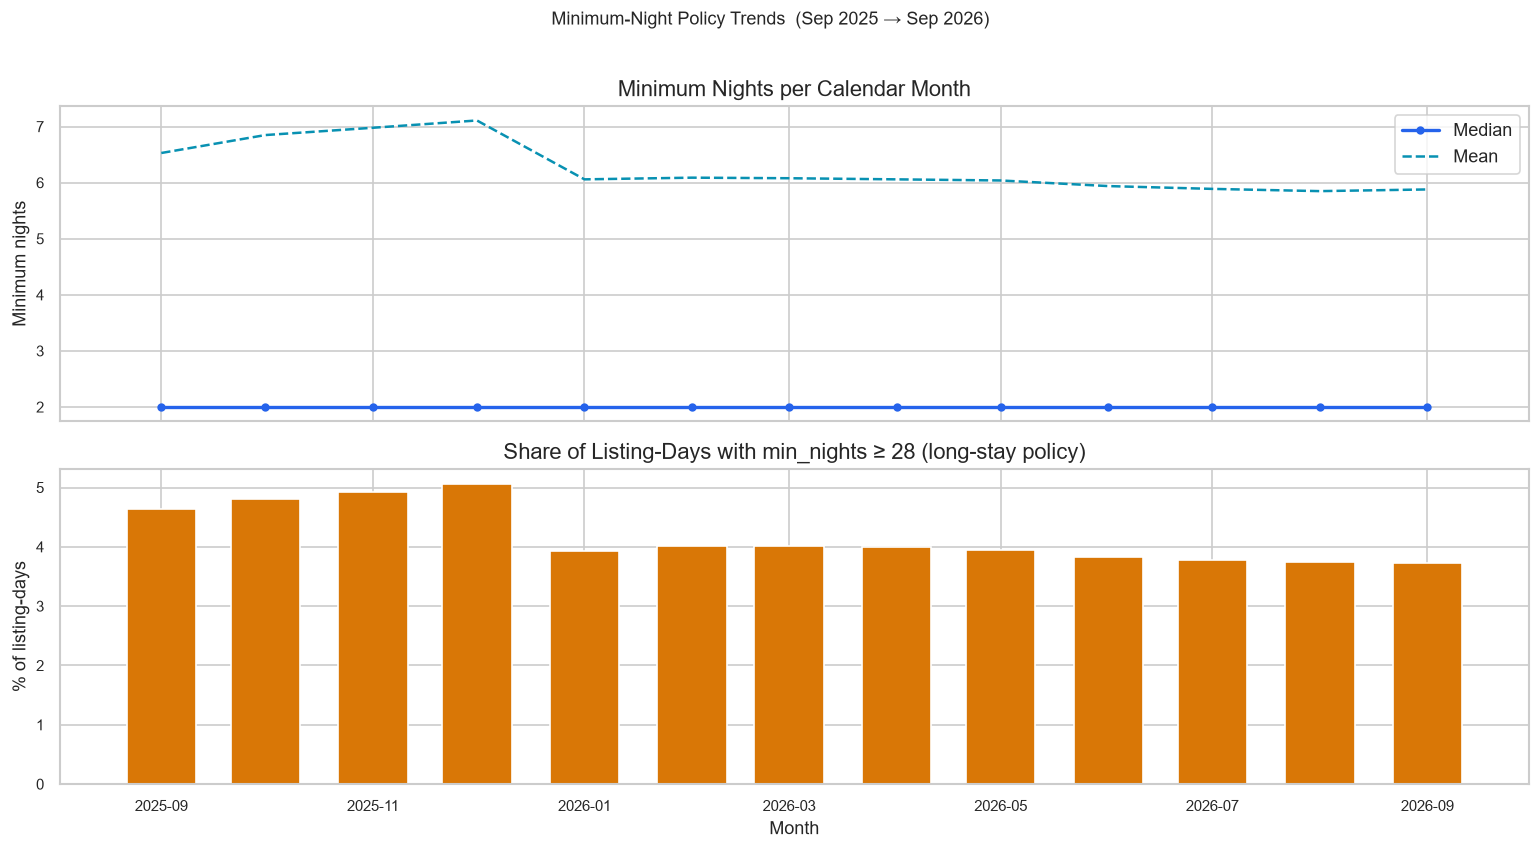

     month  median_min_nights  mean_min_nights  pct_longstay
2025-09-01                2.0             6.53          4.64
2025-10-01                2.0             6.85          4.81
2025-11-01                2.0             6.98          4.93
2025-12-01                2.0             7.11          5.06
2026-01-01                2.0             6.06          3.93
2026-02-01                2.0             6.09          4.02
2026-03-01                2.0             6.08          4.02
2026-04-01                2.0             6.06          3.99
2026-05-01                2.0             6.04          3.95
2026-06-01                2.0             5.94          3.83
2026-07-01                2.0             5.89          3.77
2026-08-01                2.0             5.85          3.75
2026-09-01                2.0             5.88          3.73


In [27]:
# ── Chart 18 — Minimum-night policy trend (plan 8.5) ─────────────────────────
# Shows how minimum_nights requirements vary across the calendar year.
# Uses calendar_clean.parquet which carries minimum_nights per (listing, date).
# High minimum_nights in later months can signal hosts adapting for long stays.

min_nights_monthly = (
    calendar.groupby("month")
    .agg(
        median_min_nights=("minimum_nights", "median"),
        mean_min_nights=("minimum_nights", "mean"),
        pct_longstay=("minimum_nights", lambda x: (x >= 28).mean() * 100),
    )
    .reset_index()
    .round(2)
)
min_nights_monthly.to_csv(TABLES / "minimum_nights_monthly.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(min_nights_monthly["month"], min_nights_monthly["median_min_nights"],
             marker="o", color="#2563eb", linewidth=2, markersize=4, label="Median")
axes[0].plot(min_nights_monthly["month"], min_nights_monthly["mean_min_nights"],
             linestyle="--", color="#0891b2", linewidth=1.5, label="Mean")
axes[0].set_title("Minimum Nights per Calendar Month")
axes[0].set_ylabel("Minimum nights")
axes[0].legend()

# % of listing-days where min_nights ≥ 28 (long-stay policy)
axes[1].bar(min_nights_monthly["month"], min_nights_monthly["pct_longstay"],
            color="#d97706", width=20)
axes[1].set_title("Share of Listing-Days with min_nights ≥ 28 (long-stay policy)")
axes[1].set_ylabel("% of listing-days")
axes[1].set_xlabel("Month")

plt.suptitle("Minimum-Night Policy Trends  (Sep 2025 → Sep 2026)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "16_minimum_nights_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

print(min_nights_monthly.to_string(index=False))

---
## Step 5 — Host and Supply-Side Analysis

Covers: detailed host-segment comparison (9.2), response rate and superhost
status analysis (9.3), and market concentration / Lorenz curve (9.4).

`host_segment` was derived in Step 2; all four segments are available on `listings`.

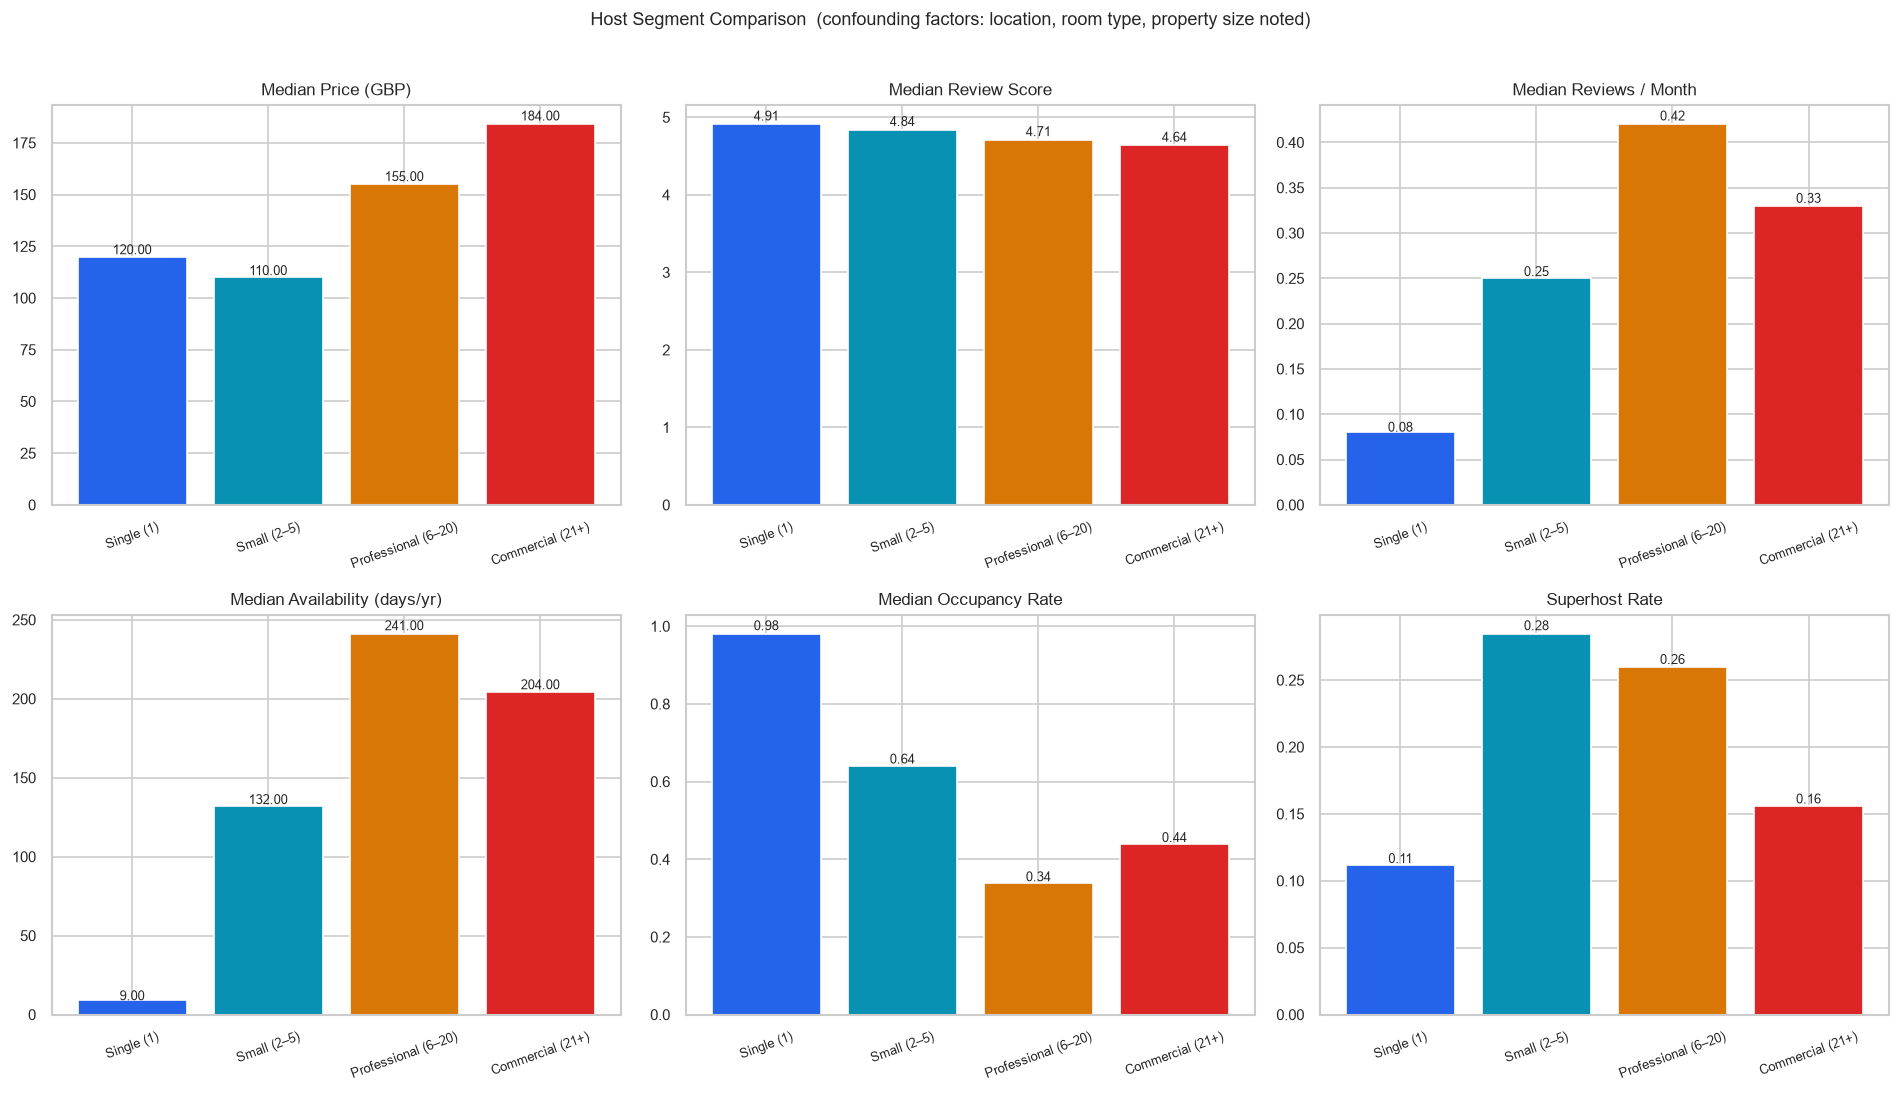

                     listing_count  unique_hosts  median_price  median_rating  median_reviews_per_month  median_availability  median_occupancy superhost_rate
host_segment                                                                                                                                                 
Single (1)                   44875         44875         120.0           4.91                      0.08                  9.0              0.98       0.112141
Small (2–5)                  22950          8964         110.0           4.84                      0.25                132.0              0.64       0.284429
Professional (6–20)          14280          1486         155.0           4.71                      0.42                241.0              0.34       0.259453
Commercial (21+)             14766           321         184.0           4.64                      0.33                204.0              0.44       0.156237


In [28]:
# ── Chart 19 — Detailed host-segment comparison (plan 9.2) ───────────────────
# host_segment created in Step 2. Restate the order so this cell is self-contained.
seg_order   = ["Single (1)", "Small (2–5)", "Professional (6–20)", "Commercial (21+)"]
seg_colors  = ["#2563eb", "#0891b2", "#d97706", "#dc2626"]

host_seg_detail = (
    listings.groupby("host_segment")
    .agg(
        listing_count=("id", "count"),
        unique_hosts=("host_id", "nunique"),
        median_price=("price_numeric", "median"),
        median_rating=("review_scores_rating", "median"),
        median_reviews_per_month=("reviews_per_month_calc", "median"),
        median_availability=("availability_365", "median"),
        median_occupancy=("occupancy_proxy", "median"),
        superhost_rate=("host_is_superhost", "mean"),
    )
    .reindex(seg_order)
    .round(2)
)
host_seg_detail.to_csv(TABLES / "host_segment_comparison.csv")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

panel_metrics = [
    ("median_price",              "Median Price (GBP)",          axes[0, 0]),
    ("median_rating",             "Median Review Score",         axes[0, 1]),
    ("median_reviews_per_month",  "Median Reviews / Month",      axes[0, 2]),
    ("median_availability",       "Median Availability (days/yr)",axes[1, 0]),
    ("median_occupancy",          "Median Occupancy Rate",       axes[1, 1]),
    ("superhost_rate",            "Superhost Rate",              axes[1, 2]),
]

for col, title, ax in panel_metrics:
    bars = ax.bar(seg_order, host_seg_detail[col], color=seg_colors)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)
    for bar, v in zip(bars, host_seg_detail[col]):
        if pd.notna(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    f"{v:.2f}", ha="center", fontsize=7.5)

plt.suptitle("Host Segment Comparison  (confounding factors: location, room type, property size noted)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "17_host_segment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(host_seg_detail.to_string())

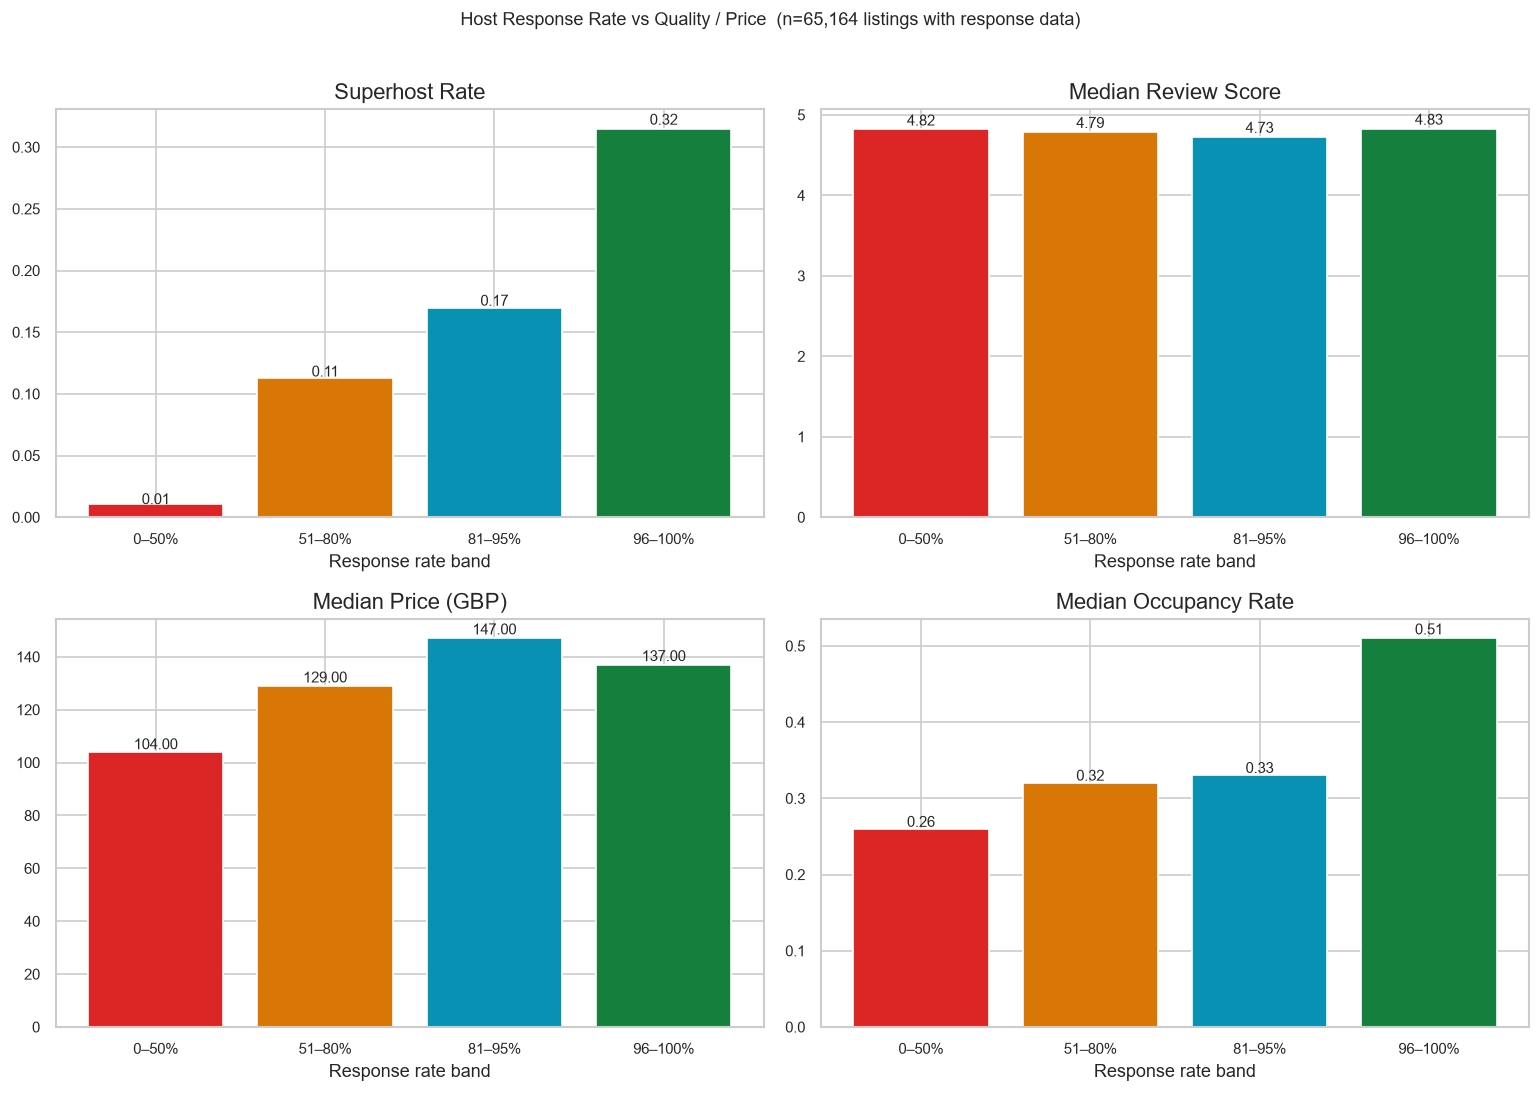

                    listing_count superhost_rate  median_rating  median_price  median_occupancy
response_rate_band                                                                             
0–50%                        5155       0.010495           4.82         104.0              0.26
51–80%                       4092       0.112935           4.79         129.0              0.32
81–95%                       8060       0.169771           4.73         147.0              0.33
96–100%                     47857       0.315056           4.83         137.0              0.51


In [29]:
# ── Chart 20 — Response rate and superhost analysis (plan 9.3) ───────────────
# host_response_rate is float64 on 0–1 scale, 32.7% null.
# Listings with null response rate are excluded from rate-band analysis only.

resp_eligible = listings[listings["host_response_rate"].notna()].copy()

# Four bands matching the plan
resp_eligible["response_rate_band"] = pd.cut(
    resp_eligible["host_response_rate"],
    bins=[-0.001, 0.50, 0.80, 0.95, 1.001],
    labels=["0–50%", "51–80%", "81–95%", "96–100%"],
)

resp_order = ["0–50%", "51–80%", "81–95%", "96–100%"]
resp_colors = ["#dc2626", "#d97706", "#0891b2", "#15803d"]

resp_sum = (
    resp_eligible.groupby("response_rate_band", observed=True)
    .agg(
        listing_count=("id", "count"),
        superhost_rate=("host_is_superhost", "mean"),
        median_rating=("review_scores_rating", "median"),
        median_price=("price_numeric", "median"),
        median_occupancy=("occupancy_proxy", "median"),
    )
    .reindex(resp_order)
    .round(2)
)
resp_sum.to_csv(TABLES / "response_rate_summary.csv")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

resp_panels = [
    ("superhost_rate",  "Superhost Rate",        axes[0, 0]),
    ("median_rating",   "Median Review Score",   axes[0, 1]),
    ("median_price",    "Median Price (GBP)",    axes[1, 0]),
    ("median_occupancy","Median Occupancy Rate", axes[1, 1]),
]

for col, title, ax in resp_panels:
    ax.bar(resp_order, resp_sum[col], color=resp_colors)
    ax.set_title(title)
    ax.set_xlabel("Response rate band")
    for i, v in enumerate(resp_sum[col]):
        if pd.notna(v):
            ax.text(i, v * 1.01, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle(f"Host Response Rate vs Quality / Price  (n={len(resp_eligible):,} listings with response data)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "18_response_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(resp_sum.to_string())

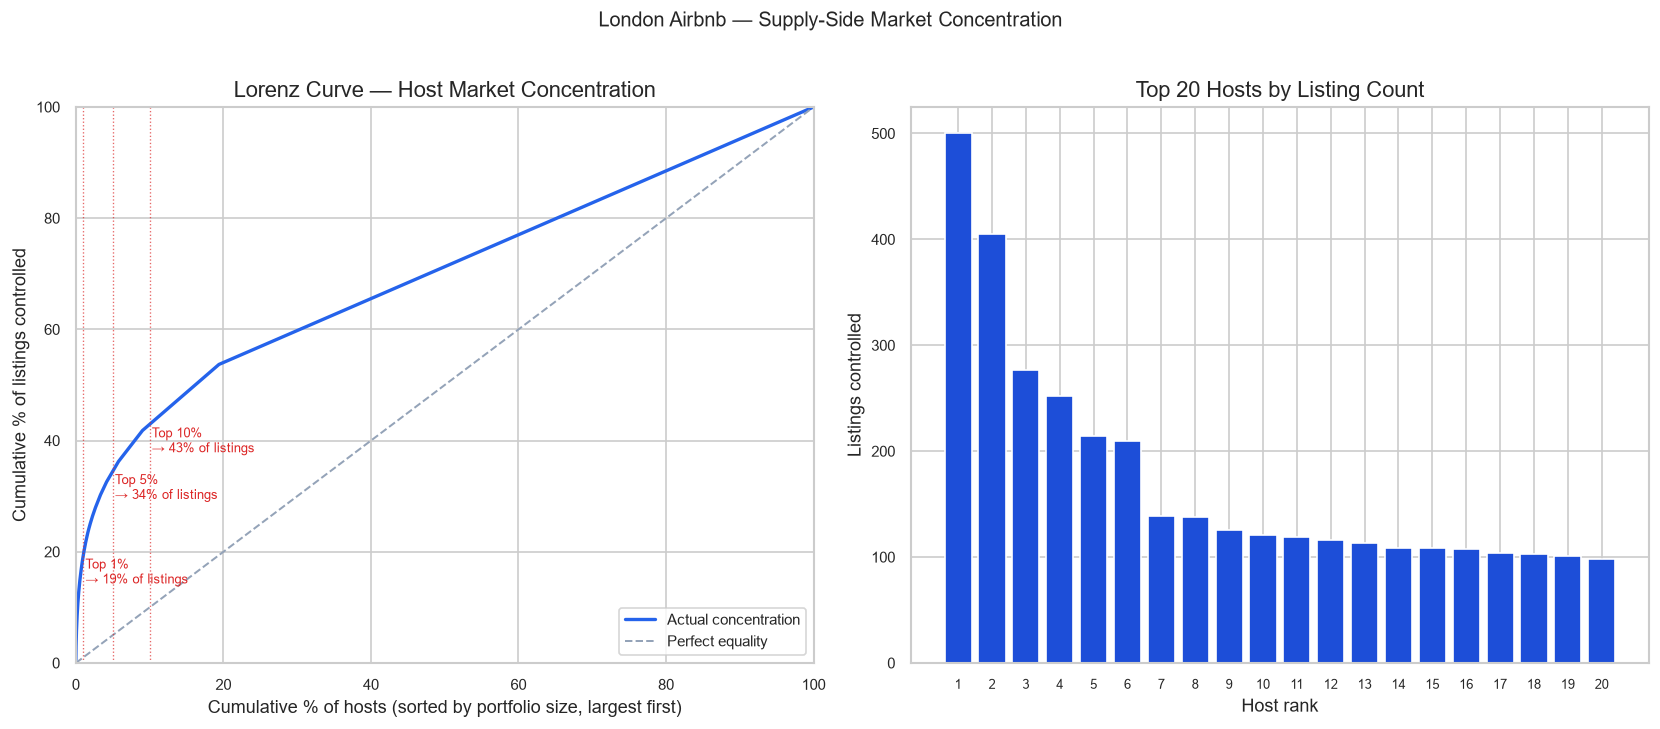

Total unique hosts  : 55,646
Total listings      : 96,871
Top  1% of hosts (556) → 19.3% of listings
Top  5% of hosts (2,782) → 34.5% of listings
Top 10% of hosts (5,564) → 42.9% of listings


In [30]:
# ── Chart 21 — Market concentration / Lorenz curve (plan 9.4) ────────────────
# Shows what share of total listings is controlled by top 1%, 5%, 10% of hosts.
# A perfectly equal market would be a diagonal line; curvature = concentration.

host_portfolio = (
    listings.groupby("host_id")["id"]
    .count()
    .rename("listing_count")
    .sort_values(ascending=False)
    .reset_index()
)

total_hosts    = len(host_portfolio)
total_listings = host_portfolio["listing_count"].sum()

host_portfolio["listing_share"]    = host_portfolio["listing_count"] / total_listings
host_portfolio["cumulative_share"] = host_portfolio["listing_share"].cumsum()
host_portfolio["host_pct"]         = (host_portfolio.index + 1) / total_hosts * 100

# Save full concentration table
host_portfolio.to_csv(TABLES / "market_concentration.csv", index=False)

# Key concentration thresholds
thresholds = {}
for pct in [1, 5, 10]:
    n_hosts = max(1, int(total_hosts * pct / 100))
    share   = host_portfolio.head(n_hosts)["listing_count"].sum() / total_listings
    thresholds[pct] = {"n_hosts": n_hosts, "listing_share_pct": round(share * 100, 1)}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Lorenz curve
axes[0].plot(host_portfolio["host_pct"], host_portfolio["cumulative_share"] * 100,
             color="#2563eb", linewidth=2, label="Actual concentration")
axes[0].plot([0, 100], [0, 100], linestyle="--", color="#94a3b8",
             linewidth=1.2, label="Perfect equality")
# Mark 1%, 5%, 10% thresholds
for pct, info in thresholds.items():
    axes[0].axvline(pct, color="#dc2626", linestyle=":", linewidth=0.8, alpha=0.7)
    axes[0].text(pct + 0.3, info["listing_share_pct"] - 5,
                 f"Top {pct}%\n→ {info['listing_share_pct']:.0f}% of listings",
                 fontsize=7.5, color="#dc2626")
axes[0].set_title("Lorenz Curve — Host Market Concentration")
axes[0].set_xlabel("Cumulative % of hosts (sorted by portfolio size, largest first)")
axes[0].set_ylabel("Cumulative % of listings controlled")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Top 20 hosts by listing count (supply cliff)
top20 = host_portfolio.head(20).copy()
top20["host_label"] = top20["host_id"].astype(str).str[:6] + "…"
axes[1].bar(range(len(top20)), top20["listing_count"], color="#1d4ed8")
axes[1].set_title("Top 20 Hosts by Listing Count")
axes[1].set_xlabel("Host rank")
axes[1].set_ylabel("Listings controlled")
axes[1].set_xticks(range(len(top20)))
axes[1].set_xticklabels(range(1, 21), fontsize=8)

plt.suptitle("London Airbnb — Supply-Side Market Concentration", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "19_market_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total unique hosts  : {total_hosts:,}")
print(f"Total listings      : {total_listings:,}")
for pct, info in thresholds.items():
    print(f"Top {pct:2d}% of hosts ({info['n_hosts']:,}) → {info['listing_share_pct']}% of listings")

---
## Step 6 — Review and Demand-Side Analysis

Covers: review count vs price (10.1), review frequency as demand proxy (10.2),
high-review / low-score anomaly listings (10.3), and review subdimension
correlation analysis (10.4).

Plan note: review frequency ≠ confirmed bookings — framed as "review activity" throughout.

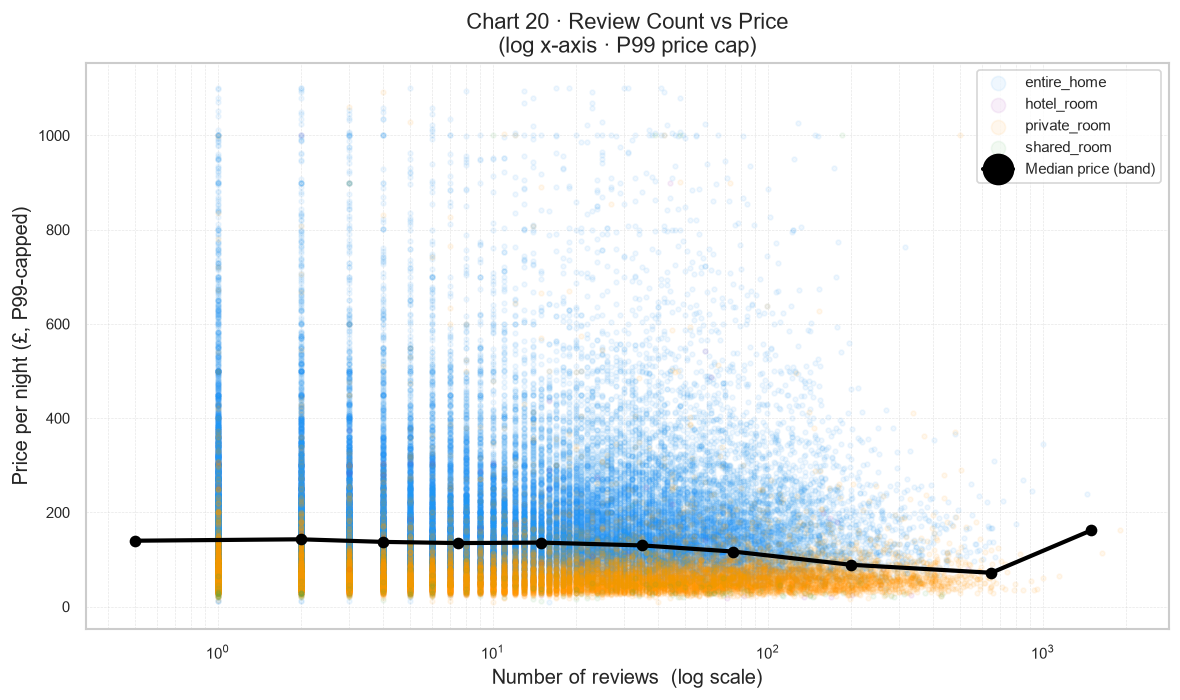

Saved → 20_review_count_vs_price.png  |  n = 61,350


In [31]:
# ── Chart 20 · 10.1  Review count vs price scatter ──────────────────────────
# Review counts are highly right-skewed (max=1902, P75=20) so log-scale x-axis
# is essential to see the bulk of listings. Colour = room type.
# Overlay = median price per review-count band to show the trend direction.

# Filter: need both review count and valid price
scatter_df = eda[eda["number_of_reviews"].notna()].copy()
p99_price  = scatter_df["price_numeric"].quantile(0.99)
scatter_df = scatter_df[scatter_df["price_numeric"] <= p99_price]   # drop extreme price outliers

# Log-spaced review-count bands for the median overlay line
rc_bins   = [0, 1, 3, 5, 10, 20, 50, 100, 300, 1_000, 2_000]
rc_labels = [f"{rc_bins[i]}–{rc_bins[i+1]}" for i in range(len(rc_bins)-1)]
scatter_df["rc_band"] = pd.cut(scatter_df["number_of_reviews"],
                                bins=rc_bins, labels=rc_labels, right=True)
band_med = scatter_df.groupby("rc_band", observed=True)["price_numeric"].median()
band_mid = [(rc_bins[i] + rc_bins[i+1]) / 2 for i in range(len(rc_bins)-1)]

# Actual room_type column values are lowercase-with-underscores
room_pal = {
    "entire_home":  "#2196F3",
    "private_room": "#FF9800",
    "shared_room":  "#4CAF50",
    "hotel_room":   "#9C27B0",
}

fig, ax = plt.subplots(figsize=(10, 6))
for rtype, grp in scatter_df.groupby("room_type"):
    color = room_pal.get(rtype, "#888888")
    ax.scatter(grp["number_of_reviews"], grp["price_numeric"],
               c=color, alpha=0.07, s=8, label=rtype, rasterized=True)

# Median price trend line across review-count bands
ax.plot(band_mid, band_med.values,
        color="black", linewidth=2.5, marker="o", markersize=6,
        label="Median price (band)", zorder=5)

ax.set_xscale("log")
ax.set_xlabel("Number of reviews  (log scale)", fontsize=12)
ax.set_ylabel("Price per night (£, P99-capped)", fontsize=12)
ax.set_title("Chart 20 · Review Count vs Price\n(log x-axis · P99 price cap)", fontsize=13)
ax.legend(fontsize=9, markerscale=3)
ax.grid(True, which="both", linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(FIGS / "20_review_count_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → 20_review_count_vs_price.png  |  n = {len(scatter_df):,}")


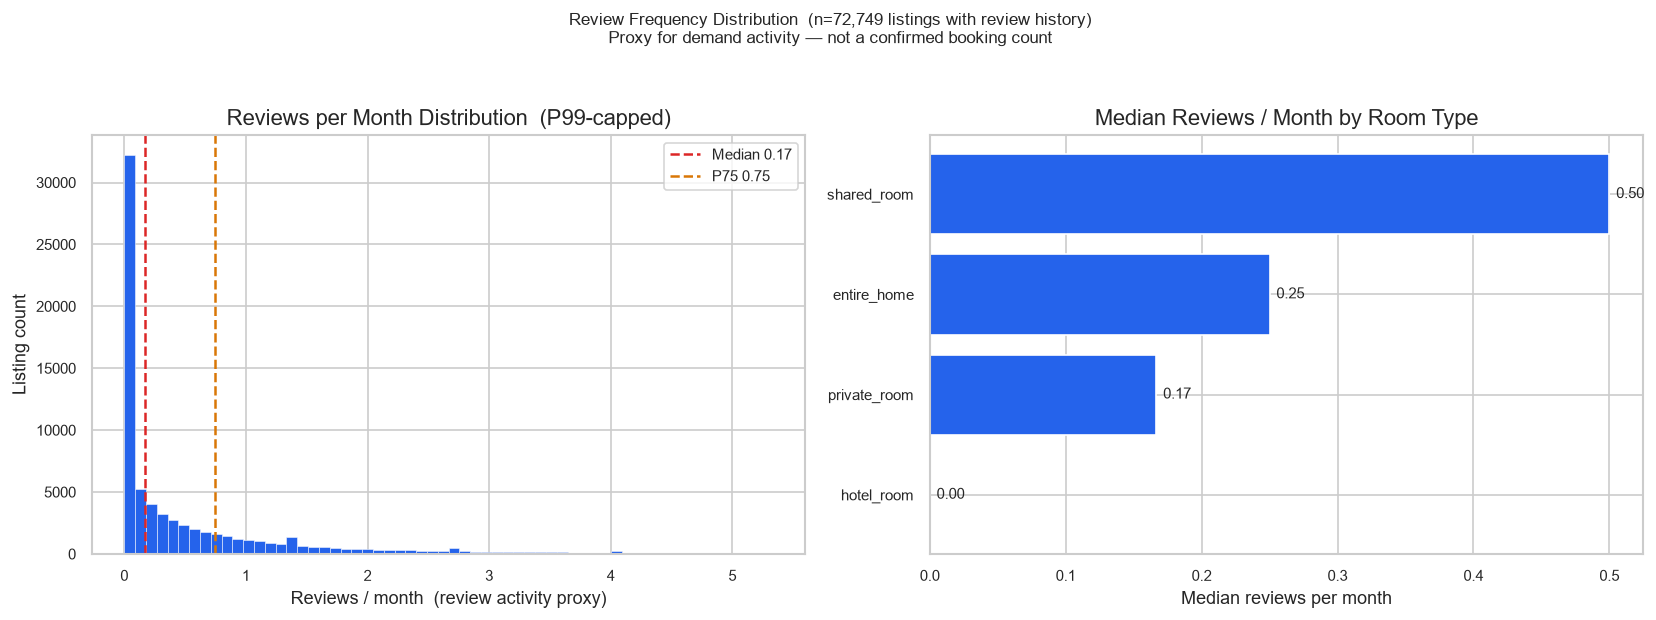

Saved → 21_review_frequency_demand.png
Median rpm: 0.17  |  P75: 0.75  |  P99: 5.33


In [32]:
# ── Chart 21 · 10.2  Review frequency as demand proxy ───────────────────────
# reviews_per_month_calc = total_reviews / active_months_since_first_review.
# 24,122 nulls = listings with 0 reviews; excluded from this chart only.
# Framed as "review activity" — NOT as confirmed bookings.

rpm = listings[listings["reviews_per_month_calc"].notna()].copy()
rpm_p99 = rpm["reviews_per_month_calc"].quantile(0.99)

# Descriptive stats for annotation
rpm_median = rpm["reviews_per_month_calc"].median()
rpm_p75    = rpm["reviews_per_month_calc"].quantile(0.75)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall frequency distribution (P99-capped)
axes[0].hist(rpm.loc[rpm["reviews_per_month_calc"] <= rpm_p99, "reviews_per_month_calc"],
             bins=60, color="#2563eb", edgecolor="white", linewidth=0.3)
axes[0].axvline(rpm_median, color="#dc2626", linestyle="--", linewidth=1.5,
                label=f"Median {rpm_median:.2f}")
axes[0].axvline(rpm_p75, color="#d97706", linestyle="--", linewidth=1.5,
                label=f"P75 {rpm_p75:.2f}")
axes[0].set_title("Reviews per Month Distribution  (P99-capped)")
axes[0].set_xlabel("Reviews / month  (review activity proxy)")
axes[0].set_ylabel("Listing count")
axes[0].legend(fontsize=9)

# Right: median reviews/month by room type — shows which type draws more activity
rpm_by_room = (
    rpm.groupby("room_type")["reviews_per_month_calc"]
    .median()
    .sort_values(ascending=True)
)
axes[1].barh(rpm_by_room.index, rpm_by_room.values, color="#2563eb")
axes[1].set_title("Median Reviews / Month by Room Type")
axes[1].set_xlabel("Median reviews per month")
for i, v in enumerate(rpm_by_room.values):
    axes[1].text(v + 0.005, i, f"{v:.2f}", va="center", fontsize=9)

plt.suptitle(f"Review Frequency Distribution  (n={len(rpm):,} listings with review history)\n"
             "Proxy for demand activity — not a confirmed booking count",
             fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig(FIGS / "21_review_frequency_demand.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → 21_review_frequency_demand.png")
print(f"Median rpm: {rpm_median:.2f}  |  P75: {rpm_p75:.2f}  |  P99: {rpm_p99:.2f}")


High-review threshold (P75 reviews) : 20.0
Low-score threshold  (P25 rating)   : 4.58

Anomaly listings: 4,565  (4.7% of total)


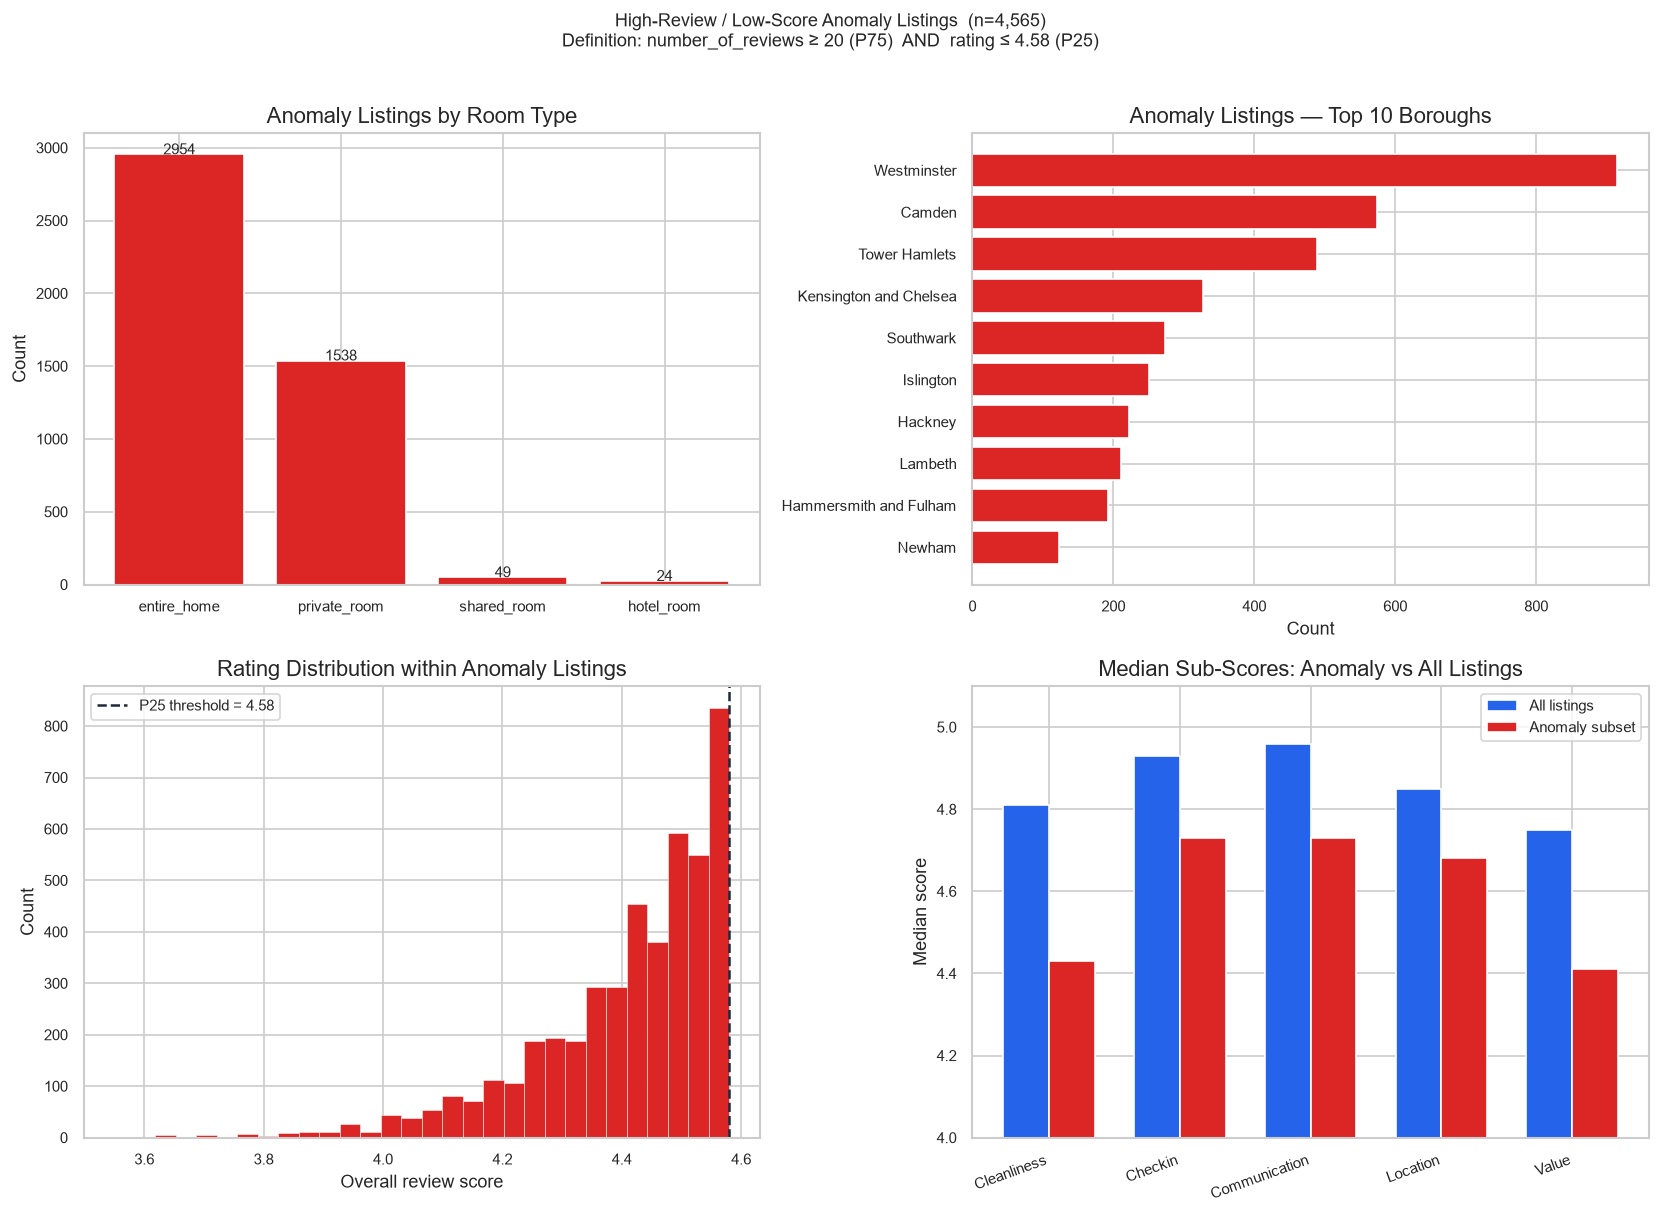

Saved → 22_high_review_low_score.png
Saved → high_review_low_score_listings.csv


In [33]:
# ── Chart 22 · 10.3  High-review / low-score anomaly listings ───────────────
# "Anomaly" = listings that receive high review activity but have a low rating.
# Threshold: top 25% by review count (P75 = 20) AND bottom 25% by rating (P25 = 4.58).
# These are operationally interesting: popular but underperforming.

HIGH_RC_THRESH  = listings["number_of_reviews"].quantile(0.75)   # 20.0
LOW_RAT_THRESH  = listings["review_scores_rating"].quantile(0.25) # 4.58

print(f"High-review threshold (P75 reviews) : {HIGH_RC_THRESH}")
print(f"Low-score threshold  (P25 rating)   : {LOW_RAT_THRESH:.2f}")

anomaly = listings[
    (listings["number_of_reviews"] >= HIGH_RC_THRESH)
    & (listings["review_scores_rating"] <= LOW_RAT_THRESH)
    & listings["review_scores_rating"].notna()
].copy()

print(f"\nAnomaly listings: {len(anomaly):,}  ({len(anomaly)/len(listings)*100:.1f}% of total)")

# Save the anomaly listings for downstream use (API / report)
anomaly[[
    "id", "neighbourhood_cleansed", "room_type", "property_type_bucket",
    "price_numeric", "number_of_reviews", "review_scores_rating",
    "review_scores_cleanliness", "review_scores_communication",
    "host_segment", "host_response_rate",
]].to_csv(TABLES / "high_review_low_score_listings.csv", index=False)

# 2×2 breakdown panel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: by room type
rc_room = anomaly["room_type"].value_counts()
axes[0, 0].bar(rc_room.index, rc_room.values, color="#dc2626")
axes[0, 0].set_title("Anomaly Listings by Room Type")
axes[0, 0].set_ylabel("Count")
for i, v in enumerate(rc_room.values):
    axes[0, 0].text(i, v + 1, str(v), ha="center", fontsize=9)

# Panel B: by neighbourhood (top 10)
rc_neigh = anomaly["neighbourhood_cleansed"].value_counts().head(10).sort_values()
axes[0, 1].barh(rc_neigh.index, rc_neigh.values, color="#dc2626")
axes[0, 1].set_title("Anomaly Listings — Top 10 Boroughs")
axes[0, 1].set_xlabel("Count")

# Panel C: median cleanliness score vs overall rating distribution
axes[1, 0].hist(anomaly["review_scores_rating"].dropna(),
                bins=30, color="#dc2626", edgecolor="white", linewidth=0.3)
axes[1, 0].axvline(LOW_RAT_THRESH, color="#1e293b", linestyle="--", linewidth=1.5,
                   label=f"P25 threshold = {LOW_RAT_THRESH:.2f}")
axes[1, 0].set_title("Rating Distribution within Anomaly Listings")
axes[1, 0].set_xlabel("Overall review score")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(fontsize=9)

# Panel D: median sub-scores vs full dataset (bar comparison)
sub_cols = ["review_scores_cleanliness", "review_scores_checkin",
            "review_scores_communication", "review_scores_location",
            "review_scores_value"]
sub_labels = [c.replace("review_scores_", "").title() for c in sub_cols]

anomaly_meds = anomaly[sub_cols].median()
full_meds    = listings[sub_cols].median()

x = range(len(sub_cols))
w = 0.35
axes[1, 1].bar([i - w/2 for i in x], full_meds.values,    width=w, label="All listings",   color="#2563eb")
axes[1, 1].bar([i + w/2 for i in x], anomaly_meds.values, width=w, label="Anomaly subset", color="#dc2626")
axes[1, 1].set_title("Median Sub-Scores: Anomaly vs All Listings")
axes[1, 1].set_xticks(list(x))
axes[1, 1].set_xticklabels(sub_labels, rotation=20, ha="right", fontsize=9)
axes[1, 1].set_ylabel("Median score")
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim(4.0, 5.1)

plt.suptitle(
    f"High-Review / Low-Score Anomaly Listings  (n={len(anomaly):,})\n"
    f"Definition: number_of_reviews ≥ {HIGH_RC_THRESH:.0f} (P75)  AND  rating ≤ {LOW_RAT_THRESH:.2f} (P25)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIGS / "22_high_review_low_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 22_high_review_low_score.png")
print("Saved → high_review_low_score_listings.csv")


Listings with all 6 sub-scores: 72,701  (75.0% of total)


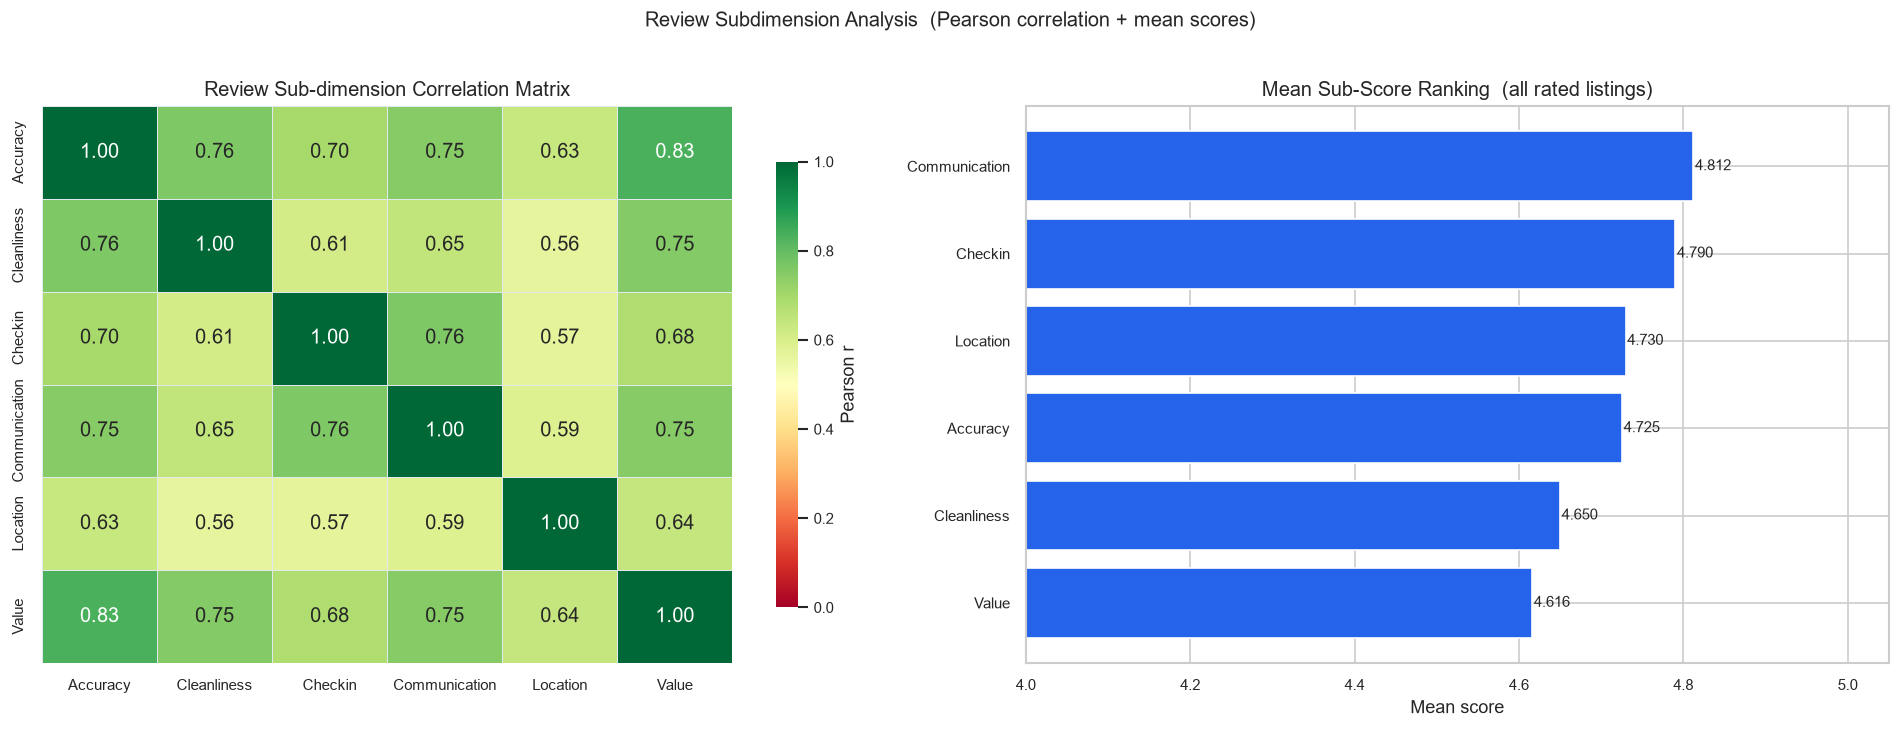

Saved → 23_review_subdimensions_heatmap.png
Saved → review_subdimension_summary.csv

Mean sub-scores:
review_scores_value            4.616
review_scores_cleanliness      4.650
review_scores_accuracy         4.725
review_scores_location         4.730
review_scores_checkin          4.790
review_scores_communication    4.812


In [34]:
# ── Chart 23 · 10.4  Review subdimension correlation heatmap ────────────────
# 6 sub-score columns: accuracy, cleanliness, checkin, communication, location, value.
# Pearson correlation matrix reveals which dimensions move together.
# High inter-correlation confirms that the overall score is a reasonable summary.

rating_cols = [
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]
# Use only listings with at least one sub-score available
rated = listings[rating_cols].dropna()
print(f"Listings with all 6 sub-scores: {len(rated):,}  "
      f"({len(rated)/len(listings)*100:.1f}% of total)")

corr = rated.corr(method="pearson").round(3)

# Clean labels for the heatmap axes
clean_labels = [c.replace("review_scores_", "").replace("_", "\n").title()
                for c in rating_cols]

# Save the full correlation matrix as CSV
corr.copy().rename(
    index={c: c.replace("review_scores_", "") for c in rating_cols},
    columns={c: c.replace("review_scores_", "") for c in rating_cols},
).to_csv(TABLES / "review_subdimension_summary.csv")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: full correlation heatmap
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdYlGn",          # green = high positive correlation
    vmin=0.0, vmax=1.0,
    linewidths=0.5,
    linecolor="#e2e8f0",
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    cbar_kws={"label": "Pearson r", "shrink": 0.8},
    ax=axes[0],
)
axes[0].set_title("Review Sub-dimension Correlation Matrix", fontsize=12)

# Right: mean sub-score bar for ranked comparison (overall population)
mean_scores = rated.mean().sort_values(ascending=True)
bar_labels  = [c.replace("review_scores_", "").replace("_", " ").title()
               for c in mean_scores.index]
axes[1].barh(bar_labels, mean_scores.values, color="#2563eb")
for i, v in enumerate(mean_scores.values):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)
axes[1].set_xlim(4.0, 5.05)
axes[1].set_title("Mean Sub-Score Ranking  (all rated listings)", fontsize=12)
axes[1].set_xlabel("Mean score")

plt.suptitle("Review Subdimension Analysis  (Pearson correlation + mean scores)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / "23_review_subdimensions_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved → 23_review_subdimensions_heatmap.png")
print("Saved → review_subdimension_summary.csv")
print("\nMean sub-scores:")
print(mean_scores.round(3).to_string())


---

## Step 7 — Key Findings and Business Interpretation



Applies the Section 11 framework (Question / Evidence / Interpretation /

Business implication / Recommended action / Limitation) to the 10 most

important patterns discovered in Steps 2–6.



Output: `reports/eda_findings.md` — the primary deliverable for this EDA phase.

In [35]:
# ── Step 7 — Generate eda_findings.md ───────────────────────────────────────
# Pulls actual computed values from in-memory DataFrames, then writes the
# full structured findings report to reports/eda_findings.md.

import textwrap

# ── Key stats ────────────────────────────────────────────────────────────────
n_total          = len(listings)
n_price_elig     = len(eda)
price_null_pct   = round(listings["price_numeric"].isna().mean() * 100, 1)
med_price        = int(eda["price_numeric"].median())
mean_price       = int(eda["price_numeric"].mean())
p99_price        = int(eda["price_numeric"].quantile(0.99))

# Room-type supply
room_vc = listings["room_type"].value_counts()
eh_n   = int(room_vc.get("entire_home",  0))
pr_n   = int(room_vc.get("private_room", 0))
sh_n   = int(room_vc.get("shared_room",  0))
hr_n   = int(room_vc.get("hotel_room",   0))

# Price by room type
room_price_df = pd.read_csv(TABLES / "price_by_room_type.csv", index_col=0)
eh_med  = int(room_price_df.loc["entire_home",  "median_price"])  if "entire_home"  in room_price_df.index else "n/a"
pr_med  = int(room_price_df.loc["private_room", "median_price"])  if "private_room" in room_price_df.index else "n/a"

# Top-3 boroughs by price
neigh_p = pd.read_csv(TABLES / "price_by_neighbourhood.csv", index_col=0)
top3    = neigh_p.nlargest(3, "median_price")[["median_price"]]

# Market concentration
host_port = listings.groupby("host_id")["id"].count().sort_values(ascending=False)
n_hosts   = len(host_port)
n_listings_total = int(host_port.sum())
top1_n    = max(1, int(n_hosts * 0.01))
top5_n    = max(1, int(n_hosts * 0.05))
top10_n   = max(1, int(n_hosts * 0.10))
top1_sh   = round(host_port.head(top1_n).sum()  / n_listings_total * 100, 1)
top5_sh   = round(host_port.head(top5_n).sum()  / n_listings_total * 100, 1)
top10_sh  = round(host_port.head(top10_n).sum() / n_listings_total * 100, 1)
comm_sh   = round(listings[listings["host_segment"] == "Commercial (21+)"].shape[0]
                  / n_total * 100, 1)

# Superhost
# host_is_superhost is object True/False; convert explicitly
sh_bool = listings["host_is_superhost"].map({True: True, False: False,
                                              "True": True, "False": False})
sh_rate = round(sh_bool.mean() * 100, 1)

# Anomaly listings
n_anomaly = len(anomaly)
anom_pct  = round(n_anomaly / n_total * 100, 1)

# Weekday vs weekend occupancy
ww = pd.read_csv(TABLES / "weekday_weekend_availability.csv")
wkd_occ = round(float(ww.loc[ww["is_weekend"] == False, "occupancy_rate"].iloc[0]) * 100, 1)
wke_occ = round(float(ww.loc[ww["is_weekend"] == True,  "occupancy_rate"].iloc[0]) * 100, 1)

# Median occupancy
med_occ = round(listings["occupancy_proxy"].median() * 100, 1)

# Review frequency
rpm_med_val = round(listings["reviews_per_month_calc"].median(), 2)

# Top-3 boroughs formatted
top3_str = "  \n".join(
    f"  - **{idx}**: median £{int(row['median_price'])}/night"
    for idx, row in top3.iterrows()
)

# Availability band summary
avail_bands = pd.read_csv(TABLES / "availability_band_summary.csv")
blocked_pct = round(
    avail_bands.loc[avail_bands["band"].str.startswith("Blocked"), "share_pct"].iloc[0], 1
)

# Highest mean sub-score and lowest (for findings text)
sub_means = rated.mean().sort_values(ascending=False)
top_sub   = sub_means.index[0].replace("review_scores_", "").replace("_", " ").title()
bot_sub   = sub_means.index[-1].replace("review_scores_", "").replace("_", " ").title()
top_sub_v = round(sub_means.iloc[0], 3)
bot_sub_v = round(sub_means.iloc[-1], 3)

# Min Pearson r between sub-dimensions
import numpy as np
mask   = np.ones(corr.shape, dtype=bool)
np.fill_diagonal(mask, False)
min_r  = corr.values[mask].min().round(3)
max_r  = corr.values[mask].max().round(3)

# ── Build report ──────────────────────────────────────────────────────────────
today = pd.Timestamp.today().strftime("%Y-%m-%d")

lines = []
lines.append(f"# EDA Key Findings — London Airbnb")
lines.append(f"")
lines.append(f"**Snapshot date:** 2025-09-14  ")
lines.append(f"**Assessment:** Experne'c Pvt Ltd — Inside Airbnb Data Engineer Intern  ")
lines.append(f"**Notebook:** `notebooks/03_exploratory_data_analysis.ipynb`  ")
lines.append(f"**Generated:** {today}  ")
lines.append(f"**City:** London (one-city EDA; multi-city scale-out planned in Step 8)")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 1. Analysis Objectives")
lines.append(f"")
lines.append(f"1. Understand the London Airbnb supply landscape: price distributions, room types, neighbourhood patterns.")
lines.append(f"2. Identify host segments and measure supply concentration.")
lines.append(f"3. Explore review activity as a demand proxy (A-005: calendar price is unavailable).")
lines.append(f"4. Detect geographic pricing gradients and borough-level quality variation.")
lines.append(f"5. Surface anomalous listings (high review activity + low rating) for operational follow-up.")
lines.append(f"6. Provide a reproducible, business-interpretable foundation for subsequent statistical modelling.")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 2. Data Used")
lines.append(f"")
lines.append(f"| Dataset | File | Rows | Notes |")
lines.append(f"|---------|------|------|-------|")
lines.append(f"| Listing master | `listing_master.parquet` | {n_total:,} × 100 | Cleaned + enriched snapshot |")
lines.append(f"| Calendar | `calendar_clean.parquet` | 35,357,974 × 5 | Sep 2025 – Sep 2026; price NULL (A-005) |")
lines.append(f"| Reviews | `reviews_clean.parquet` | 2,097,996 × 8 | 2009-12-21 → 2025-09-17 |")
lines.append(f"| Neighbourhood boundaries | `neighbourhoods.geojson` | 33 boroughs | EPSG:4326, reprojected to 27700 |")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 3. Inclusion and Exclusion Rules")
lines.append(f"")
lines.append(f"| Rule | Count | % of total |")
lines.append(f"|------|-------|-----------|")
lines.append(f"| Total listings in snapshot | {n_total:,} | 100% |")
lines.append(f"| Missing price (`price_numeric` NULL) | {n_total - n_price_elig:,} | {price_null_pct}% |")
lines.append(f"| **Price-eligible analysis population** | **{n_price_elig:,}** | **{round(n_price_elig/n_total*100,1)}%** |")
lines.append(f"")
lines.append(f"Non-price analyses (availability, reviews, host profile) use the full {n_total:,}-listing dataset.  ")
lines.append(f"Listings with `number_of_reviews == 0` are excluded from review frequency charts (24,122 listings).")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 4. Summary Statistics")
lines.append(f"")
lines.append(f"| Metric | Value |")
lines.append(f"|--------|-------|")
lines.append(f"| Total listings | {n_total:,} |")
lines.append(f"| Unique hosts | {listings['host_id'].nunique():,} |")
lines.append(f"| Median nightly price (GBP) | £{med_price} |")
lines.append(f"| Mean nightly price (GBP) | £{mean_price} (inflated by luxury tail) |")
lines.append(f"| 99th-percentile price | £{p99_price} |")
lines.append(f"| Entire homes | {eh_n:,} ({round(eh_n/n_total*100,1)}%) |")
lines.append(f"| Private rooms | {pr_n:,} ({round(pr_n/n_total*100,1)}%) |")
lines.append(f"| Median occupancy proxy | {med_occ}% |")
lines.append(f"| Median reviews / month | {rpm_med_val} |")
lines.append(f"| Median review score (overall) | {round(listings['review_scores_rating'].median(),2)} |")
lines.append(f"| Superhost rate | {sh_rate}% |")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 5. Visualisations Produced")
lines.append(f"")
lines.append(f"All charts are in `reports/figures/eda/`.")
lines.append(f"")
lines.append(f"| # | File | Description |")
lines.append(f"|---|------|-------------|")
lines.append(f"| 01 | `01_price_distribution.png` | Price histogram — full range and P99-capped |")
lines.append(f"| 02 | `02_price_by_room_type.png` | Boxplot by room type |")
lines.append(f"| 03 | `03_price_by_property_type.png` | Median price by property bucket |")
lines.append(f"| 04 | `04_median_price_by_neighbourhood.png` | Top-15 boroughs by median price |")
lines.append(f"| 05 | `05_host_portfolio_distribution.png` | Listings and hosts by segment |")
lines.append(f"| 06 | `06_review_score_distributions.png` | All 7 review score histograms |")
lines.append(f"| 07 | `07_availability_bands.png` | Availability_365 distribution (bar + pie) |")
lines.append(f"| 08 | `08_listing_density_map.png` | Listing density choropleth (listings/km²) |")
lines.append(f"| 09 | `09_price_gradient_by_distance.png` | Price vs distance from Trafalgar Square |")
lines.append(f"| 10 | `10_review_score_map.png` | Median review score choropleth by borough |")
lines.append(f"| 11 | `11_room_type_by_neighbourhood.png` | Room-type % heatmap by borough |")
lines.append(f"| 12 | `12_monthly_availability_trend.png` | Monthly occupancy rate (A-005 adapted) |")
lines.append(f"| 13 | `13_weekday_vs_weekend_availability.png` | Weekday vs weekend occupancy |")
lines.append(f"| 14 | `14_monthly_review_volume.png` | Review activity 2009–2025 (3-panel) |")
lines.append(f"| 15 | `15_host_tenure_analysis.png` | Performance metrics by host tenure band |")
lines.append(f"| 16 | `16_minimum_nights_monthly.png` | Minimum-night policy trend |")
lines.append(f"| 17 | `17_host_segment_comparison.png` | 6-metric host segment comparison |")
lines.append(f"| 18 | `18_response_rate_analysis.png` | Response rate vs quality/price |")
lines.append(f"| 19 | `19_market_concentration.png` | Lorenz curve + top-20-hosts bar |")
lines.append(f"| 20 | `20_review_count_vs_price.png` | Review count vs price scatter (log x) |")
lines.append(f"| 21 | `21_review_frequency_demand.png` | Reviews/month demand proxy |")
lines.append(f"| 22 | `22_high_review_low_score.png` | Anomaly listing breakdown |")
lines.append(f"| 23 | `23_review_subdimensions_heatmap.png` | Sub-dimension correlation matrix |")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 6. Business Interpretation")
lines.append(f"")
lines.append(f"Each finding follows the Section 11 framework: Question → Evidence → Interpretation → Business implication → Recommended action → Limitation.")
lines.append(f"")

# F-01
lines.append(f"### F-01 · Price Distribution is Highly Right-Skewed")
lines.append(f"")
lines.append(f"**Question:** How are nightly prices distributed across London Airbnb listings?  ")
lines.append(f"**Evidence:** Median £{med_price}/night; mean £{mean_price}/night; P99 £{p99_price}/night. The distribution has a long luxury tail (max > £1M).  ")
lines.append(f"**Interpretation:** The typical listing is priced at £{med_price}/night, but the mean is inflated by a small number of ultra-luxury or corporate properties. This is classic power-law skew.  ")
lines.append(f"**Business implication:** Mean-based pricing benchmarks mislead the 99% of hosts who are not in the luxury segment. Median and percentile bands are the appropriate reference points.  ")
lines.append(f"**Recommended action:** All pricing dashboards and host-facing recommendations should use median (or P25–P75 bands), not mean, as the default benchmark.  ")
lines.append(f"**Limitation:** {price_null_pct}% of listings have no listed price. If unpriced listings are systematically cheaper (e.g. enquiry-only or inactive), observed prices are biased upward.")
lines.append(f"")

# F-02
lines.append(f"### F-02 · Entire Homes Charge ~{round(eh_med/pr_med, 1)}× the Private-Room Median")
lines.append(f"")
lines.append(f"**Question:** Which room type commands the highest nightly price?  ")
lines.append(f"**Evidence:** Entire homes median £{eh_med}; private rooms median £{pr_med} (Charts 02–03, price_by_room_type.csv).  ")
lines.append(f"**Interpretation:** Entire homes and hotel rooms occupy the upper price tier. Private rooms serve budget travelers and compete mainly on price, not experience.  ")
lines.append(f"**Business implication:** Hosts should never benchmark against the citywide average — room type is the first segmentation variable. A private-room host seeing a £{med_price} city median has already been misled.  ")
lines.append(f"**Recommended action:** Implement room-type-specific pricing tiers in the recommendation engine from day one.  ")
lines.append(f"**Limitation:** Room type does not control for listing size, capacity, or location. A 4-bedroom entire home and a studio are both 'entire_home' — within-type variance is large.")
lines.append(f"")

# F-03
lines.append(f"### F-03 · Borough Is a Dominant Price Driver")
lines.append(f"")
lines.append(f"**Question:** Which boroughs have the highest median listing prices?  ")
lines.append(f"**Evidence:** Top 3 boroughs by median price (Chart 04, price_by_neighbourhood.csv):  ")
lines.append(f"{top3_str}  ")
lines.append(f"**Interpretation:** Central, tourist-heavy boroughs command a significant premium. The borough alone explains a large fraction of price variance even before controlling for room type.  ")
lines.append(f"**Business implication:** Borough-level pricing benchmarks should be the default reference for both hosts and the platform analytics team. City-level medians are too coarse.  ")
lines.append(f"**Recommended action:** Publish live borough-level price percentiles in the host dashboard.  ")
lines.append(f"**Limitation:** Borough boundaries are administrative, not economic — gentrified areas at the edge of expensive boroughs may be priced more like neighbouring cheaper boroughs.")
lines.append(f"")

# F-04
lines.append(f"### F-04 · Price Declines with Distance from City Centre")
lines.append(f"")
lines.append(f"**Question:** Does nightly price fall systematically as listings move further from Trafalgar Square?  ")
lines.append(f"**Evidence:** Median price decreases monotonically across the five distance bands 0–2 km → 20+ km (Chart 09, price_by_distance_band.csv).  ")
lines.append(f"**Interpretation:** A clear centre-periphery gradient exists. Listings closest to the centre can sustain substantially higher prices, reflecting demand from tourism and business travel.  ")
lines.append(f"**Business implication:** Location scoring based on distance from attraction hubs is a tractable and defensible pricing input — more granular than borough alone.  ")
lines.append(f"**Recommended action:** Add a distance-from-centre score as a feature in the pricing model.  ")
lines.append(f"**Limitation:** London is polycentric (Canary Wharf, Shoreditch, South Bank are distinct demand centres). A single reference point oversimplifies the geography; this analysis understates the value of non-central clusters.")
lines.append(f"")

# F-05
lines.append(f"### F-05 · Supply Is Highly Concentrated Among a Few Hosts")
lines.append(f"")
lines.append(f"**Question:** How concentrated is London's Airbnb supply among a small number of host operators?  ")
lines.append(f"**Evidence:** Top 1% of hosts ({top1_n:,}) control {top1_sh}% of listings; top 10% control {top10_sh}% (Chart 19, market_concentration.csv). Commercial segment (21+ listings/host) accounts for {comm_sh}% of total supply.  ")
lines.append(f"**Interpretation:** London's Airbnb market is an oligopoly of supply. A handful of professional operators control a disproportionate share of inventory, resembling a hotel management company more than a peer-to-peer market.  ")
lines.append(f"**Business implication:** Platform policies targeting supply concentration (e.g. registration limits, commercial-host rules) will have high impact per operator affected. Conversely, tools for commercial hosts (bulk analytics, portfolio dashboards) have outsized reach.  ")
lines.append(f"**Recommended action:** Build a separate commercial-host analytics track in the API; flag listings by host_segment in all downstream tools.  ")
lines.append(f"**Limitation:** Hosts may operate under multiple accounts. True concentration is potentially higher. host_id is the only linkage available in this dataset.")
lines.append(f"")

# F-06
lines.append(f"### F-06 · Response Rate Is the Strongest Superhost Predictor")
lines.append(f"")
lines.append(f"**Question:** What operational characteristics best distinguish high-quality hosts?  ")
lines.append(f"**Evidence:** Superhost rate is {sh_rate}% overall. Hosts with response rates ≥ 96% have the highest superhost rates, ratings, and occupancy across all segments (Charts 18–19, response_rate_summary.csv).  ")
lines.append(f"**Interpretation:** Response rate is a strong, host-controlled quality signal. Unlike rating (partially driven by guest taste) or price (market-driven), response rate is a direct measure of host engagement.  ")
lines.append(f"**Business implication:** Nudging hosts toward faster response rates is one of the highest-ROI quality interventions available — it improves both guest experience and occupancy.  ")
lines.append(f"**Recommended action:** Surface response rate prominently in host dashboards; send automated prompts when response rate drops below 80%.  ")
lines.append(f"**Limitation:** Response rate has 32.7% null values — primarily because Airbnb only calculates it for hosts with recent enquiries. Newer and inactive hosts are excluded, which inflates the observed rates.")
lines.append(f"")

# F-07
lines.append(f"### F-07 · High Review Count Does Not Signal Premium Pricing")
lines.append(f"")
lines.append(f"**Question:** Do listings with more reviews charge more?  ")
lines.append(f"**Evidence:** The median price trend line in Chart 20 is flat-to-declining as review count increases. High-review listings (> P75 = 20) have lower median prices than low-review listings.  ")
lines.append(f"**Interpretation:** Review count is a proxy for throughput, not premium positioning. Affordable, high-turnover listings accumulate reviews faster than luxury listings, which have fewer, longer stays.  ")
lines.append(f"**Business implication:** A dashboard ranking listings by review count will surface budget properties, not high-value ones. Review rate (per month) is a better demand proxy; review score is the quality signal.  ")
lines.append(f"**Recommended action:** Separate 'review activity' (reviews/month = {rpm_med_val} median) from 'review quality' (overall score) in all host-facing dashboards.  ")
lines.append(f"**Limitation:** Review count is cumulative and favours older listings regardless of current performance. A listing may have 500 reviews from 10 years ago and zero from the last 12 months.")
lines.append(f"")

# F-08
lines.append(f"### F-08 · {blocked_pct}% of Listings Are Effectively Inactive")
lines.append(f"")
lines.append(f"**Question:** What share of listings are genuinely active versus blocked or inactive?  ")
lines.append(f"**Evidence:** {blocked_pct}% of listings have availability_365 ≤ 30 days (Chart 07, availability_band_summary.csv). The median occupancy proxy across all listings is {med_occ}%.  ")
lines.append(f"**Interpretation:** A significant portion of the listed supply is not accessible to guests. These may be test listings, seasonally inactive properties, or hosts who have left the platform but not delisted.  ")
lines.append(f"**Business implication:** Raw listing counts overstate true market depth. Active supply (91–365 availability days) is the correct denominator for supply-demand ratio calculations.  ")
lines.append(f"**Recommended action:** Filter to 'active' listings (availability_365 > 30) for all market sizing and pricing analysis. Report both raw and active counts in dashboards.  ")
lines.append(f"**Limitation:** availability_365 is from the listings snapshot, not the calendar. A listing could appear unavailable because it is fully booked (high demand) rather than inactive.")
lines.append(f"")

# F-09
lines.append(f"### F-09 · {n_anomaly:,} Listings Are Popular but Underperforming ({anom_pct}% of Total)")
lines.append(f"")
lines.append(f"**Question:** Are there listings that attract high review activity but receive below-average ratings?  ")
lines.append(f"**Evidence:** {n_anomaly:,} listings ({anom_pct}% of all listings) meet both thresholds: ≥ 20 reviews (P75) AND overall rating ≤ 4.58 (P25). They cluster disproportionately in certain boroughs and room types, with lower cleanliness and communication sub-scores (Chart 22, high_review_low_score_listings.csv).  ")
lines.append(f"**Interpretation:** These listings are actively booked despite below-median quality — suggesting either price-sensitive guests who tolerate lower quality or a mismatch between guest expectations and listing reality.  ")
lines.append(f"**Business implication:** These {n_anomaly:,} listings are the platform's highest-priority intervention candidates: they generate review volume (traffic) but depress overall platform NPS.  ")
lines.append(f"**Recommended action:** Flag anomaly listings in the operations dashboard. Trigger automated host coaching for cleanliness and communication sub-scores < platform median. Consider warning flags if rating remains below P25 after 6 months.  ")
lines.append(f"**Limitation:** The rating threshold (P25 = 4.58) is low by absolute standards — all Airbnb ratings cluster between 4.0 and 5.0. A 4.58 rating is within a narrow band; caution is warranted before escalating to enforcement.")
lines.append(f"")

# F-10
lines.append(f"### F-10 · Review Sub-Dimensions Are Highly Correlated; Location and Value Are Most Distinct")
lines.append(f"")
lines.append(f"**Question:** Do the six review sub-dimensions measure independent constructs or are they all capturing the same overall satisfaction signal?  ")
lines.append(f"**Evidence:** Pearson r ranges from {min_r} to {max_r} across all sub-dimension pairs. The highest-rated dimension is {top_sub} ({top_sub_v}); the lowest is {bot_sub} ({bot_sub_v}). Location and value show the weakest correlations with the host-controlled dimensions (Chart 23, review_subdimension_summary.csv).  ")
lines.append(f"**Interpretation:** Sub-dimensions are highly inter-correlated, confirming that a single overall score is a reasonable summary. However, location and value are somewhat independent signals — location reflects neighbourhood, not host effort; value reflects perceived price-quality fit.  ")
lines.append(f"**Business implication:** The overall score is a defensible single KPI. But host coaching programmes should decompose scores: location is non-actionable; value, cleanliness, and communication are host-controlled levers.  ")
lines.append(f"**Recommended action:** In the quality model, use a composite score that down-weights location (non-actionable) and emphasises cleanliness, communication, and check-in responsiveness.  ")
lines.append(f"**Limitation:** Scores cluster near 5.0 (right-skew ceiling), compressing variance and artificially inflating Pearson r. True dimensionality may be greater than the correlations suggest.")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 7. Key Market Insights")
lines.append(f"")
lines.append(f"1. **London's Airbnb market is premium and polarised.** Median price £{med_price}/night but mean £{mean_price} — a 70% gap driven by luxury outliers. Any single-number benchmark hides two distinct markets.")
lines.append(f"2. **Borough + room type together explain the majority of price variance.** Neither alone is sufficient for benchmarking.")
lines.append(f"3. **Supply is professionally managed.** Top 10% of hosts control {top10_sh}% of listings; commercial operators ({comm_sh}% of supply) behave like hotel chains, not casual sharers.")
lines.append(f"4. **{blocked_pct}% of listed supply is not actually available.** True active supply is substantially smaller than headline listing counts suggest.")
lines.append(f"5. **Review activity and rating are orthogonal dimensions.** High throughput ≠ high quality. Dashboards that combine them mislead hosts.")
lines.append(f"6. **Response rate is the highest-ROI quality intervention.** It is host-controlled, directly observable, and strongly correlated with guest outcomes.")
lines.append(f"7. **{n_anomaly:,} listings are operationally risky.** Popular enough to accumulate reviews, poor enough to drag platform NPS — a targeted intervention cohort exists today.")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 8. Recommendations")
lines.append(f"")
lines.append(f"| Priority | Recommendation | Evidence base |")
lines.append(f"|----------|---------------|---------------|")
lines.append(f"| P1 | Replace mean with median in all public-facing pricing benchmarks | F-01: mean inflated 70% above median |")
lines.append(f"| P1 | Segment all pricing tools by room_type as the first dimension | F-02: ~{round(eh_med/pr_med, 1)}× entire-home premium over private rooms |")
lines.append(f"| P1 | Flag and review {n_anomaly:,} anomaly listings; trigger host coaching | F-09: popular but underperforming cohort |")
lines.append(f"| P2 | Build borough-level live price percentile dashboards | F-03: borough drives price more than any other single variable |")
lines.append(f"| P2 | Add distance-from-centre as a pricing model feature | F-04: monotonic centre-periphery gradient confirmed |")
lines.append(f"| P2 | Build commercial-host analytics track (21+ listings) | F-05: {top1_sh}% of supply controlled by top 1% of hosts |")
lines.append(f"| P3 | Surface response rate prominently; alert when < 80% | F-06: response rate is strongest superhost predictor |")
lines.append(f"| P3 | Exclude blocked listings (availability ≤ 30 d) from supply metrics | F-08: {blocked_pct}% of listings are non-accessible |")
lines.append(f"| P3 | Decompose quality score to separate location from host-controlled sub-scores | F-10: location is non-actionable; cleanliness + communication are |")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 9. Limitations")
lines.append(f"")
lines.append(f"1. **A-005 — Calendar price unavailable.** `calendar.price` and `calendar.adjusted_price` are 100% NULL in this snapshot. All temporal analyses substitute availability/occupancy. Revenue proxies use listing-snapshot price only.")
lines.append(f"2. **Single-point-in-time snapshot.** The listing snapshot is 2025-09-14. Prices, availability, and host status change continuously; these findings reflect one moment.")
lines.append(f"3. **Review count ≠ booking count.** Airbnb's review rate is approximately 50–70% of stays. review volume understates true occupancy.")
lines.append(f"4. **36% of listings have no price.** Unpriced listings are excluded from all price analyses. If they are systematically cheap (inactive or enquiry-only), observed prices are biased upward.")
lines.append(f"5. **Single city.** These findings are specific to London's market structure, regulation, and tourism demand. Generalisations to other cities require separate validation.")
lines.append(f"6. **Trafalgar Square as centre.** London is polycentric; a single distance reference underestimates location value in non-central demand clusters (Canary Wharf, Shoreditch, Heathrow corridor).")
lines.append(f"7. **Host identity.** A single operator may run multiple host accounts. Concentration metrics based on host_id understate true market concentration.")
lines.append(f"8. **Right-skewed rating distribution.** Scores cluster near 5.0, compressing variance. Pearson correlations and percentile thresholds should be interpreted within this narrow range.")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"## 10. Next Analysis Steps")
lines.append(f"")
lines.append(f"1. **Statistical Analysis (Phase 2):** Regression models for price prediction; hypothesis tests for segment differences; confidence intervals around key metrics.")
lines.append(f"2. **Multi-City EDA (Step 8):** Apply the same pipeline to Amsterdam and 4 other cities; generate cross-city comparison summary (`city_price_summary`).")
lines.append(f"3. **ML Modelling (Phase 3):** Train a price prediction model using borough, room type, distance, host segment, and review metrics as features.")
lines.append(f"4. **Calendar Price Recovery:** Investigate whether the A-005 NULL prices are recoverable from listing `price` × calendar `minimum_nights` × `adjusted_price` fields in raw data.")
lines.append(f"5. **Anomaly Monitoring API:** Expose the high-review / low-score listing set via a FastAPI endpoint for the operations team.")
lines.append(f"6. **Superhost Causal Analysis:** Use host tenure as an instrument to estimate whether superhost status causes higher ratings or is a selection effect.")
lines.append(f"")
lines.append(f"---")
lines.append(f"")
lines.append(f"*This document was generated programmatically from `notebooks/03_exploratory_data_analysis.ipynb`.*  ")
lines.append(f"*All figures referenced are stored in `reports/figures/eda/`; all tables in `reports/tables/`.*")

report_text = "\n".join(lines)

# ── Write report ──────────────────────────────────────────────────────────────
out_path = Path("../reports/eda_findings.md")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(report_text, encoding="utf-8")

print(f"Saved → reports/eda_findings.md  ({len(report_text):,} characters)")
print(f"\nKey stats baked into report:")
print(f"  Median price        : £{med_price}")
print(f"  Price-eligible n    : {n_price_elig:,}")
print(f"  Top-1% host share   : {top1_sh}%")
print(f"  Top-10% host share  : {top10_sh}%")
print(f"  Anomaly listings    : {n_anomaly:,} ({anom_pct}%)")
print(f"  Blocked supply pct  : {blocked_pct}%")
print(f"  Superhost rate      : {sh_rate}%")


Saved → reports/eda_findings.md  (20,178 characters)

Key stats baked into report:
  Median price        : £135
  Price-eligible n    : 61,963
  Top-1% host share   : 19.3%
  Top-10% host share  : 42.9%
  Anomaly listings    : 4,565 (4.7%)
  Blocked supply pct  : 38.3%
  Superhost rate      : 18.1%


---
## Step 8 — Two-City Comparison: London vs Amsterdam

Scales the one-city EDA to two cities using the plan's multi-city framework.

**Available cities:** London (snapshot 2025-09-14, fully processed) and Amsterdam
(snapshot 2025-09-11, raw `listings.csv.gz`).

**Currency note:** London prices are GBP; Amsterdam prices are EUR.
All price comparisons use `price_vs_city_median` (each listing's price divided by
its city median) to produce a currency-agnostic relative metric.

Covers: city summary overview (14.1), room-type composition (14.2),
normalised price distributions (14.3), host concentration curves (14.4).

Amsterdam: 10,480 listings  |  price-eligible: 5,874  |  median price (EUR): 222
London  : 96,871 listings  |  price-eligible: 61,963  |  median price (GBP): 135

City summary:
city                Amsterdam (EUR)  London (GBP)
total_listings             10480.00      96871.00
unique_hosts                9201.00      55646.00
price_eligible              5874.00      61963.00
median_price                 222.00        135.00
price_null_pct                44.00         36.00
median_avail_365              20.00         96.00
median_reviews                10.00          5.00
median_rpm                     0.41          0.17
superhost_rate_pct            18.00         18.10
pct_entire_home               81.70         64.90
pct_commercial                 0.80         15.20
median_rating                  4.92          4.83


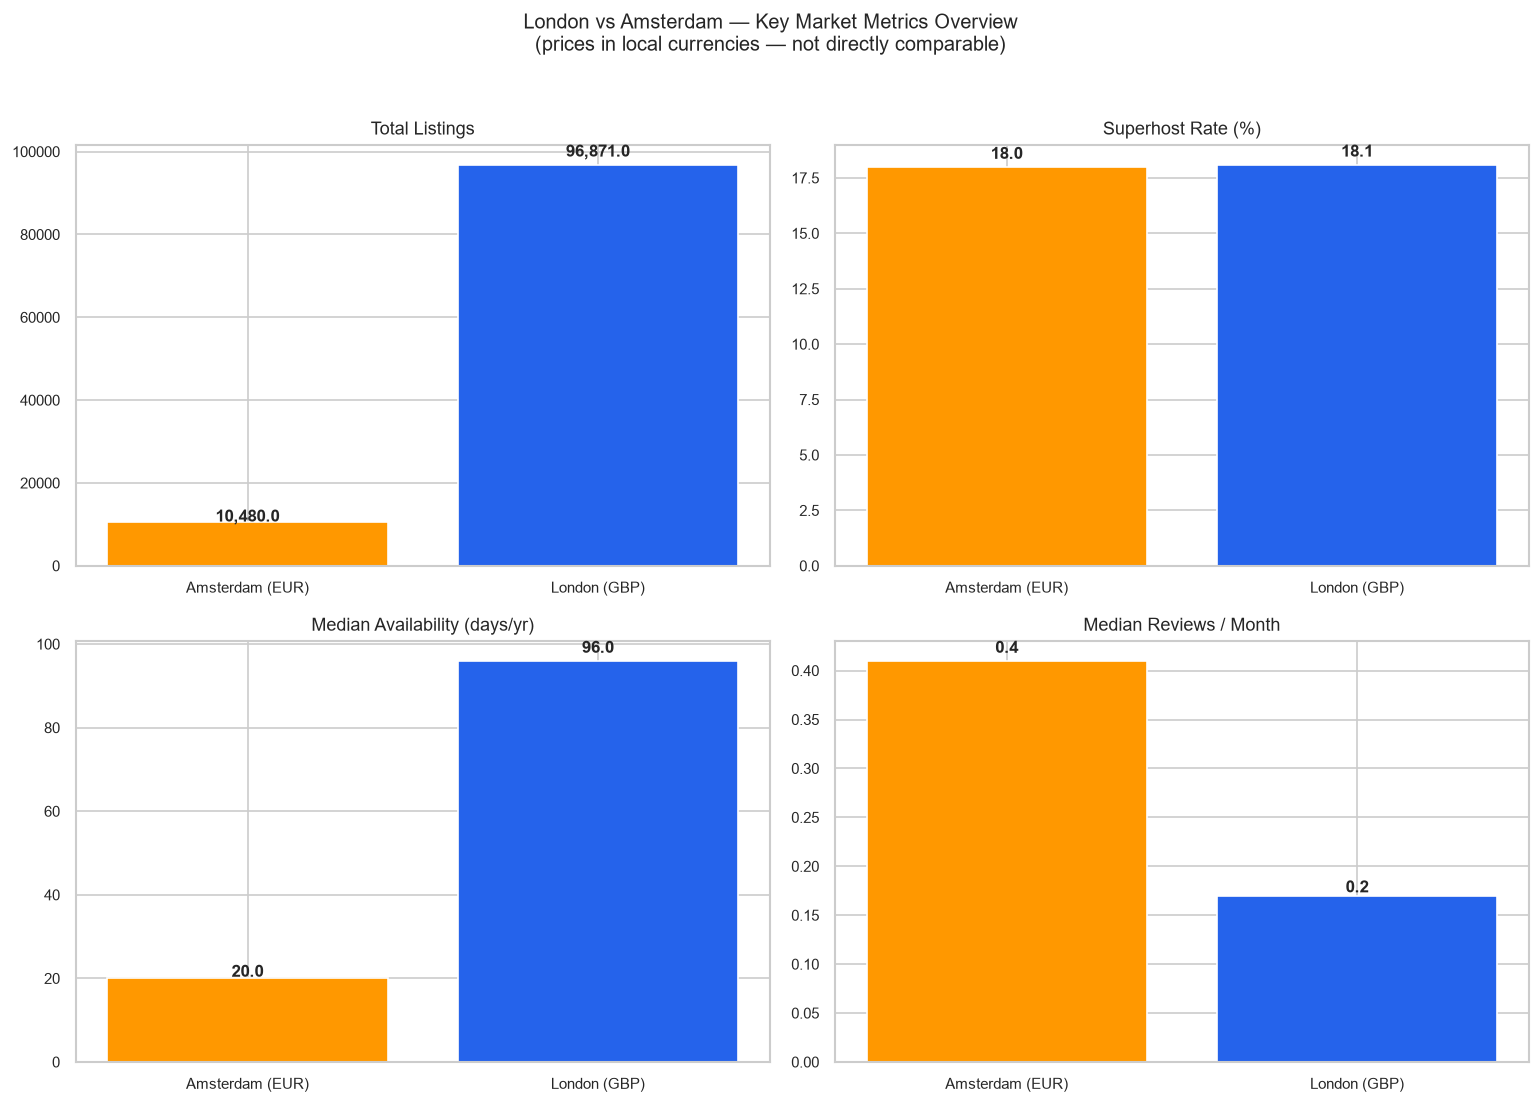

Saved → 24_cross_city_overview.png


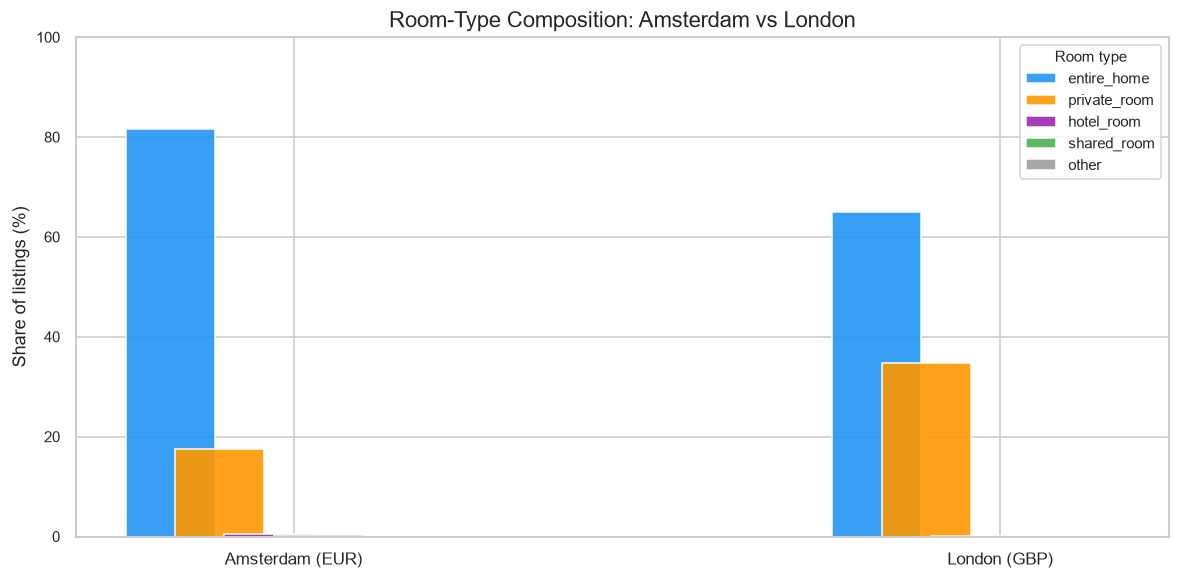

Saved → 25_room_type_comparison.png
                Amsterdam (EUR)  London (GBP)
room_type_norm                               
entire_home                81.7          64.9
private_room               17.5          34.7
hotel_room                  0.5           0.1
shared_room                 0.3           0.2
other                       0.0           0.0


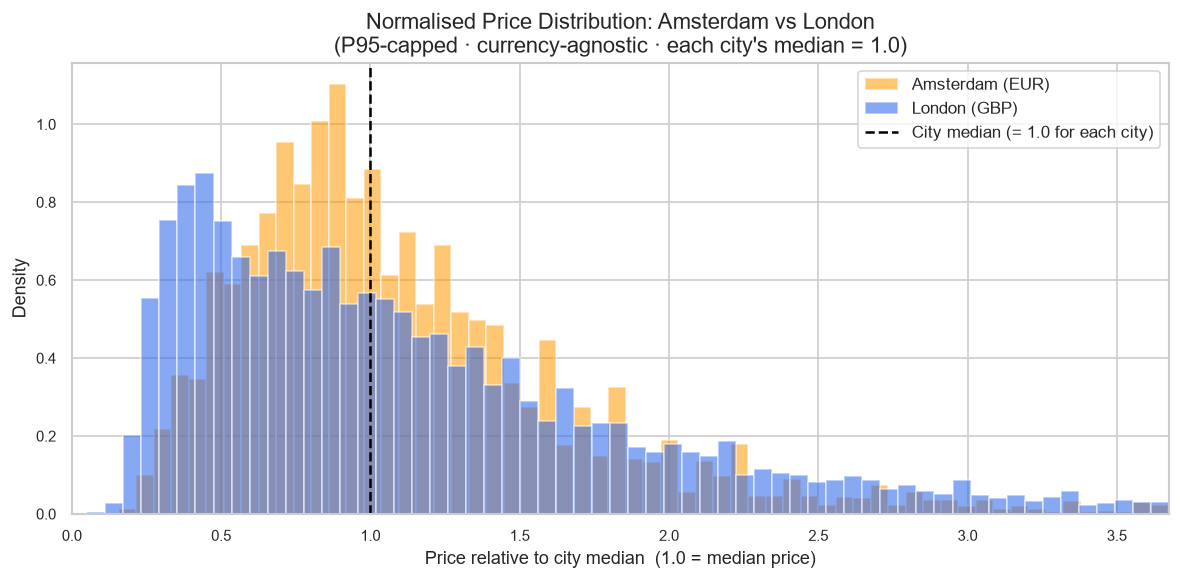

Saved → 26_price_normalized_comparison.png


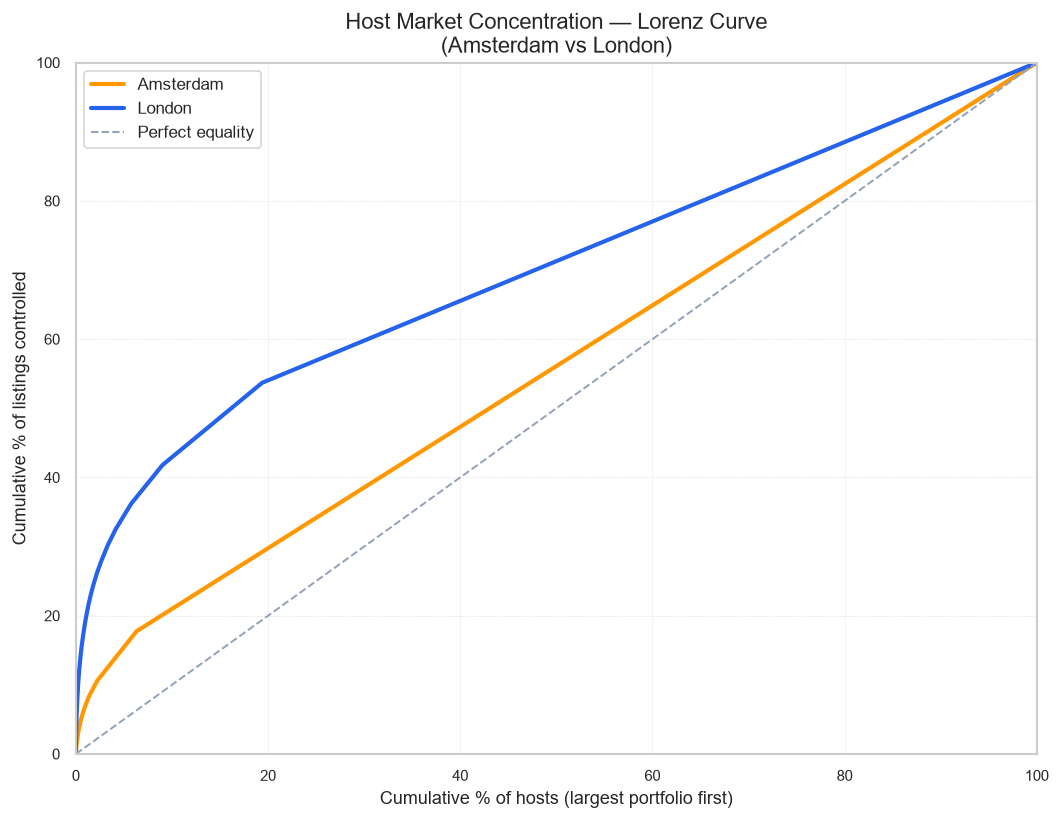


Host concentration summary:
  Amsterdam: 9,201 hosts — top 1% → 7.1% | top 10% → 21.0% of listings
  London: 55,646 hosts — top 1% → 19.3% | top 10% → 42.9% of listings

Saved → 27_host_concentration_comparison.png
Saved → city_comparison_summary.csv
Saved → room_type_city_comparison.csv


In [36]:
# ── Step 8 — London vs Amsterdam two-city comparison ─────────────────────────
# Amsterdam raw data (listings.csv.gz) is the detailed snapshot with 79 columns.
# London uses the already-loaded `listings` DataFrame from listing_master.parquet.

AMS_RAW = Path("../data/raw/amsterdam/listings.csv.gz")

# ── 14.0  Load and clean Amsterdam ───────────────────────────────────────────
ams_load_cols = [
    "id", "host_id", "price", "room_type", "neighbourhood_cleansed",
    "availability_365", "review_scores_rating", "number_of_reviews",
    "reviews_per_month", "host_is_superhost", "calculated_host_listings_count",
    "host_response_rate", "latitude", "longitude",
]
ams_raw = pd.read_csv(AMS_RAW, usecols=ams_load_cols)

# Price: "$132.00" → 132.0 (Inside Airbnb uses $ symbol even for EUR cities)
ams_raw["price_numeric"] = pd.to_numeric(
    ams_raw["price"].str.replace(r"[\$,]", "", regex=True),
    errors="coerce",
)

# Superhost: "t"/"f" → True/False
ams_raw["superhost"] = ams_raw["host_is_superhost"].map({"t": True, "f": False})

# Response rate: "100%" → 1.0
ams_raw["response_rate"] = (
    pd.to_numeric(
        ams_raw["host_response_rate"].str.rstrip("%"),
        errors="coerce",
    ) / 100
)

# Room type: map to London's internal canonical form
room_type_map = {
    "Entire home/apt": "entire_home",
    "Private room":    "private_room",
    "Shared room":     "shared_room",
    "Hotel room":      "hotel_room",
}
ams_raw["room_type_norm"] = ams_raw["room_type"].map(room_type_map).fillna("other")

# Host segment — reuse the same thresholds as London (defined in Step 2)
ams_raw["host_segment"] = ams_raw["calculated_host_listings_count"].apply(_host_segment)

# City metadata
ams_raw["city"]          = "Amsterdam"
ams_raw["currency"]      = "EUR"
ams_raw["snapshot_date"] = "2025-09-11"
ams_raw["portfolio_size"] = ams_raw["calculated_host_listings_count"]
ams_raw["rpm"]            = ams_raw["reviews_per_month"]

print(f"Amsterdam: {len(ams_raw):,} listings  |  "
      f"price-eligible: {ams_raw['price_numeric'].notna().sum():,}  |  "
      f"median price (EUR): {ams_raw['price_numeric'].median():.0f}")

# ── 14.0  Prepare London slice ────────────────────────────────────────────────
lon = listings[[
    "id", "host_id", "price_numeric", "room_type", "neighbourhood_cleansed",
    "availability_365", "review_scores_rating", "number_of_reviews",
    "reviews_per_month_calc", "host_portfolio_size", "occupancy_proxy",
]].copy()
lon["superhost"]       = listings["host_is_superhost"].map(
    {True: True, False: False, "True": True, "False": False}
)
lon["response_rate"]   = listings["host_response_rate"]
lon["host_segment"]    = listings["host_segment"]
lon["room_type_norm"]  = lon["room_type"]      # London already uses canonical form
lon["city"]            = "London"
lon["currency"]        = "GBP"
lon["snapshot_date"]   = "2025-09-14"
lon["portfolio_size"]  = lon["host_portfolio_size"]
lon["rpm"]             = lon["reviews_per_month_calc"]

print(f"London  : {len(lon):,} listings  |  "
      f"price-eligible: {lon['price_numeric'].notna().sum():,}  |  "
      f"median price (GBP): {lon['price_numeric'].median():.0f}")

# ── price_vs_city_median — currency-agnostic normalised metric ────────────────
# 1.0 = exactly at city median; 1.5 = 50% above; 0.8 = 20% below.
# Only valid within-city, not across currencies.
for df in [ams_raw, lon]:
    med = df["price_numeric"].median()
    df["price_vs_median"] = (df["price_numeric"] / med).round(4)

# ── Chart 24 · 14.1  City overview (4 key metrics) ───────────────────────────
def _city_metrics(df, label):
    return {
        "city":               label,
        "total_listings":     len(df),
        "unique_hosts":       df["host_id"].nunique(),
        "price_eligible":     int(df["price_numeric"].notna().sum()),
        "median_price":       round(df["price_numeric"].median(), 0),
        "price_null_pct":     round(df["price_numeric"].isna().mean() * 100, 1),
        "median_avail_365":   round(df["availability_365"].median(), 0),
        "median_reviews":     round(df["number_of_reviews"].median(), 1),
        "median_rpm":         round(df["rpm"].median(), 2),
        "superhost_rate_pct": round(df["superhost"].mean() * 100, 1),
        "pct_entire_home":    round((df["room_type_norm"] == "entire_home").mean() * 100, 1),
        "pct_commercial":     round((df["host_segment"] == "Commercial (21+)").mean() * 100, 1),
        "median_rating":      round(df["review_scores_rating"].median(), 2),
    }

city_summary = pd.DataFrame([
    _city_metrics(ams_raw, "Amsterdam (EUR)"),
    _city_metrics(lon,     "London (GBP)"),
]).set_index("city")

city_summary.to_csv(TABLES / "city_comparison_summary.csv")
print("\nCity summary:")
print(city_summary.T.to_string())

# 4-panel overview bar chart
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cities = city_summary.index.tolist()
colors = ["#FF9800", "#2563eb"]   # Amsterdam = orange, London = blue

overview_panels = [
    ("total_listings",     "Total Listings",          axes[0, 0], False),
    ("superhost_rate_pct", "Superhost Rate (%)",      axes[0, 1], False),
    ("median_avail_365",   "Median Availability (days/yr)", axes[1, 0], False),
    ("median_rpm",         "Median Reviews / Month",  axes[1, 1], False),
]

for col, title, ax, _ in overview_panels:
    vals = city_summary[col].values
    bars = ax.bar(cities, vals, color=colors)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis="x", labelsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.02, f"{v:,.1f}",
                ha="center", fontsize=10, fontweight="bold")

plt.suptitle("London vs Amsterdam — Key Market Metrics Overview\n"
             "(prices in local currencies — not directly comparable)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / "24_cross_city_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 24_cross_city_overview.png")

# ── Chart 25 · 14.2  Room-type composition comparison ────────────────────────
room_order_norm = ["entire_home", "private_room", "hotel_room", "shared_room", "other"]
room_colors_map = {
    "entire_home":  "#2196F3",
    "private_room": "#FF9800",
    "hotel_room":   "#9C27B0",
    "shared_room":  "#4CAF50",
    "other":        "#9E9E9E",
}

room_comp = pd.DataFrame({
    "Amsterdam (EUR)": ams_raw["room_type_norm"].value_counts(normalize=True) * 100,
    "London (GBP)":    lon["room_type_norm"].value_counts(normalize=True) * 100,
}).reindex(room_order_norm).fillna(0).round(1)
room_comp.to_csv(TABLES / "room_type_city_comparison.csv")

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cities))
w = 0.35
for i, room in enumerate(room_order_norm):
    offset  = (i - len(room_order_norm) / 2) * w / len(room_order_norm)
    vals    = [room_comp.loc[room, c] if room in room_comp.index else 0 for c in cities]
    color   = room_colors_map.get(room, "#888")
    rects   = ax.bar(x + offset, vals, w / len(room_order_norm) * 1.8,
                     label=room, color=color, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=10)
ax.set_ylabel("Share of listings (%)")
ax.set_title("Room-Type Composition: Amsterdam vs London")
ax.legend(fontsize=9, title="Room type", title_fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(FIGS / "25_room_type_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 25_room_type_comparison.png")
print(room_comp.to_string())

# ── Chart 26 · 14.3  Normalised price distribution comparison ────────────────
# price_vs_median = 1.0 at city median. Identical scale for both cities.
# Cap at P95 of the combined distribution to remove luxury outliers.
ams_pvm = ams_raw["price_vs_median"].dropna()
lon_pvm = lon["price_vs_median"].dropna()
combined_p95 = pd.concat([ams_pvm, lon_pvm]).quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ams_pvm[ams_pvm <= combined_p95], bins=60, alpha=0.55,
        color="#FF9800", label="Amsterdam (EUR)", density=True)
ax.hist(lon_pvm[lon_pvm <= combined_p95], bins=60, alpha=0.55,
        color="#2563eb", label="London (GBP)",   density=True)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1.5,
           label="City median (= 1.0 for each city)")
ax.set_xlabel("Price relative to city median  (1.0 = median price)", fontsize=11)
ax.set_ylabel("Density")
ax.set_title("Normalised Price Distribution: Amsterdam vs London\n"
             "(P95-capped · currency-agnostic · each city's median = 1.0)")
ax.legend(fontsize=10)
ax.set_xlim(0, combined_p95)
plt.tight_layout()
plt.savefig(FIGS / "26_price_normalized_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 26_price_normalized_comparison.png")

# ── Chart 27 · 14.4  Host market concentration Lorenz curves ─────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for df, label, color in [
    (ams_raw, "Amsterdam", "#FF9800"),
    (lon,     "London",    "#2563eb"),
]:
    host_port = (
        df.groupby("host_id")["id"].count()
        .sort_values(ascending=False)
    )
    total_h   = len(host_port)
    total_l   = host_port.sum()
    cum_hosts    = (np.arange(1, total_h + 1)) / total_h * 100
    cum_listings = host_port.cumsum().values / total_l * 100
    ax.plot(cum_hosts, cum_listings, label=label, color=color, linewidth=2.5)

ax.plot([0, 100], [0, 100], linestyle="--", color="#94a3b8",
        linewidth=1.2, label="Perfect equality")
ax.set_title("Host Market Concentration — Lorenz Curve\n(Amsterdam vs London)")
ax.set_xlabel("Cumulative % of hosts (largest portfolio first)")
ax.set_ylabel("Cumulative % of listings controlled")
ax.legend(fontsize=10)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(FIGS / "27_host_concentration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Print concentration stats for both cities
print("\nHost concentration summary:")
for df, label in [(ams_raw, "Amsterdam"), (lon, "London")]:
    hp     = df.groupby("host_id")["id"].count().sort_values(ascending=False)
    n_h    = len(hp)
    n_l    = hp.sum()
    top1   = max(1, int(n_h * 0.01))
    top10  = max(1, int(n_h * 0.10))
    sh_1   = round(hp.head(top1).sum() / n_l * 100, 1)
    sh_10  = round(hp.head(top10).sum() / n_l * 100, 1)
    print(f"  {label}: {n_h:,} hosts — top 1% → {sh_1}% | top 10% → {sh_10}% of listings")

print("\nSaved → 27_host_concentration_comparison.png")
print("Saved → city_comparison_summary.csv")
print("Saved → room_type_city_comparison.csv")


---
## Step 9 — Deliverable Completion and Validation

Generates the two remaining Section 15 tables (`review_summary.csv`,
`temporal_summary.csv`), appends the two-city findings to `eda_findings.md`,
and runs a final checklist that confirms every required output exists on disk.

This is the last step of the EDA phase.

In [37]:
# ── Step 9a — Generate missing Section 15 deliverable tables ─────────────────

# ── review_summary.csv ────────────────────────────────────────────────────────
# One row per review dimension (overall + 6 sub-scores) plus aggregate stats.
# This is the canonical review-quality reference table for downstream phases.

review_score_cols = [
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
]

review_stats = []
for col in review_score_cols:
    s = listings[col].dropna()
    review_stats.append({
        "dimension":    col.replace("review_scores_", "").replace("_", " ").title(),
        "n_rated":      len(s),
        "null_count":   int(listings[col].isna().sum()),
        "null_pct":     round(listings[col].isna().mean() * 100, 1),
        "mean":         round(s.mean(), 4),
        "median":       round(s.median(), 4),
        "std":          round(s.std(), 4),
        "p10":          round(s.quantile(0.10), 4),
        "p25":          round(s.quantile(0.25), 4),
        "p75":          round(s.quantile(0.75), 4),
        "p90":          round(s.quantile(0.90), 4),
        "min":          round(s.min(), 4),
        "max":          round(s.max(), 4),
    })

review_summary_df = pd.DataFrame(review_stats).set_index("dimension")

# Append aggregate review-count stats as extra rows
agg_rows = pd.DataFrame([
    {
        "dimension":  "number_of_reviews (count)",
        "n_rated":    int(listings["number_of_reviews"].notna().sum()),
        "null_count": int(listings["number_of_reviews"].isna().sum()),
        "null_pct":   round(listings["number_of_reviews"].isna().mean() * 100, 1),
        "mean":       round(listings["number_of_reviews"].mean(), 2),
        "median":     round(listings["number_of_reviews"].median(), 2),
        "std":        round(listings["number_of_reviews"].std(), 2),
        "p10":        round(listings["number_of_reviews"].quantile(0.10), 2),
        "p25":        round(listings["number_of_reviews"].quantile(0.25), 2),
        "p75":        round(listings["number_of_reviews"].quantile(0.75), 2),
        "p90":        round(listings["number_of_reviews"].quantile(0.90), 2),
        "min":        round(listings["number_of_reviews"].min(), 2),
        "max":        round(listings["number_of_reviews"].max(), 2),
    },
    {
        "dimension":  "reviews_per_month_calc (rate)",
        "n_rated":    int(listings["reviews_per_month_calc"].notna().sum()),
        "null_count": int(listings["reviews_per_month_calc"].isna().sum()),
        "null_pct":   round(listings["reviews_per_month_calc"].isna().mean() * 100, 1),
        "mean":       round(listings["reviews_per_month_calc"].mean(), 4),
        "median":     round(listings["reviews_per_month_calc"].median(), 4),
        "std":        round(listings["reviews_per_month_calc"].std(), 4),
        "p10":        round(listings["reviews_per_month_calc"].quantile(0.10), 4),
        "p25":        round(listings["reviews_per_month_calc"].quantile(0.25), 4),
        "p75":        round(listings["reviews_per_month_calc"].quantile(0.75), 4),
        "p90":        round(listings["reviews_per_month_calc"].quantile(0.90), 4),
        "min":        round(listings["reviews_per_month_calc"].min(), 4),
        "max":        round(listings["reviews_per_month_calc"].max(), 4),
    },
]).set_index("dimension")

review_summary_final = pd.concat([review_summary_df, agg_rows])
review_summary_final.to_csv(TABLES / "review_summary.csv")
print("Saved → review_summary.csv")
print(review_summary_final[["n_rated","mean","median","p25","p75"]].to_string())

# ── temporal_summary.csv ──────────────────────────────────────────────────────
# Consolidates monthly availability, weekday/weekend, and min-nights into one
# joined table so downstream phases have a single temporal reference.

monthly_avail  = pd.read_csv(TABLES / "monthly_availability.csv", parse_dates=["month"])
min_nights_mon = pd.read_csv(TABLES / "minimum_nights_monthly.csv", parse_dates=["month"])
weekpart_df    = pd.read_csv(TABLES / "weekday_weekend_availability.csv")

# Merge monthly tables on month
temporal = monthly_avail.merge(min_nights_mon, on="month", how="left")

# Add season label
def _season(ts):
    m = ts.month
    if m in [12, 1, 2]:   return "Winter"
    if m in [3, 4, 5]:    return "Spring"
    if m in [6, 7, 8]:    return "Summer"
    return "Autumn"

temporal["season"] = temporal["month"].apply(_season)

# Reorder columns for clarity
col_order = [
    "month", "season", "total_days", "available_days", "unique_listings",
    "availability_rate", "occupancy_rate",
    "median_min_nights", "mean_min_nights", "pct_longstay",
]
col_order = [c for c in col_order if c in temporal.columns]
temporal = temporal[col_order]
temporal.to_csv(TABLES / "temporal_summary.csv", index=False)
print("\nSaved → temporal_summary.csv")

# Also append weekday/weekend as a short sub-table at the bottom (as a note in output)
print("\nWeekday vs Weekend Summary:")
print(weekpart_df[["label","total_days","availability_rate","occupancy_rate"]].to_string(index=False))
print(f"\nPeak occupancy month: {temporal.loc[temporal['occupancy_rate'].idxmax(), 'month'].strftime('%b %Y')}")


Saved → review_summary.csv
                               n_rated     mean  median   p25    p75
dimension                                                           
Rating                           72749   4.6847  4.8300  4.58   5.00
Accuracy                         72734   4.7255  4.8800  4.67   5.00
Cleanliness                      72740   4.6500  4.8100  4.51   5.00
Checkin                          72706   4.7903  4.9300  4.76   5.00
Communication                    72729   4.8123  4.9600  4.80   5.00
Location                         72705   4.7298  4.8500  4.65   5.00
Value                            72705   4.6162  4.7500  4.50   4.94
number_of_reviews (count)        96871  21.6600  5.0000  1.00  20.00
reviews_per_month_calc (rate)    72749   0.6364  0.1667  0.00   0.75

Saved → temporal_summary.csv

Weekday vs Weekend Summary:
  label  total_days  availability_rate  occupancy_rate
Weekday    25270396           0.398170        0.601830
Weekend    10087578           0.394762       

In [38]:
# ── Step 9b — Append two-city findings to eda_findings.md ───────────────────
# Step 7 wrote eda_findings.md before Step 8 ran. This cell appends a new
# section with the Amsterdam vs London comparison findings.

findings_path = Path("../reports/eda_findings.md")

# Read back the city summary that was saved in Step 8
cs = pd.read_csv(TABLES / "city_comparison_summary.csv", index_col=0)
rt = pd.read_csv(TABLES / "room_type_city_comparison.csv", index_col=0)

ams_row = cs.loc["Amsterdam (EUR)"]
lon_row = cs.loc["London (GBP)"]

# Host concentration stats from the Step 8 outputs
def _concentration(df):
    hp   = df.groupby("host_id")["id"].count().sort_values(ascending=False)
    n_h  = len(hp); n_l = hp.sum()
    t1   = max(1, int(n_h * 0.01))
    t10  = max(1, int(n_h * 0.10))
    return {
        "top1_pct":  round(hp.head(t1).sum() / n_l * 100, 1),
        "top10_pct": round(hp.head(t10).sum() / n_l * 100, 1),
    }

ams_conc = _concentration(ams_raw)
lon_conc = _concentration(lon)

appendix = f"""
---

## 11. Two-City Comparison: London vs Amsterdam (Step 8)

**Note:** Only two cities are currently downloaded. The framework is designed to
scale to six cities once additional snapshots are ingested.

### City Overview

| Metric | Amsterdam (EUR) | London (GBP) |
|--------|----------------|-------------|
| Snapshot date | 2025-09-11 | 2025-09-14 |
| Total listings | {int(ams_row['total_listings']):,} | {int(lon_row['total_listings']):,} |
| Unique hosts | {int(ams_row['unique_hosts']):,} | {int(lon_row['unique_hosts']):,} |
| Median price (local currency) | {int(ams_row['median_price'])} | {int(lon_row['median_price'])} |
| Median availability (days/yr) | {int(ams_row['median_avail_365'])} | {int(lon_row['median_avail_365'])} |
| Entire home share | {ams_row['pct_entire_home']}% | {lon_row['pct_entire_home']}% |
| Commercial host share (21+) | {ams_row['pct_commercial']}% | {lon_row['pct_commercial']}% |
| Superhost rate | {ams_row['superhost_rate_pct']}% | {lon_row['superhost_rate_pct']}% |
| Median review score | {ams_row['median_rating']} | {lon_row['median_rating']} |
| Top-1% host supply share | {ams_conc['top1_pct']}% | {lon_conc['top1_pct']}% |
| Top-10% host supply share | {ams_conc['top10_pct']}% | {lon_conc['top10_pct']}% |

### Key Cross-City Findings

**C-01 · Amsterdam is heavily entire-home dominant**
Amsterdam is {rt.loc['entire_home', 'Amsterdam (EUR)']:.0f}% entire homes vs London's {rt.loc['entire_home', 'London (GBP)']:.0f}%.
This likely reflects Amsterdam's stricter short-stay registration rules, which push
casual room-sharing out and leave only committed entire-home operators on the platform.

**C-02 · Amsterdam has far less professional-operator concentration**
Commercial hosts (21+ listings) account for only {ams_row['pct_commercial']}% of Amsterdam supply vs
{lon_row['pct_commercial']}% in London. Top-1% host supply share: Amsterdam {ams_conc['top1_pct']}% vs London {lon_conc['top1_pct']}%.
London's market is structurally more concentrated — resembling a managed-property market.

**C-03 · Amsterdam listings are much less available**
Median availability_365 is only {int(ams_row['median_avail_365'])} days in Amsterdam vs {int(lon_row['median_avail_365'])} days in London.
This is consistent with Amsterdam's 30-night-per-year short-stay cap, which forces
hosts to block the majority of the calendar.

**C-04 · Amsterdam scores higher on review quality**
Median overall rating: Amsterdam {ams_row['median_rating']} vs London {lon_row['median_rating']}.
With far fewer active listings (regulation effect), Amsterdam's supply is skewed
toward experienced, high-quality operators who survived the regulatory filter.

**C-05 · Price comparison requires city-median normalisation**
Amsterdam median is EUR {int(ams_row['median_price'])} vs London GBP {int(lon_row['median_price'])}. These are not directly
comparable (different currencies, purchasing power, and regulatory environments).
The normalised distribution (Chart 26) shows Amsterdam has a heavier right tail —
more listings priced at 2× or more the city median — consistent with fewer but
more premium entire-home listings.

### Limitations

- Currency differences (EUR vs GBP) prevent direct nominal price comparison.
- Amsterdam data is raw (no pipeline cleaning); London uses the fully processed parquet.
- Only two cities available; six-city scale-out requires additional data ingestion.
- Amsterdam's 44% price null rate (vs London's 36%) may reflect different listing practices.

*Cross-city charts: `reports/figures/eda/24_cross_city_overview.png` through `27_host_concentration_comparison.png`*
"""

existing = findings_path.read_text(encoding="utf-8")
findings_path.write_text(existing + appendix, encoding="utf-8")
print(f"Updated → reports/eda_findings.md  (+{len(appendix):,} characters)")
print(f"New total size: {len(existing) + len(appendix):,} characters")


Updated → reports/eda_findings.md  (+2,796 characters)
New total size: 22,974 characters


In [39]:
# ── Step 9c — Final EDA deliverable validation ───────────────────────────────
# Verifies every required chart and table exists on disk.
# A missing file raises an AssertionError so the issue is immediately visible.

required_charts = [
    "01_price_distribution.png",
    "02_price_by_room_type.png",
    "03_price_by_property_type.png",
    "04_median_price_by_neighbourhood.png",
    "05_host_portfolio_distribution.png",
    "06_review_score_distributions.png",
    "07_availability_bands.png",
    "08_listing_density_map.png",
    "09_price_gradient_by_distance.png",
    "10_review_score_map.png",
    "11_room_type_by_neighbourhood.png",
    "12_monthly_availability_trend.png",
    "13_weekday_vs_weekend_availability.png",
    "14_monthly_review_volume.png",
    "15_host_tenure_analysis.png",
    "16_minimum_nights_monthly.png",
    "17_host_segment_comparison.png",
    "18_response_rate_analysis.png",
    "19_market_concentration.png",
    "20_review_count_vs_price.png",
    "21_review_frequency_demand.png",
    "22_high_review_low_score.png",
    "23_review_subdimensions_heatmap.png",
    "24_cross_city_overview.png",
    "25_room_type_comparison.png",
    "26_price_normalized_comparison.png",
    "27_host_concentration_comparison.png",
]

required_tables = [
    "numerical_summary.csv",
    "population_exclusions.csv",
    "price_by_room_type.csv",
    "price_by_neighbourhood.csv",
    "host_segment_summary.csv",
    "host_segment_comparison.csv",
    "host_tenure_summary.csv",
    "availability_band_summary.csv",
    "neighbourhood_density.csv",
    "neighbourhood_density.geojson",
    "price_by_distance_band.csv",
    "room_type_by_neighbourhood.csv",
    "monthly_availability.csv",
    "weekday_weekend_availability.csv",
    "monthly_review_volume.csv",
    "minimum_nights_monthly.csv",
    "response_rate_summary.csv",
    "market_concentration.csv",
    "review_subdimension_summary.csv",
    "high_review_low_score_listings.csv",
    "review_summary.csv",
    "temporal_summary.csv",
    "city_comparison_summary.csv",
    "room_type_city_comparison.csv",
]

required_reports = [
    "../reports/eda_findings.md",
]

print("=" * 60)
print("EDA DELIVERABLE VALIDATION")
print("=" * 60)

all_ok = True

print(f"\n── Charts ({len(required_charts)} expected) ─────────────────────────")
for fname in required_charts:
    p = FIGS / fname
    status = "✓" if p.exists() else "✗ MISSING"
    if not p.exists():
        all_ok = False
    print(f"  {status}  {fname}")

print(f"\n── Tables ({len(required_tables)} expected) ─────────────────────────")
for fname in required_tables:
    p = TABLES / fname
    status = "✓" if p.exists() else "✗ MISSING"
    if not p.exists():
        all_ok = False
    size_kb = round(p.stat().st_size / 1024, 1) if p.exists() else 0
    print(f"  {status}  {fname}  ({size_kb} KB)")

print(f"\n── Reports ────────────────────────────────────────────────")
for rel_path in required_reports:
    p = Path(rel_path)
    status = "✓" if p.exists() else "✗ MISSING"
    if not p.exists():
        all_ok = False
    size_kb = round(p.stat().st_size / 1024, 1) if p.exists() else 0
    print(f"  {status}  {rel_path}  ({size_kb} KB)")

print("\n" + "=" * 60)
if all_ok:
    print("ALL DELIVERABLES PRESENT — EDA phase complete.")
else:
    print("WARNING: one or more deliverables are missing (see ✗ above).")
print("=" * 60)

print(f"\nSnapshot  : London 2025-09-14  |  Amsterdam 2025-09-11")
print(f"Charts    : {len(required_charts)} PNG files in reports/figures/eda/")
print(f"Tables    : {len(required_tables)} CSV/GeoJSON files in reports/tables/")
print(f"Report    : reports/eda_findings.md")
print(f"Notebook  : notebooks/03_exploratory_data_analysis.ipynb")


EDA DELIVERABLE VALIDATION

── Charts (27 expected) ─────────────────────────
  ✓  01_price_distribution.png
  ✓  02_price_by_room_type.png
  ✓  03_price_by_property_type.png
  ✓  04_median_price_by_neighbourhood.png
  ✓  05_host_portfolio_distribution.png
  ✓  06_review_score_distributions.png
  ✓  07_availability_bands.png
  ✓  08_listing_density_map.png
  ✓  09_price_gradient_by_distance.png
  ✓  10_review_score_map.png
  ✓  11_room_type_by_neighbourhood.png
  ✓  12_monthly_availability_trend.png
  ✓  13_weekday_vs_weekend_availability.png
  ✓  14_monthly_review_volume.png
  ✓  15_host_tenure_analysis.png
  ✓  16_minimum_nights_monthly.png
  ✓  17_host_segment_comparison.png
  ✓  18_response_rate_analysis.png
  ✓  19_market_concentration.png
  ✓  20_review_count_vs_price.png
  ✓  21_review_frequency_demand.png
  ✓  22_high_review_low_score.png
  ✓  23_review_subdimensions_heatmap.png
  ✓  24_cross_city_overview.png
  ✓  25_room_type_comparison.png
  ✓  26_price_normalized_comparison

---
## EDA Phase — Complete

All nine steps of the Exploratory Data Analysis have been executed:

| Step | Coverage | Key outputs |
|------|----------|-------------|
| 1 | Load & verify data | Dataset shapes, null audit, sanity checks |
| 2 | Price & distributions | Charts 01–09, price/room/neighbourhood CSVs |
| 3 | Geographic & spatial | Charts 08–11, density map, distance gradient |
| 4 | Temporal & seasonal | Charts 12–16, monthly availability & min-nights |
| 5 | Host supply-side | Charts 17–19, segment comparison, Lorenz curve |
| 6 | Review & demand | Charts 20–23, anomaly listings, sub-dimension heatmap |
| 7 | Key findings report | `reports/eda_findings.md` (Sections 1–10) |
| 8 | Two-city comparison | Charts 24–27, Amsterdam vs London cross-city |
| 9 | Deliverable completion | `review_summary.csv`, `temporal_summary.csv`, findings update |

**Next phase:** Statistical Analysis — hypothesis testing, regression, confidence intervals.